# Рекомендации банковских продуктов

**Бизнес задача**: Имеются данные о поведении клиентов банка за 1 год и 5 месяцев — на их основе необходимо предсказать, какие новые продукты купят клиенты. Данные начинаются с 28 января 2015 года и содержат ежемесячные записи о продуктах, которыми воспользовался клиент, например, «кредитная карта», «сберегательный счет» и т. д. Необходимо предсказать, какие дополнительные продукты клиент получит в новом месяце. 

**Цель**: Подготовить модель машинного обучения, которая на имеющихся данных предскажет какими новыми банковскими продуктами воспользуется клиент в будущем месяце.

**Дополнительно**: 
1. В качестве новых банковских продуктов выбраны продукты, которые не использовались в текущем месяце.
2. В качестве тестовой выборки решено оставить последний месяц 2016 года. При этом: 
    - для модели с двухстадийным подходом использовать 2015 год для обучения модели ALS, а для ранжирующей модели первый квартал 2016 года;
    - для модели multi-label классификации использовать весь датасет кроме тестового, а первый квартал 2016 года может использоваться для валидации.

**Метрики**

Для рекомендации клиентам нескольких продуктов (в том числе multi-label), особенно если важен порядок рекомендаций - лучше всего подходит метрика MAP@k (Mean Average Precision). Так как основная масса клиентов не пользуются новыми продуктами, а их количество для оставшихся клиентов обычно не превышает 3-х продуктов для более 99% клиентов, использовано `k=3`.

- Основная метрика: **MAP@3**
- Дополнительные метрики: Precision@3, Recall@3

<div class="alert alert-info">
<font size="3"><b>Комментарий</b></font>  

Данный Jupyter блокнот является объединением блокнота с проведением [исследовательского анализа данных](EDA\EDA.ipynb) и блокнота с [экспериментами с моделями](modeling.ipynb).
</div>

## Инициализация

In [ ]:
# Импорт стандартных библиотек
import sys
import os
import gc
import warnings
# Подавляем warnings от библиотек
# pydantic об изменении схемы и 
# tqdm об отсуствии IProgress
warnings.filterwarnings("ignore")

# Импорт библиотек
import pandas as pd
import numpy as np
import yaml
import joblib
import mlflow
import json
from tqdm import tqdm
from dotenv import load_dotenv
from plotly.subplots import make_subplots
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from mlflow.pyfunc import PythonModel
from mlflow.models.signature import infer_signature
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix
from threadpoolctl import threadpool_limits
from implicit.als import AlternatingLeastSquares
from sklearn.neighbors import NearestNeighbors
from catboost import CatBoostClassifier

In [ ]:
# Объявление констант
load_dotenv()

RANDOM_STATE = 42
PERCENTILES = [.01, .05, .25, .5, .75, .95, .99]

# Папки для сохранения файлов
ASSETS_DIR = os.path.join("EDA", "ASSETS")
PLOTS_DIR = os.path.join(ASSETS_DIR, "plots")

# Данные для подключения к MLflow
MLFLOW_HOST = os.getenv("MLFLOW_HOST") 
MLFLOW_PORT = os.getenv("MLFLOW_PORT")
MLFLOW_URI = f"http://{MLFLOW_HOST}:{MLFLOW_PORT}"

EXPERIMENT_NAME = "bank_products_3PX"
REGISTRY_MODEL_NAME = "bank_products_3PX"

MLFLOW = True

# Данные для сохранения тестовой выборки в S3 
# для использования в сервисе предсказаний
STORAGE_OPTIONS = {
    "endpoint_url": os.getenv("MLFLOW_S3_ENDPOINT_URL"), 
    "key": os.getenv("AWS_ACCESS_KEY_ID"), 
    "secret": os.getenv("AWS_SECRET_ACCESS_KEY"),
    "client_kwargs":{
        "region_name": os.getenv("AWS_REGION")},
    "config_kwargs": {
        "signature_version": os.getenv("AWS_SIGV")}}
TEST_DUMP = (f"s3://{os.getenv('S3_BUCKET')}/"
             f"{os.getenv('BP_DATA_FILE')}")

# Настройки вывода pandas
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('plotting.backend', 'plotly')

# Увеличиваем частоту очистки памяти
gc.set_threshold(10, 3, 2)

## Исследовательский анализ данных

### Загрузка данных

In [ ]:
df = pd.read_csv(
    "data/train_ver2.csv", 
    low_memory=False, 
    parse_dates=["fecha_dato", "fecha_alta", "ult_fec_cli_1t"],
    na_values=["NA", " NA", "     NA"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13647309 entries, 0 to 13647308
Data columns (total 48 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   fecha_dato             datetime64[ns]
 1   ncodpers               int64         
 2   ind_empleado           object        
 3   pais_residencia        object        
 4   sexo                   object        
 5   age                    float64       
 6   fecha_alta             datetime64[ns]
 7   ind_nuevo              float64       
 8   antiguedad             float64       
 9   indrel                 float64       
 10  ult_fec_cli_1t         datetime64[ns]
 11  indrel_1mes            object        
 12  tiprel_1mes            object        
 13  indresi                object        
 14  indext                 object        
 15  conyuemp               object        
 16  canal_entrada          object        
 17  indfall                object        
 18  tipodom             

In [4]:
# Дополнительно отсортируем для удобства просмотра и обработки
df = df.sort_values(["ncodpers", "fecha_dato"]) \
    .reset_index(drop=True)
df.head(15)

,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,2015-01-28,15889,F,ES,V,56.00,1995-01-16,0.00,245.00,1.00,...,0,0,0,0,1,1,0,0.00,0.00,0
1,2015-02-28,15889,F,ES,V,56.00,1995-01-16,0.00,245.00,1.00,...,0,0,0,0,0,1,0,0.00,0.00,0
2,2015-03-28,15889,F,ES,V,56.00,1995-01-16,0.00,245.00,1.00,...,0,0,0,0,0,1,0,0.00,0.00,0
3,2015-04-28,15889,F,ES,V,56.00,1995-01-16,0.00,245.00,1.00,...,0,0,0,0,0,1,0,0.00,0.00,0
4,2015-05-28,15889,F,ES,V,56.00,1995-01-16,0.00,245.00,1.00,...,0,0,0,0,1,1,0,0.00,0.00,0
5,2015-06-28,15889,F,ES,V,56.00,1995-01-16,0.00,245.00,1.00,...,0,0,0,0,1,1,0,0.00,0.00,0
6,2015-07-28,15889,F,ES,V,56.00,1995-01-16,0.00,245.00,1.00,...,0,0,0,0,1,1,0,0.00,0.00,0
7,2015-08-28,15889,F,ES,V,56.00,1995-01-16,0.00,246.00,1.00,...,0,0,0,0,0,1,0,0.00,0.00,0
8,2015-09-28,15889,F,ES,V,56.00,1995-01-16,0.00,247.00,1.00,...,0,0,0,0,0,1,0,0.00,0.00,0
9,2015-10-28,15889,F,ES,V,56.00,1995-01-16,0.00,248.00,1.00,...,0,0,0,0,0,1,0,0.00,0.00,0


Так как датасет довольно большой, он будет разделен на следующие категории:
1. Общая информация о клиенте;
2. Адресные данные и гражданство;
3. Взаимоотношения с банком;
4. Целевые признаки - стобцы с 25 по 48.

### Общая информация о клиенте

1. Датасет содержит следующую общую информация о клиенте:
- `fecha_dato` – Дата записи данных.
- `ncodpers` – Уникальный идентификатор клиента.
- `sexo` – Пол (H – мужчина, V – женщина).
- `age` – Возраст клиента.
- `ind_empleado` - Статус занятости:
    - A — трудоустроен
    - B — безработный, раньше работал
    - F — иждивенец
    - N — безработный
    - P — пассивный (статус не определён)
- `conyuemp` - супруг(а) клиента работника банка;
- `renta` - Доход домохозяйства.
- `segmento` - Сегментация: 1 — VIP, 2 — Обыкновенные 3 — выпускники колледжей.

Взглянем на эти признаки.

#### Обзор признаков

In [5]:
# Список общих признаков о клиенте
feats = ["fecha_dato", "ncodpers", "sexo", "age",  
         "ind_empleado", "conyuemp", "renta", "segmento"]

df[feats].head(20)

,fecha_dato,ncodpers,sexo,age,ind_empleado,conyuemp,renta,segmento
0,2015-01-28,15889,V,56.00,F,N,326124.90,01 - TOP
1,2015-02-28,15889,V,56.00,F,N,326124.90,01 - TOP
2,2015-03-28,15889,V,56.00,F,N,326124.90,01 - TOP
3,2015-04-28,15889,V,56.00,F,N,326124.90,01 - TOP
4,2015-05-28,15889,V,56.00,F,N,326124.90,01 - TOP
5,2015-06-28,15889,V,56.00,F,N,326124.90,01 - TOP
6,2015-07-28,15889,V,56.00,F,N,326124.90,01 - TOP
7,2015-08-28,15889,V,56.00,F,N,326124.90,01 - TOP
8,2015-09-28,15889,V,56.00,F,N,326124.90,01 - TOP
9,2015-10-28,15889,V,56.00,F,N,326124.90,01 - TOP


Можно отметить, что у клиента 15889 возраст за почти 1.5 года не поменялся. Оценим количество уникальных значений по каждому признаку.

In [6]:
# Количество уникальных значений
print("Уникальных значений признаков:")
df[feats].nunique()

Уникальных значений признаков:


fecha_dato          17
ncodpers        956645
sexo                 2
age                120
ind_empleado         5
conyuemp             2
renta           520994
segmento             3
dtype: int64

В датасете представлены записи с 17 уникальными значениями для даты записи данных. Клиентов порядка 956.6 тысяч. Признаки пола `sexo` и супруга(-и) клиента работник банка являются бинарными, а признаки занятости и сегмента - категориальные. 

Взглянем на уникальные значения значения даты записи данных, а также на значения возраста и категориальные признаки.

In [7]:
for col in [
    "fecha_dato", "sexo", "age", "indfall", 
     "ind_empleado","segmento"
]:
    print(f"{col}:")
    display(df[col].unique())

fecha_dato:


<DatetimeArray>
['2015-01-28 00:00:00', '2015-02-28 00:00:00', '2015-03-28 00:00:00',
 '2015-04-28 00:00:00', '2015-05-28 00:00:00', '2015-06-28 00:00:00',
 '2015-07-28 00:00:00', '2015-08-28 00:00:00', '2015-09-28 00:00:00',
 '2015-10-28 00:00:00', '2015-11-28 00:00:00', '2015-12-28 00:00:00',
 '2016-01-28 00:00:00', '2016-02-28 00:00:00', '2016-03-28 00:00:00',
 '2016-04-28 00:00:00', '2016-05-28 00:00:00']
Length: 17, dtype: datetime64[ns]

sexo:


array(['V', 'H', nan], dtype=object)

age:


...

array(['N', 'S', nan], dtype=object)

ind_empleado:


array(['F', 'A', 'N', 'B', nan, 'S'], dtype=object)

segmento:


array(['01 - TOP', '02 - PARTICULARES', nan, '03 - UNIVERSITARIO'],
      dtype=object)

Очевидно, что данные выгружались помесячно - 28 числа каждого месяца, имеются данные за 2015 год, а также за 5 месяцев 2016 года. Также имеются пропуски по остальным признакам и наличие категории занятости `S`, которой нет в описании датасета. 

Для начала преобразуем возраст в числовой формат и оценим изменчивость принаков у клиентов взглянув на их распределение по каждому клиенту.

In [8]:
df.groupby("ncodpers")[feats] \
    .nunique().describe(percentiles=PERCENTILES).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
fecha_dato,956645.00,14.27,4.03,1.00,1.00,6.00,11.00,17.00,17.00,17.00,17.00,17.00
ncodpers,956645.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
sexo,956645.00,0.99,0.09,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00
age,956645.00,1.77,0.44,0.00,1.00,1.00,2.00,2.00,2.00,2.00,2.00,4.00
ind_empleado,956645.00,0.99,0.09,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
conyuemp,956645.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
renta,956645.00,0.74,0.44,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00
segmento,956645.00,1.01,0.21,0.00,0.00,1.00,1.00,1.00,1.00,1.00,2.00,3.00


В целом распределение не вызывает больших вопросов, имеются клиенты с пропусками по всем полям, кроме даты выгрузки и кода клиента. Более 50% клиентов имеют записи за 17 месяцев, 95% - не менее полугода, хотя есть не менее 1% клиентов, у которых только одна выгрузка. Пропусков по значениям в основном не так много, кроме полей заработной платы `renta` - не менее 25% и признака супруга(-и) клиента работника банка - пропущены значения практически для всего датасета.

Однако стоит отметить, что для основной массы клиентов количество разных значений возраста в основном до 2-х, что с учетом данных за 1.5 года является нормальным, однако встречаются клиенты, имеющие 4 различных возраста, что может быть признаком некорректного ввода или выгрузки данных, либо наличие разных клиентов под одним идентификатором. Также вызывает вопрос наличие 2-х полов у некоторых клиентов, возможно была смена пола и внесли изменения, либо допущена ошибка.

#### Дата выгрузки

Проверим наличие дубликатов выгрузок в разерезе клиентов.

In [9]:
print("Количество дубликатов записей клиентов:",
      df.duplicated(subset=["fecha_dato", "ncodpers"]).sum())
print("Количество пропусков:\n",
      df[feats[:2]].isna().sum(),sep="")

Количество дубликатов записей клиентов: 0
Количество пропусков:
fecha_dato    0
ncodpers      0
dtype: int64


Распределение клиентов по месяцам.

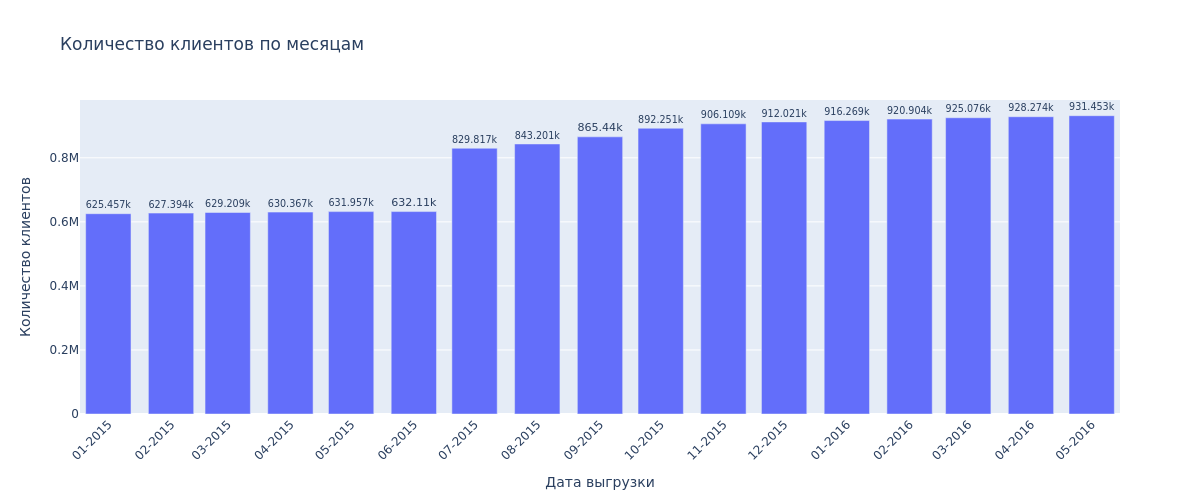

In [10]:
fig = df.groupby("fecha_dato")["ncodpers"].count().plot(
    kind="bar", text_auto=True,
    title="Количество клиентов по месяцам",
    labels={"fecha_dato": "Дата выгрузки", 
            "value": "Количество клиентов"})
fig.update_layout(
    height=500, width=1200, showlegend=False)
fig.update_xaxes(
    tickmode="array",
    tickvals=df["fecha_dato"].unique(),
    ticktext=[
        date.strftime("%m-%Y") 
        for date in df["fecha_dato"].unique()],
    tickformat="%m-%Y",
    tickangle=-45)
fig.update_traces(textposition="outside")
fig.write_html(PLOTS_DIR+"fecha_dato(1).html")
fig.show(renderer="png")

До июля 2015 года количество записей по клиентам показывает слабый рост, но в июле количество клиентов увеличивается почти на 200 тысяч и продолжает постепенно расти. 

Оценим наличие пропусков в датах у клиентов.

In [11]:
print(
    "Количество пропусков в датах:",
    (df.groupby("ncodpers")["fecha_dato"] \
        .diff().dt.days > 31).sum())
print("Клиенты с пропусками:")
clients = df.loc[
    df.groupby("ncodpers")["fecha_dato"] \
        .diff().dt.days > 31,
    "ncodpers"].unique()
display(df.loc[df["ncodpers"].isin(clients), feats])
print(f"Количество клиентов: {len(clients)}")

Количество пропусков в датах: 8243
Клиенты с пропусками:


,fecha_dato,ncodpers,sexo,age,ind_empleado,conyuemp,renta,segmento
2363,2015-01-28,16073,V,49.00,N,NaN,53478.18,02 - PARTICULARES
2364,2015-07-28,16073,V,49.00,N,NaN,53478.18,02 - PARTICULARES
2365,2015-08-28,16073,V,49.00,N,NaN,53478.18,02 - PARTICULARES
2366,2015-09-28,16073,V,49.00,N,NaN,53478.18,02 - PARTICULARES
2367,2015-10-28,16073,V,49.00,N,NaN,53478.18,02 - PARTICULARES
...,...,...,...,...,...,...,...,...
13618169,2016-05-28,1535499,V,26.00,N,NaN,NaN,NaN
13633379,2016-03-28,1542008,V,53.00,N,NaN,NaN,NaN
13633380,2016-05-28,1542008,V,53.00,N,NaN,NaN,NaN
13634173,2016-03-28,1542376,V,34.00,N,NaN,NaN,NaN


Количество клиентов: 8018


Можно отметить наличие пропусков как в начале 2015 года, так и в 2016 году. Взглянем на распределение количества клиентов с пропусками в различные даты.

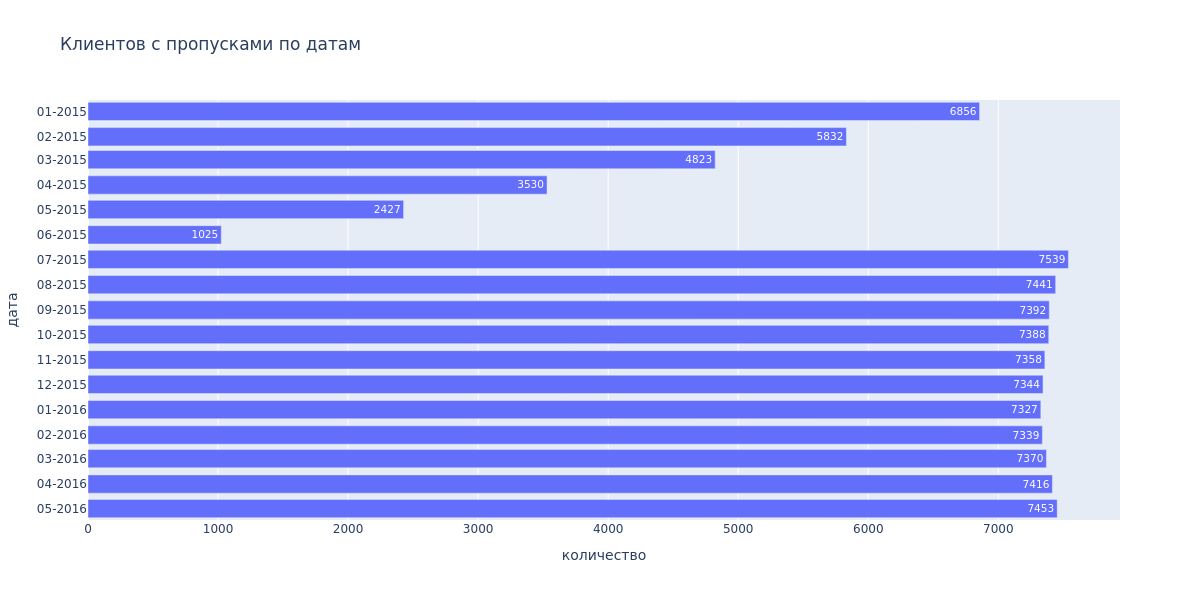

In [12]:
fig = df[df["ncodpers"].isin(clients)] \
    .groupby("fecha_dato")["ncodpers"].count() \
    .plot(
        kind="barh", text_auto=True,
        title="Клиентов с пропусками по датам",
        labels={"fecha_dato": "дата", "value": "количество"})
fig.update_yaxes(
    tickmode="array",
    tickvals=df["fecha_dato"].unique(),
    ticktext=[
        date.strftime("%m-%Y") 
        for date in df["fecha_dato"].unique()],
    tickformat="%m-%Y")
fig.update_layout(
    height=600, width=1200, showlegend=False,
    yaxis=dict(autorange="reversed"))
fig.write_html(PLOTS_DIR+"fecha_dato(2).html")
fig.show(renderer="png")

Судя по всему были проблемы с выгрузкой данных в первом полугодии 2015 года, также нужно будет оценить такие пропуски в разрезе взаимоотношений клиента с банком.

#### Возраст

Оценим распределение значений возраста у клиентов.

In [13]:
def hist_with_box(data: pd.DataFrame):
    """
    Возвращает гистограмму и boxplot
    """
    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True, 
        vertical_spacing=0.1, row_heights=[.9,.1])
    fig.add_trace(
        data.plot(kind="hist")["data", 0],
        row=1, col=1)
    fig.add_trace(
        data.plot(kind="box", orientation="h")["data", 0],
        row=2, col=1)
    return fig

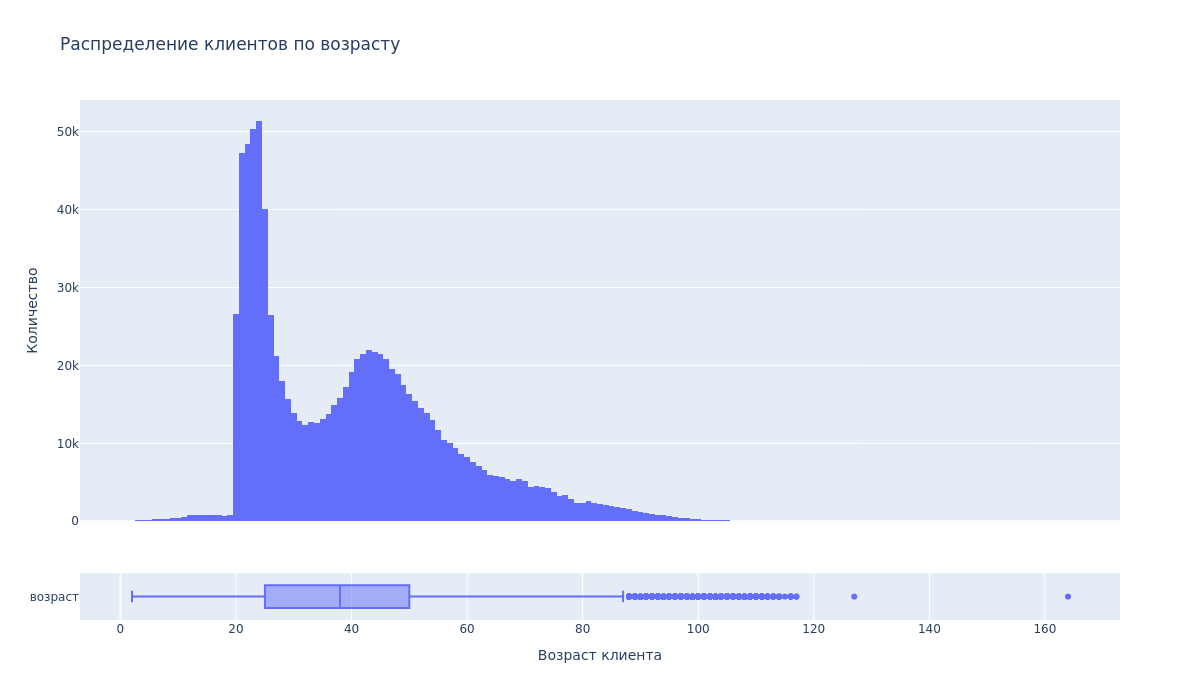

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,949614.00,40.15,17.17,2.00,20.00,21.00,25.00,38.00,50.00,74.00,89.00,164.00


In [14]:
fig = hist_with_box(
    df.groupby("ncodpers")["age"].last().rename("возраст"))
fig.update_layout(
    title="Распределение клиентов по возрасту",
    yaxis_title="Количество",
    xaxis2_title="Возраст клиента",
    height=700, width=1200, showlegend=False)
fig.write_html(PLOTS_DIR+"age(1).html")
fig.show(renderer="png")
df.groupby("ncodpers")["age"].last() \
    .describe(percentiles=PERCENTILES).to_frame().T

По возрасту распределение мультимодальное, можно выделить 3 сегмента - молодые до 30 лет, среднего возраста от 30 до 65 лет, и клиенты старше 65 лет. Основная масса клиентов находится в пределах от 20 до 89 лет, однако встречаются клиенты от 2-х и до 164-х лет.

Оценим распределение клиентов по количеству уникальных значений возраста в датасете.

In [15]:
print("Количество клиентов:")
display(df.groupby("ncodpers")["age"].nunique().value_counts())

for i in [3, 4]:
    print()
    print(f"Клиенты c {i} значениями возраста:")
    display(df[df["ncodpers"].isin(
        df.groupby("ncodpers")["age"].nunique().loc[lambda x: x == i].index
    )][feats].tail(20))

Количество клиентов:


age
2    746738
1    202677
0      7031
3       197
4         2
Name: count, dtype: int64


Клиенты c 3 значениями возраста:


,fecha_dato,ncodpers,sexo,age,ind_empleado,conyuemp,renta,segmento
13618472,2016-02-28,1535586,V,28.00,N,NaN,NaN,NaN
13618473,2016-03-28,1535586,V,30.00,N,NaN,NaN,02 - PARTICULARES
13618474,2016-04-28,1535586,V,29.00,N,NaN,NaN,02 - PARTICULARES
13618475,2016-05-28,1535586,V,29.00,N,NaN,NaN,02 - PARTICULARES
13618874,2016-02-28,1535701,V,41.00,N,NaN,NaN,NaN
13618875,2016-03-28,1535701,V,43.00,N,NaN,NaN,02 - PARTICULARES
13618876,2016-04-28,1535701,V,42.00,N,NaN,NaN,02 - PARTICULARES
13618877,2016-05-28,1535701,V,42.00,N,NaN,NaN,02 - PARTICULARES
13634393,2016-03-28,1542472,H,27.00,N,NaN,NaN,NaN
13634394,2016-04-28,1542472,H,29.00,N,NaN,NaN,03 - UNIVERSITARIO



Клиенты c 4 значениями возраста:


,fecha_dato,ncodpers,sexo,age,ind_empleado,conyuemp,renta,segmento
13561459,2015-12-28,1519143,V,21.00,N,NaN,NaN,NaN
13561460,2016-01-28,1519143,V,20.00,N,NaN,NaN,02 - PARTICULARES
13561461,2016-02-28,1519143,V,36.00,N,NaN,NaN,02 - PARTICULARES
13561462,2016-03-28,1519143,V,37.00,N,NaN,NaN,02 - PARTICULARES
13561463,2016-04-28,1519143,V,37.00,N,NaN,NaN,02 - PARTICULARES
13561464,2016-05-28,1519143,V,37.00,N,NaN,NaN,02 - PARTICULARES
13563724,2015-12-28,1519642,H,21.00,N,NaN,NaN,NaN
13563725,2016-01-28,1519642,H,20.00,N,NaN,NaN,02 - PARTICULARES
13563726,2016-02-28,1519642,H,44.00,N,NaN,NaN,02 - PARTICULARES
13563727,2016-03-28,1519642,H,45.00,N,NaN,NaN,02 - PARTICULARES


По возрасту клиентов можно отметить следующее:
1. Имеется более 7 тысяч клиентов возвраст которых не указан в датасете. 
2. По клиентам с 3-мя значениями возраста можно отметить, что в определенный месяц значение возраста увеличивается на 2, а в следующем снижается на 1. 
3. По клиентам с 4-мя значениями первые значения - 21 и 20, а другие выше.  

Возможно имеется проблема с расчетом возраста клиентов - в месяц, когда меняется значение возраста он расчитывается на 1 больше, чем должен быть. Также возможно, что для некоторых клиентов возраст был некорректно введен изначально и исправлен впоследствии. 

Рассмотрим распределение разброса между максимальным и минимальным возрастом клиентов.

In [16]:
# Получение данных о расхождении в возрасте
age_diff = df.groupby("ncodpers")["age"].agg(lambda x: x.max() - x.min()) \
    .sort_values(ascending=False)
display(age_diff.to_frame().describe(percentiles=PERCENTILES).T)
age_diff

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,949614.00,0.79,0.53,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,74.00


ncodpers
476125    74.00
539069    67.00
1490808   63.00
1308540   61.00
1250719   60.00
           ... 
1398214     NaN
1398316     NaN
1399205     NaN
1399245     NaN
1401509     NaN
Name: age, Length: 956645, dtype: float64

У основной массы клиентов разница в возрасте не превышает 1-го года. Однако есть клиенты с довольно большой разницей, взглянем на них.

In [17]:
df[df["ncodpers"].isin(age_diff.index[:2])][feats].tail(20)

,fecha_dato,ncodpers,sexo,age,ind_empleado,conyuemp,renta,segmento
3615638,2015-07-28,476125,V,113.00,N,NaN,45920.31,02 - PARTICULARES
3615639,2015-08-28,476125,V,113.00,N,NaN,45920.31,02 - PARTICULARES
3615640,2015-09-28,476125,V,113.00,N,NaN,45920.31,02 - PARTICULARES
3615641,2015-10-28,476125,V,113.00,N,NaN,45920.31,02 - PARTICULARES
3615642,2015-11-28,476125,V,113.00,N,NaN,45920.31,02 - PARTICULARES
3615643,2015-12-28,476125,V,39.00,N,NaN,45920.31,02 - PARTICULARES
3615644,2016-01-28,476125,V,39.00,N,NaN,45920.31,02 - PARTICULARES
3615645,2016-02-28,476125,V,39.00,N,NaN,45920.31,02 - PARTICULARES
3615646,2016-03-28,476125,V,39.00,N,NaN,45920.31,02 - PARTICULARES
3615647,2016-04-28,476125,V,39.00,N,NaN,45920.31,02 - PARTICULARES


По таким клиентам также можно предположить, что изначально возраст был введен некорректно, но в последующем данные были исправлены. Для испрвления некорректных значений возраста можно подготовить функцию со следующим алгоритмом:
1. обработка клиентов по дате выгрузки в обратном порядке;
2. заполнение пропусков ближайшим значением, на случай пропусков в последние месяцы;
3. исправление возраста, если значение меньше предыдущего на 1 - переходит к следующему, в противном случае исправляет на предыдущее значение.

In [18]:
def fix_values_increasing(
        data: pd.DataFrame,
        col: str = "age", n: int = 1, 
        group_by: str = "ncodpers",
        sort_by: str | list = ["ncodpers", "fecha_dato"],
        ascending: bool | tuple = (True, False)
) -> pd.DataFrame:
    """
    Исправляет значения колонки:
    1. обрабатывает столбец `col` с группировкой по `group_by` и 
    сортировкой по `sort_by`;
    2. заполняет пропуски следующим значением (метод bfill);
    3. по каждой группе сравнивает значение столбца `col` с предыдущим, 
    если значение меньше предыдущего на `n` - оставляет текущее, 
    в противном случае исправляет на предыдущее значение;
    """
    # Сортировка и работа с копией датасета
    data = data.sort_values(by=sort_by,ascending=ascending).copy()
    # Заполнение пропусков
    if data[col].isna().any():
        data[col] = data.groupby(group_by)[col] \
            .bfill().ffill()
    
    # Функция для обработки значений, пробовал лямбда-функцию 
    # с accumulate, но обрабатывает в 2 раза дольше
    def fix_group(x):
        out = x.to_numpy()
        for i in range(1, len(x)):
            out[i] = out[i] if out[i] == out[i - 1] - n else out[i - 1]
        return out

    # Обработка значений функцией
    data[col] = data.groupby(group_by)[col].transform(fix_group)
    
    # Возврат датафрейма с сортировкой по индексу
    return data.sort_index()

Проверим работу функции на ранее просмотренных клиентах.

In [19]:
cols = ["fecha_dato", "ncodpers", "age"]

print("Клиенты с 3 значениями возраста:")
clients = df[df["ncodpers"].isin([1535701, 1542472, 1542480, 1542557, 1542578])]
display(clients[cols].merge(
        fix_values_increasing(clients)[cols], 
        on=["fecha_dato", "ncodpers"], 
        suffixes=("","_new")))

print("Клиенты с 4 значениями возраста:")
clients = df[df["ncodpers"].isin([1519143, 1519642])]
display(clients[cols].merge(
        fix_values_increasing(clients)[cols], 
        on=["fecha_dato", "ncodpers"], 
        suffixes=("","_new")))

print("Клиенты с большим расхождением возраста:")
clients = df[df["ncodpers"].isin([476125, 539069])]
display(clients[cols].merge(
        fix_values_increasing(clients)[cols], 
        on=["fecha_dato", "ncodpers"], 
        suffixes=("","_new"))
    .tail(20))

Клиенты с 3 значениями возраста:


,fecha_dato,ncodpers,age,age_new
0,2016-02-28,1535701,41.00,41.00
1,2016-03-28,1535701,43.00,42.00
2,2016-04-28,1535701,42.00,42.00
3,2016-05-28,1535701,42.00,42.00
4,2016-03-28,1542472,27.00,27.00
5,2016-04-28,1542472,29.00,28.00
6,2016-05-28,1542472,28.00,28.00
7,2016-03-28,1542480,46.00,46.00
8,2016-04-28,1542480,48.00,47.00
9,2016-05-28,1542480,47.00,47.00


Клиенты с 4 значениями возраста:


,fecha_dato,ncodpers,age,age_new
0,2015-12-28,1519143,21.00,36.00
1,2016-01-28,1519143,20.00,36.00
2,2016-02-28,1519143,36.00,36.00
3,2016-03-28,1519143,37.00,37.00
4,2016-04-28,1519143,37.00,37.00
5,2016-05-28,1519143,37.00,37.00
6,2015-12-28,1519642,21.00,44.00
7,2016-01-28,1519642,20.00,44.00
8,2016-02-28,1519642,44.00,44.00
9,2016-03-28,1519642,45.00,45.00


Клиенты с большим расхождением возраста:


,fecha_dato,ncodpers,age,age_new
6,2015-07-28,476125,113.00,39.00
7,2015-08-28,476125,113.00,39.00
8,2015-09-28,476125,113.00,39.00
9,2015-10-28,476125,113.00,39.00
10,2015-11-28,476125,113.00,39.00
11,2015-12-28,476125,39.00,39.00
12,2016-01-28,476125,39.00,39.00
13,2016-02-28,476125,39.00,39.00
14,2016-03-28,476125,39.00,39.00
15,2016-04-28,476125,39.00,39.00


Новые значения выглядят адекватно, оценим значения возраста после исправления.

In [20]:
# Исправление значений возраста
age_fix = fix_values_increasing(
    df[df["ncodpers"].map(
        df.groupby("ncodpers")["age"].nunique()
    ) > 1])[["ncodpers", "age"]]

display(age_fix.groupby("ncodpers")["age"].nunique() \
    .describe(percentiles=PERCENTILES).to_frame().T)
display(age_fix.groupby("ncodpers")["age"].max() \
    .describe(percentiles=PERCENTILES).to_frame().T)
display(np.sort(df["age"].unique()))
del age_fix, age_diff

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,746937.00,1.98,0.14,1.00,1.00,2.00,2.00,2.00,2.00,2.00,2.00,3.00


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,746937.00,40.52,17.32,2.00,20.00,21.00,25.00,39.00,51.00,74.00,89.00,164.00


array([  2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,  12.,
        13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,  23.,
        24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,  34.,
        35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,  45.,
        46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,  56.,
        57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,  67.,
        68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,  78.,
        79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,  89.,
        90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99., 100.,
       101., 102., 103., 104., 105., 106., 107., 108., 109., 110., 111.,
       112., 113., 114., 115., 116., 117., 126., 127., 163., 164.,  nan])

По количеству значений возраста в датасете остались клиенты, имеющие максимально 3 значения, вероятно это клиенты, родившиеся в первых месяцах года. По значениям возраста остались значения моложе 18 и старше 100 лет, и тех и других менее 1% от всех клиентов. Возможно это также ошибки ввода данных, если для возраста моложе 18 лет можно сделать предположение, что банк обслуживает детские счета, то возраст более 110-120 лет явно является ошибкой ввода. 

Пока оставим как есть, но нужно будет оценить какими банковскими продуктами пользуются такие клиенты, после чего определить способ обработки значений и заполнения пропусков.

#### Пол

Проверим клиентов, имеющих более одного пола в записях.

In [21]:
clients = df.groupby("ncodpers")["sexo"] \
    .nunique().loc[lambda x: x > 1].index
print("Клиентов с двумя полами:", len(clients))
df.loc[df["ncodpers"].isin(clients), feats].tail(20)

Клиентов с двумя полами: 46


,fecha_dato,ncodpers,sexo,age,ind_empleado,conyuemp,renta,segmento
13155831,2016-02-28,1459058,V,23.00,N,NaN,NaN,03 - UNIVERSITARIO
13155832,2016-03-28,1459058,V,23.00,N,NaN,NaN,03 - UNIVERSITARIO
13155833,2016-04-28,1459058,V,23.00,N,NaN,NaN,03 - UNIVERSITARIO
13155834,2016-05-28,1459058,V,23.00,N,NaN,NaN,03 - UNIVERSITARIO
13188905,2015-09-28,1463211,V,29.00,N,NaN,NaN,NaN
13188906,2015-10-28,1463211,H,29.00,N,NaN,NaN,03 - UNIVERSITARIO
13188907,2015-11-28,1463211,H,29.00,N,NaN,NaN,03 - UNIVERSITARIO
13188908,2015-12-28,1463211,H,29.00,N,NaN,NaN,03 - UNIVERSITARIO
13188909,2016-01-28,1463211,H,29.00,N,NaN,NaN,03 - UNIVERSITARIO
13188910,2016-02-28,1463211,H,29.00,N,NaN,NaN,03 - UNIVERSITARIO


Вероятно это были ошибки в данных, которые впоследствии были исправлены. Даже если клиент производил смену пола, в любом случае можно таких клиентов считать клиентом другого пола изначально, так как к таким решениям происходят не спонтанно, а в течение длительного срока. Исправим такие ошибки на последние значения в датасете.

In [22]:
# Заменим значения последним из списка
df["sexo"] = df.groupby("ncodpers")["sexo"].transform("last")

print("Проверка количества уникальных значений у клиента:")
df.groupby("ncodpers")["sexo"].nunique(dropna=False).value_counts()

Проверка количества уникальных значений у клиента:


sexo
1    956645
Name: count, dtype: int64

Теперь у всех клиентов только одно значение пола, оценим распределение клиентов по полу.

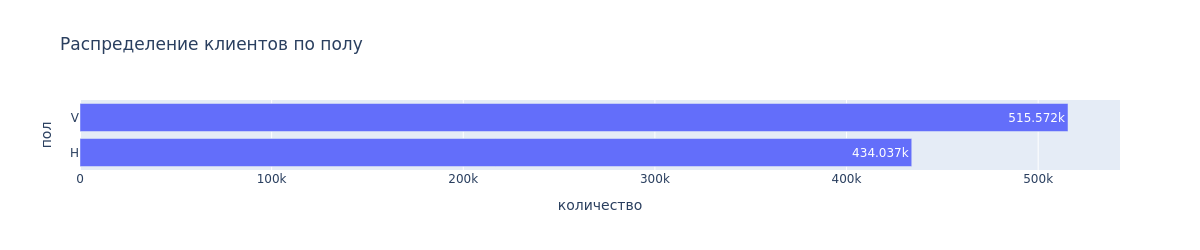

In [23]:
fig = df.groupby("ncodpers")["sexo"].last() \
    .value_counts().plot(
        kind="barh", text_auto=True,
        title="Распределение клиентов по полу",
        labels={"sexo": "пол", "value": "количество"})
fig.update_layout(
    height=250, width=1200,
    yaxis=dict(autorange="reversed"),
    showlegend=False)
fig.write_html(PLOTS_DIR+"sexo(1).html")
fig.show(renderer="png")

Распределение клиентов по полу достаточно близкое, с небольшим преобладанием клиентов женского пола в датасете.

#### Занятость клиента и супруга(-и)

Оценим распределение клиентов по типу занятости.

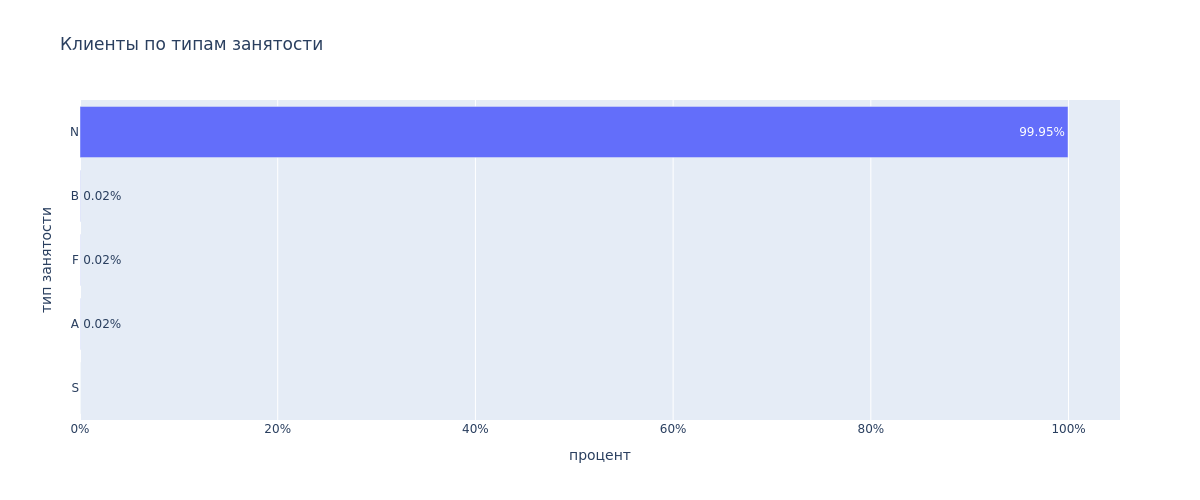

In [24]:
fig = df.groupby("ncodpers")["ind_empleado"].last() \
    .value_counts(normalize=True).plot(
        kind="barh", text_auto=True,
        title="Клиенты по типам занятости",
        labels={"ind_empleado": "тип занятости",
                "value": "процент"})
fig.update_traces(texttemplate="%{x:.2%}")
fig.update_layout(
    height=500, width=1200, 
    showlegend=False,
    yaxis=dict(autorange="reversed"),
    xaxis_tickformat=".0%")
fig.write_html(PLOTS_DIR+"ind_empleado(1).html")
fig.show(renderer="png")

Похоже, что в описании датасета имеются некорректные сведения, так как 99.95% клиентов банка не могут быть безработными. Скорее всего это признак того, что клиент является работником банка, которых абсолютное меньшинство среди всех клиентов.

Оценим возраст клиентов с типом занятости `F` - иждевенец. Возможно это поможет определить возможное наличие в датасете клиентов моложе 18 лет.

In [25]:
df.query("ind_empleado == 'F'").groupby("ncodpers")["age"].last() \
    .describe(percentiles=PERCENTILES).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,152.00,49.16,5.72,38.00,40.00,42.00,45.00,48.00,52.00,59.45,64.47,71.00


Минимальный возраст таких клиентов начинается с 37 и большая часть превышает 40 лет, клиентов моложе 18 лет нет. 

В описании указана дополнительная категория `P` - пассивный (статус не определен), но такой категории не встречается, однако встречается значение `S`. Проверим также клиентов с типом занятости `S`.

In [26]:
print(
    "Количество клиентов:",
    df.query("ind_empleado == 'S'")["ncodpers"].nunique())

df.query("ind_empleado == 'S'")[feats]

Количество клиентов: 1


,fecha_dato,ncodpers,sexo,age,ind_empleado,conyuemp,renta,segmento
5311445,2015-01-28,720152,H,38.00,S,NaN,87798.24,02 - PARTICULARES
5311446,2015-02-28,720152,H,38.00,S,NaN,87798.24,02 - PARTICULARES
5311447,2015-03-28,720152,H,38.00,S,NaN,87798.24,02 - PARTICULARES
5311448,2015-04-28,720152,H,38.00,S,NaN,87798.24,02 - PARTICULARES
5311449,2015-05-28,720152,H,38.00,S,NaN,87798.24,02 - PARTICULARES
5311450,2015-06-28,720152,H,38.00,S,NaN,87798.24,02 - PARTICULARES
5311451,2015-07-28,720152,H,38.00,S,NaN,87798.24,02 - PARTICULARES
5311452,2015-08-28,720152,H,38.00,S,NaN,87798.24,02 - PARTICULARES
5311453,2015-09-28,720152,H,38.00,S,NaN,87798.24,02 - PARTICULARES
5311454,2015-10-28,720152,H,38.00,S,NaN,87798.24,02 - PARTICULARES


Всего один клиент с типом занятости `S`, скорее всего это ошибка в данных. Все неизвестные значения лучше удалить или заменить наиболее часто встречающимся значением, возможно литера `S` является признаком работы в банке, но также имеется вероятность, что это поле было заполнено некорректно вместо другого поля. Вопросом заполнения пропусков займемся после обзора всего датасета.

Оценим количество значений признака, что супруг(-а) клиента является работником банка. По данному признаку было очень много пропусков.

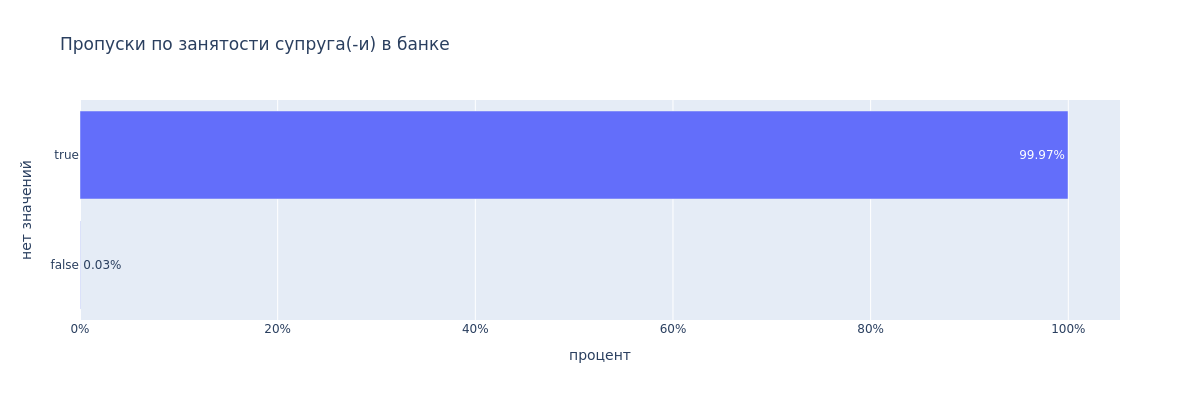

In [27]:
fig = df.groupby("ncodpers")["conyuemp"].agg(
    lambda x: x.isna().all()
).value_counts(normalize=True).plot(
    kind="barh", text_auto=True,
    title="Пропуски по занятости супруга(-и) в банке",
    labels={"conyuemp": "нет значений",
            "value": "процент"})
fig.update_traces(texttemplate="%{x:.2%}")
fig.update_layout(
    height=400, width=1200, 
    showlegend=False,
    yaxis=dict(autorange="reversed"),
    xaxis_tickformat=".0%")
fig.write_html(PLOTS_DIR+"conyuemp(1).html")
fig.show(renderer="png")

Практически для всех клиентов это поле не заполнено. Оценим как распределяются заполненные значения.

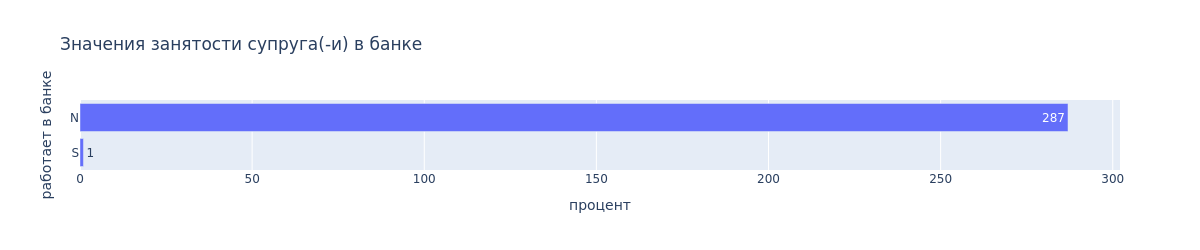

In [28]:
fig = df.groupby("ncodpers")["conyuemp"].last() \
    .value_counts().plot(
        kind="barh", text_auto=True,
        title="Значения занятости супруга(-и) в банке",
        labels={"conyuemp": "работает в банке",
                "value": "процент"})
fig.update_layout(
    height=250, width=1200, 
    yaxis=dict(autorange="reversed"),
    showlegend=False)
fig.write_html(PLOTS_DIR+"conyuemp(2).html")
fig.show(renderer="png")

Всего у одного клиента супруг(-а) работает в банке, по остальным клиентам либо нет информации, либо не работает в банке. Скорее всего этот признак не несет никакой ценности для модели машинного обучения, так как значений слишком мало.

#### Доход клиента и сегментация

Оценим распределение доходов клиента.

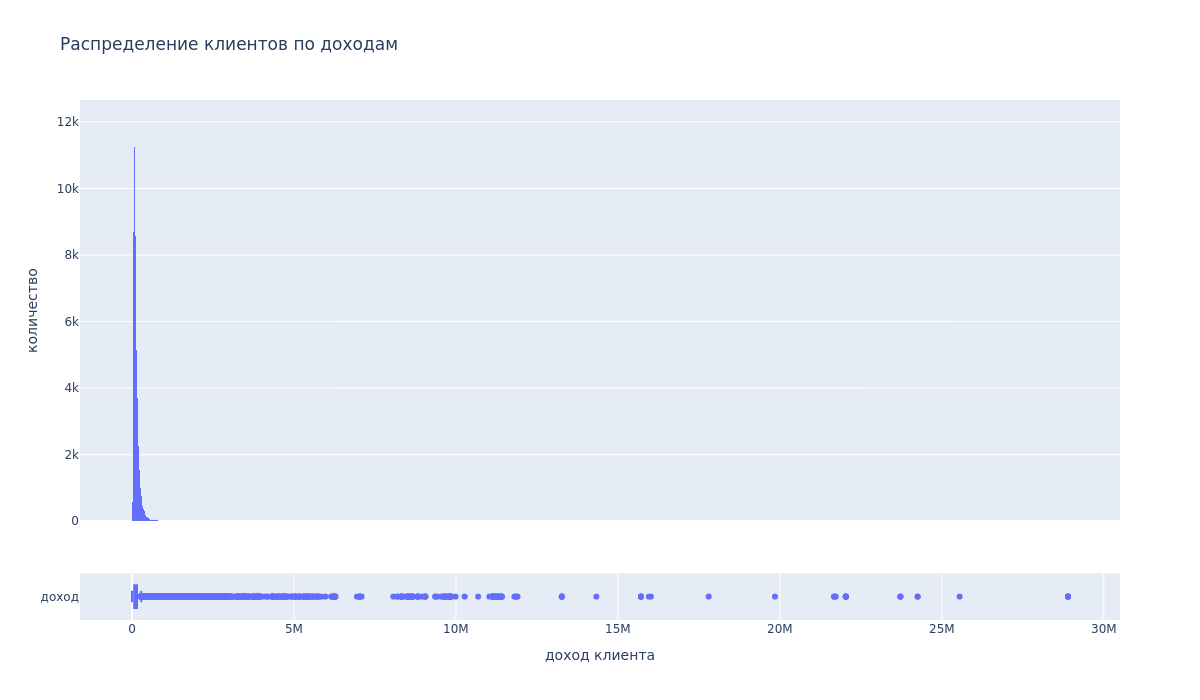

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
renta,709411.00,134096.42,232281.18,1202.73,26353.44,40029.51,68489.94,101489.34,155527.07,309957.87,555605.55,28894395.51


In [29]:
fig = hist_with_box(
    df.groupby("ncodpers")["renta"].last().rename("доход"))
fig.update_layout(
    title="Распределение клиентов по доходам",
    yaxis_title="количество",
    xaxis2_title="доход клиента",
    height=700, width=1200, showlegend=False)
fig.write_html(PLOTS_DIR+"renta(1).html")
fig.show(renderer="png")
df.groupby("ncodpers")["renta"].last() \
    .describe(percentiles=PERCENTILES).to_frame().T

Распределение клиентов по доходам имеет довольно большие выбросы по значениям. Минимальное значение в датасете составляет порядка 1200, при этом доход основной массы клиентов располагается в пределах от 40 до 310 тысяч, однако максимальные значения приближаются к 29 миллионам.

Взглянем на распределение доходов до 1 миллиона.

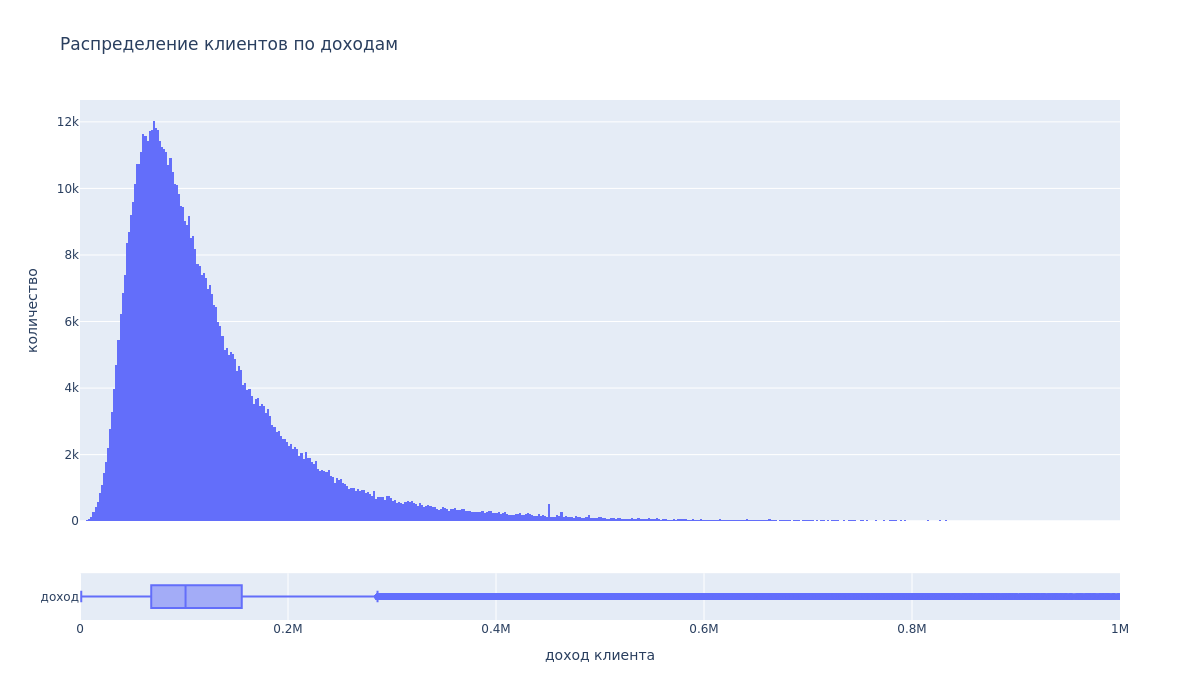

In [30]:
fig.update_layout(
    xaxis=dict(range=[0, 1_000_000]),
    xaxis2=dict(range=[0, 1_000_000]))
fig.show(renderer="png")

За пределы 1.5 IQR выходит довольно большое количество клиентов, так как доходы обычно имеют довольно большой разброс, особено в большую сторону. А в части нижней границы - лучше взглянуть на график до 40 тысяч, чтобы оценим наличие аномалий.

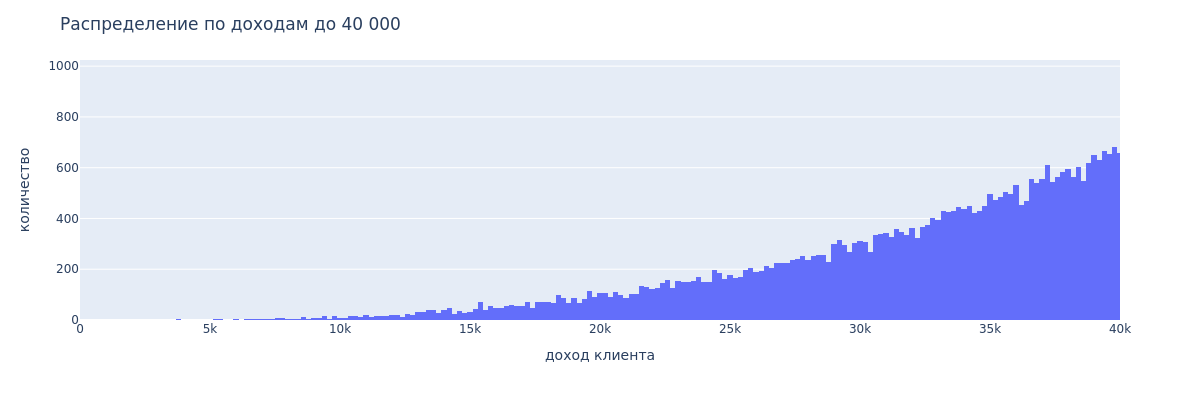

In [31]:
fig = df.groupby("ncodpers")["renta"].last() \
    .loc[lambda x: x < 50_000].plot(kind="hist")
fig.update_layout(
    title="Распределение по доходам до 40 000",
    yaxis_title="количество", 
    xaxis_title="доход клиента",
    xaxis=dict(range=[0, 40_000]),
    height=400, width=1200, showlegend=False)
fig.show(renderer="png")

По нижней границе распределение данных не выглядит аномальным, клиентов с доходом менее 10 тысяч мало, но резкие отрывы отсутствуют. Нужно будет оценить распределение сведений о доходах по различным категориям, таким как сегмент и тип клиента, а также страна и регион проживания.

По доходам клиента было много пропущенных значений, оценим какой процент клиентов не имеет сведений о доходах.

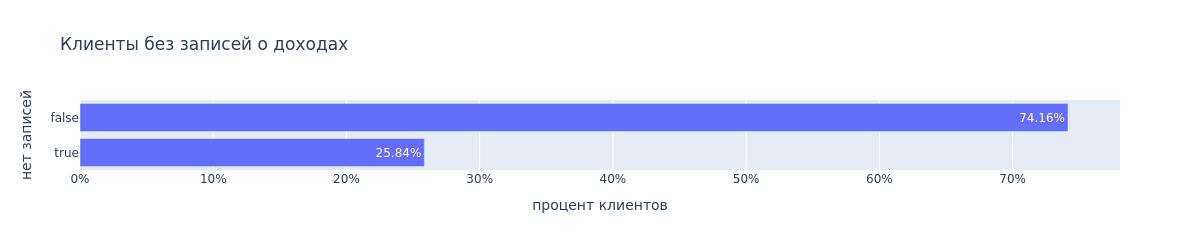

In [32]:
fig = df.groupby("ncodpers")["renta"].agg(lambda x: x.isna().all()) \
    .value_counts(normalize=True).plot(
        kind="barh", text_auto=True, 
        title="Клиенты без записей о доходах",
        labels={
            "value": "процент клиентов", 
            "renta": "нет записей"})
fig.update_traces(texttemplate="%{x:.2%}")
fig.update_layout(
    height=250, width=1200, 
    showlegend=False,
    yaxis=dict(autorange="reversed"),
    xaxis_tickformat=".0%")
fig.write_html(PLOTS_DIR+"renta(2).html")
fig.show(renderer="png")

Полностью отсутствуют сведения о доходах у более 25% от всех клиентов. Вероятнее всего информация о доходах клиента собирается не во всех случаях. Данный факт необходимо будет оценить в разрезе информации по взаимоотношению с банком и по целевым признакам.

Взглянем на распределение пропусков у клиентов, у которых имеются сведения о доходах.

In [33]:
renta_percent = df.groupby("ncodpers")["renta"].agg(lambda x: x.isna().mean())

print("Распределение для всех клиентов со значениями:")
display(renta_percent.loc[lambda x: x != 1]
        .describe(percentiles=PERCENTILES).to_frame().T)

print("Распределение для клиентов с пропусками:")
display(renta_percent.loc[lambda x: (x != 1) & (x != 0)] 
        .describe(percentiles=PERCENTILES).to_frame().T)

Распределение для всех клиентов со значениями:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
renta,709411.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.71


Распределение для клиентов с пропусками:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
renta,53.00,0.27,0.12,0.09,0.09,0.09,0.18,0.29,0.36,0.45,0.60,0.71


Среди клиентов со значениями доходов основная масса не имеет пропусков. Всего для 53 клиентов имеются пропуски, причем для большей части количество пропусков не превышает 45%, но имеются клиенты у которых пропущено до 71% от всех записей. Взглянем на записи с пропусками.

In [34]:
display(df[df["ncodpers"].isin(
    renta_percent.loc[lambda x: (x < 1) & (x > 0.45)].index
)][feats])

del renta_percent

,fecha_dato,ncodpers,sexo,age,ind_empleado,conyuemp,renta,segmento
2318055,2015-01-28,314773,V,NaN,NaN,NaN,NaN,NaN
2318056,2015-02-28,314773,V,NaN,NaN,NaN,NaN,NaN
2318057,2015-03-28,314773,V,NaN,NaN,NaN,NaN,NaN
2318058,2015-04-28,314773,V,NaN,NaN,NaN,NaN,NaN
2318059,2015-05-28,314773,V,NaN,NaN,NaN,NaN,NaN
2318060,2015-09-28,314773,V,43.00,N,NaN,93224.55,NaN
2318061,2015-10-28,314773,V,43.00,N,NaN,93224.55,02 - PARTICULARES
2318062,2015-11-28,314773,V,43.00,N,NaN,93224.55,01 - TOP
2318063,2015-12-28,314773,V,43.00,N,NaN,93224.55,01 - TOP
2318064,2016-01-28,314773,V,43.00,N,NaN,93224.55,01 - TOP


Значения не были заполнены в первые месяцы работы с клиентами, вероятнее всего эти данные еще не были доступны для работников банка, либо заполнялись по мере использования различных продуктов банка, либо имеются проблемы при выгрузке или с данными по таким клиентам, так как встречаются пропуски в выгрузках. Можно отметить, что информация о сегменте появляется в следующий месяц после появления сведений о доходах у клиентов с пропусками. Оценим количество уникальных значений по доходам клиентов.

In [35]:
df.groupby("ncodpers")["renta"].nunique().loc[lambda x: x > 0] \
    .describe(percentiles=PERCENTILES).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
renta,709411.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


Для всех таких клиентов встречается только одно значение уровня дохода, возможно данные заполняются однократно и не часто обновляются, поэтому можно заполнить пропуски имеющимися значениями.

Оценим сегментацию клиентов.

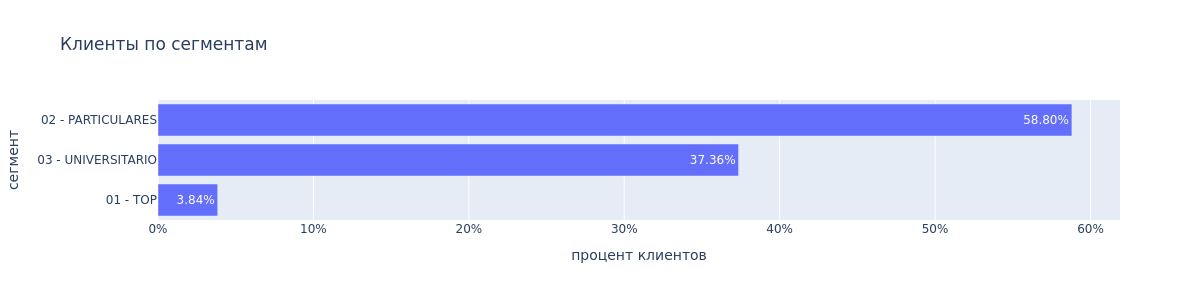

In [36]:
fig = df.groupby("ncodpers")["segmento"].last() \
    .value_counts(normalize=True).plot(
        kind="barh", text_auto=True, 
        title="Клиенты по сегментам",
        labels={
            "value": "процент клиентов", 
            "segmento": "сегмент"})
fig.update_traces(texttemplate="%{x:.2%}")
fig.update_layout(
    height=300, width=1200, 
    showlegend=False,
    yaxis=dict(autorange="reversed"),
    xaxis_tickformat=".0%")
fig.write_html(PLOTS_DIR+"segmento(1).html")
fig.show(renderer="png")

По сегментам основная масса являются обычными клиентами - 58.8%, хотя доля выпускников колледжей довольно высока - 37.36%, VIP клиентов немного, всего 3.84%. Оценим количество клиентов, которые не имеют никаких записей о сегментах.

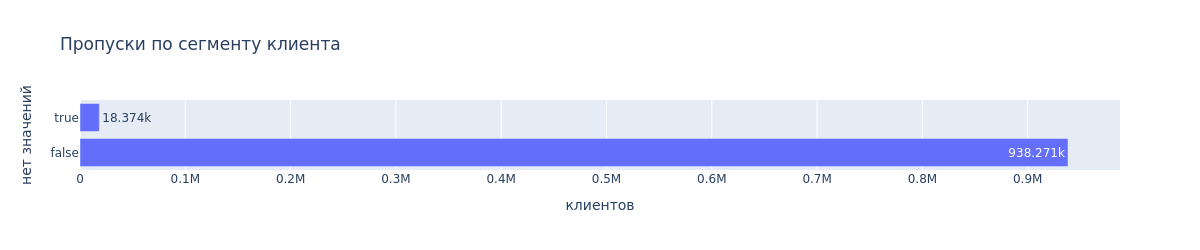

In [37]:
fig = df.groupby("ncodpers")["segmento"].agg(
    lambda x: x.isna().all()
).value_counts().plot(
    kind="barh", text_auto=True,
    title="Пропуски по сегменту клиента",
    labels={"segmento": "нет значений",
            "value": "клиентов"})
fig.update_layout(
    height=250, width=1200, 
    showlegend=False)
fig.write_html(PLOTS_DIR+"segmento(2).html")
fig.show(renderer="png")

У большинства клиентов сведения о сегментах заполнены, пропуски у порядка 18 тысяч клиентов, что больше чем пропусков по возрасту. Оценим медианные доходы для каждого сегмента.

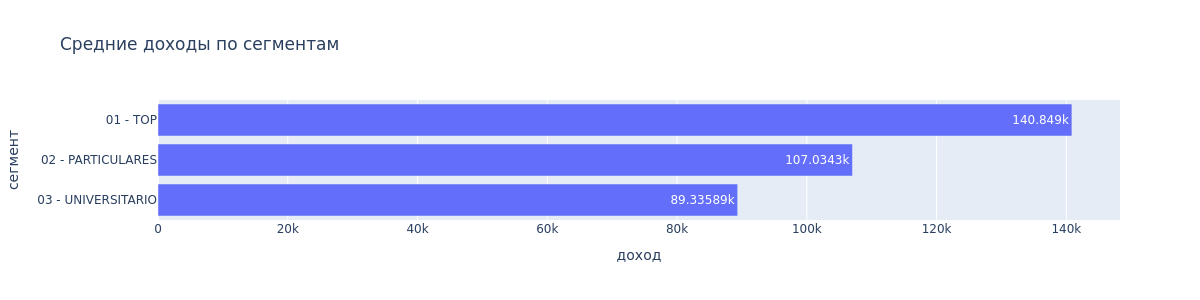

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
segmento,,,,,,,,,,,,
01 - TOP,29239.00,174571.40,241767.56,3796.86,36518.37,53857.73,94379.77,140848.98,208370.19,388898.03,647475.96,19849331.97
02 - PARTICULARES,429320.00,140845.22,256239.97,1471.23,28365.71,42284.28,72086.25,107034.29,163432.47,320632.61,573146.35,28894395.51
03 - UNIVERSITARIO,248883.00,117435.44,181432.52,1202.73,23512.07,36357.05,61627.04,89335.89,133876.20,271914.44,508042.87,28894395.51


In [38]:
renta_by_segmento = df.groupby("ncodpers")[["segmento", "renta"]].last()
fig = renta_by_segmento.groupby("segmento").median().plot(
        kind="barh", text_auto=True, 
        title="Средние доходы по сегментам",
        labels={"value": "доход", 
                "segmento": "сегмент"})
fig.update_layout(
    height=300, width=1200, 
    yaxis=dict(autorange="reversed"),
    showlegend=False)
fig.write_html(PLOTS_DIR+"segmento(3)_renta.html")
fig.show(renderer="png")
display(renta_by_segmento.groupby("segmento") \
    .describe(percentiles=PERCENTILES) \
    .pipe(lambda x: x.set_axis(x.columns.droplevel(0), axis=1)))
del renta_by_segmento

Заметно различие в медианных доходах для клиентов различных сегментов. Однако при оценки распределения значений по сегментам можно обнаружить, что минимальные значения довольно близки, а максимальные значения относятся к сегментам 02 и 03, причем эти значения абсолютно одинаковые.

#### Промежуточные выводы

Проведена оценка признаков, которые можно сгруппировать как 
общая информация о клиенте. 
По результатам анализа признаков можно выделить следующее:

1. Отсутствуют дубликаты выгрузки по клиентам, все даты уникальны, 
однако имеются пропуски в датах для некоторых клиентов;
2. По возрасту имеются проблемы в данных:
    - имеются записи, в которых возраст не меняется более года;
    - имеются клиенты моложе 18 лет, а также старше 100 лет - 
    возможны ошибки в данных;
    - встречаются сильные расхождения у одного клиента по возрасту, 
    вероятно вводились некорректные данные изначально, которые 
    впоследствии были исправлены;
    - у некоторых клиентов встречается увеличение возраста на 2 года, 
    потом снижение на 1.
3. По полу встречаются изменения признака, возможно также были введены 
неверные данные, которые также были исправлены.
4. По занятости практически все клиенты безработные, вероятнее всего 
это признак работы в банке, а не занятость клиентов вообще. 
Также супруг(-а) только для одного клиента является работником банка, 
данные признаки малоинформативны.
5. По доходам домохозяйств вероятнее всего имеются выбросы в большую 
сторону, также имеются довольно низкие значения доходов. 
В разрезе клиентов по сегментам имеются различия медианных доходов, 
присутствуют как очень низкие значения, так и самые высокие, 
причем наибольшие значения не относятся к VIP. 
Необходимо оценить каковы различия в доходах в разрезе страны и 
региона проживания.

По всем данным имеются пропуски, часто для первых выгрузок по клиенту. 
Вероятнее всего такие данные были получены не сразу и вводились по мере 
их получения, либо по мере использования отдельных банковских продуктов. 
Также имеются исправления данных, в частности пол клиента - данные 
исправлены на самые последние значения по дате.

**Рекомендации по исправлению**:
- Для исправления возраста подготовлена функция `fix_values_increasing`, 
которая исправляет резкие изменения возраста в датасете (так как в датасете 
отсутствуют сведения о дне рождения клиента, точный рассчет возраста невозможен);
- Дополнительно стоит оценить возраст и доход клиентов по признакам взаимоотношения 
с банком и возможно по целевым признакам;
- Возможно стоит удалить признаки занятости, так как они малоинформативны для модели;
- Значения пола лучше заполнить последним значением по дате выгрузки.

### Адресные данные и гражданство

В датасете представлены следующие признаки, которые можно сгруппировать как адресные данные:
- `pais_residencia` – Страна резидентства (например, ES - Испания).
- `indresi` - Страна проживания совпадает со страной банка (S – да, N – нет).
- `indext` - Страна рождения клиента отличается от страны банка (S – да, N – нет).
- `tipodom` - 	Тип адреса (1 — основной адрес).
- `cod_prov` - Код провинции (адреса клиента).
- `nomprov` - Имя провинции (например, MADRID, BARCELONA).

#### Обзор признаков

In [39]:
# Список общих признаков о клиенте
feats = [
    "fecha_dato", "ncodpers", "pais_residencia", 
    "indresi", "indext", "tipodom", "cod_prov", "nomprov"]

df[feats].head(20)

,fecha_dato,ncodpers,pais_residencia,indresi,indext,tipodom,cod_prov,nomprov
0,2015-01-28,15889,ES,S,N,1.00,28.00,MADRID
1,2015-02-28,15889,ES,S,N,1.00,28.00,MADRID
2,2015-03-28,15889,ES,S,N,1.00,28.00,MADRID
3,2015-04-28,15889,ES,S,N,1.00,28.00,MADRID
4,2015-05-28,15889,ES,S,N,1.00,28.00,MADRID
5,2015-06-28,15889,ES,S,N,1.00,28.00,MADRID
6,2015-07-28,15889,ES,S,N,1.00,28.00,MADRID
7,2015-08-28,15889,ES,S,N,1.00,28.00,MADRID
8,2015-09-28,15889,ES,S,N,1.00,28.00,MADRID
9,2015-10-28,15889,ES,S,N,1.00,28.00,MADRID


Изменчивость у данных признаков должна быть довольно низкая, оценим количество уникальных значений.

In [40]:
# Количество уникальных значений
print("Уникальных значений признаков:")
df[feats[2:]].nunique()

Уникальных значений признаков:


pais_residencia    118
indresi              2
indext               2
tipodom              1
cod_prov            52
nomprov             52
dtype: int64

Признаки проживания в стране банка `indresi`, иностранного гражданства `indext` вероятнее всего бинарные. Страна резидентства, код и наименование региона категориальные, последние два должны обозначать одно и то же. Признак типа адреса имеет всего одно значение. 

Взглянем на уникальные значения признаков.

In [41]:
for col in feats[2:]:
    print(f"{col}:")
    display(df[col].unique())

pais_residencia:


array(['ES', nan, 'PT', 'NL', 'AD', 'IN', 'VE', 'US', 'FR', 'GB', 'IT',
       'DE', 'MX', 'CL', 'CO', 'CH', 'CR', 'PE', 'JP', 'AT', 'AR', 'AE',
       'BE', 'MA', 'CI', 'QA', 'SE', 'BR', 'FI', 'RS', 'KE', 'RU', 'AU',
       'CU', 'EC', 'KR', 'DO', 'LU', 'GH', 'CZ', 'PA', 'IE', 'BO', 'CM',
       'CA', 'GR', 'ZA', 'RO', 'KH', 'IL', 'NG', 'CN', 'DK', 'NZ', 'MM',
       'SG', 'UY', 'NI', 'EG', 'GI', 'PH', 'KW', 'VN', 'TH', 'NO', 'GQ',
       'BY', 'AO', 'UA', 'TR', 'PL', 'OM', 'GA', 'GE', 'BG', 'HR', 'PR',
       'HK', 'HN', 'BA', 'MD', 'HU', 'SK', 'TN', 'TG', 'SA', 'MR', 'DZ',
       'LB', 'MT', 'SV', 'PK', 'PY', 'LY', 'MK', 'EE', 'SN', 'MZ', 'GT',
       'GN', 'TW', 'IS', 'LT', 'CD', 'KZ', 'BZ', 'CF', 'GM', 'ET', 'SL',
       'GW', 'LV', 'CG', 'ML', 'BM', 'ZW', 'AL', 'DJ', 'JM'], dtype=object)

indresi:


array(['S', nan, 'N'], dtype=object)

indext:


...

array([ 1., nan])

cod_prov:


array([28., 48., 35.,  9., 11.,  3., 49.,  8., 20., 19., nan, 41., 18.,
       15., 46.,  6., 39., 29.,  4., 36.,  1., 17.,  5., 30., 37., 38.,
       40., 23., 45., 10., 31., 33., 21., 25., 27., 50.,  7., 34., 43.,
       47., 13., 12., 32., 26., 14.,  2., 16., 22., 24., 52., 42., 44.,
       51.])

nomprov:


array(['MADRID', 'BIZKAIA', 'PALMAS, LAS', 'BURGOS', 'CADIZ', 'ALICANTE',
       'ZAMORA', 'BARCELONA', 'GIPUZKOA', 'GUADALAJARA', nan, 'SEVILLA',
       'GRANADA', 'CORUÑA, A', 'VALENCIA', 'BADAJOZ', 'CANTABRIA',
       'MALAGA', 'ALMERIA', 'PONTEVEDRA', 'ALAVA', 'GIRONA', 'AVILA',
       'MURCIA', 'SALAMANCA', 'SANTA CRUZ DE TENERIFE', 'SEGOVIA', 'JAEN',
       'TOLEDO', 'CACERES', 'NAVARRA', 'ASTURIAS', 'HUELVA', 'LERIDA',
       'LUGO', 'ZARAGOZA', 'BALEARS, ILLES', 'PALENCIA', 'TARRAGONA',
       'VALLADOLID', 'CIUDAD REAL', 'CASTELLON', 'OURENSE', 'RIOJA, LA',
       'CORDOBA', 'ALBACETE', 'CUENCA', 'HUESCA', 'LEON', 'MELILLA',
       'SORIA', 'TERUEL', 'CEUTA'], dtype=object)

Страна резидентства представлена двухзначным кодом, по всем остальным признакам имеются пропуски. Оценим изменчивость признаков у клиентов.

In [42]:
df.groupby("ncodpers")[feats[2:]] \
    .nunique().describe(percentiles=PERCENTILES).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
pais_residencia,956645.00,0.99,0.09,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00
indresi,956645.00,0.99,0.09,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00
indext,956645.00,0.99,0.09,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00
tipodom,956645.00,0.99,0.09,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
cod_prov,956645.00,0.99,0.12,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,3.00
nomprov,956645.00,0.99,0.12,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,3.00


В целом изменчивость небольшая, количество пропусков небольшое, а для большинства клиентов имеется всего по одному значению признаков. 

Некоторые клиенты имеют две записи по резидентству и признакамв нахождения и рождения в стране пребывания банка. Если по нахождению в стране пребывания банка могут быть переезды, то для признака рождения это является странным и возможно допущены ошибки в данных. 

Также некоторые клиенты имеют до 3-х значений кода и наименования провинции, вероятнее меняли место жительства, либо также допущены ошибки в данных.

#### Страна резидентства

Оценим ТОП-10 стран резидентства по количеству клиентов.

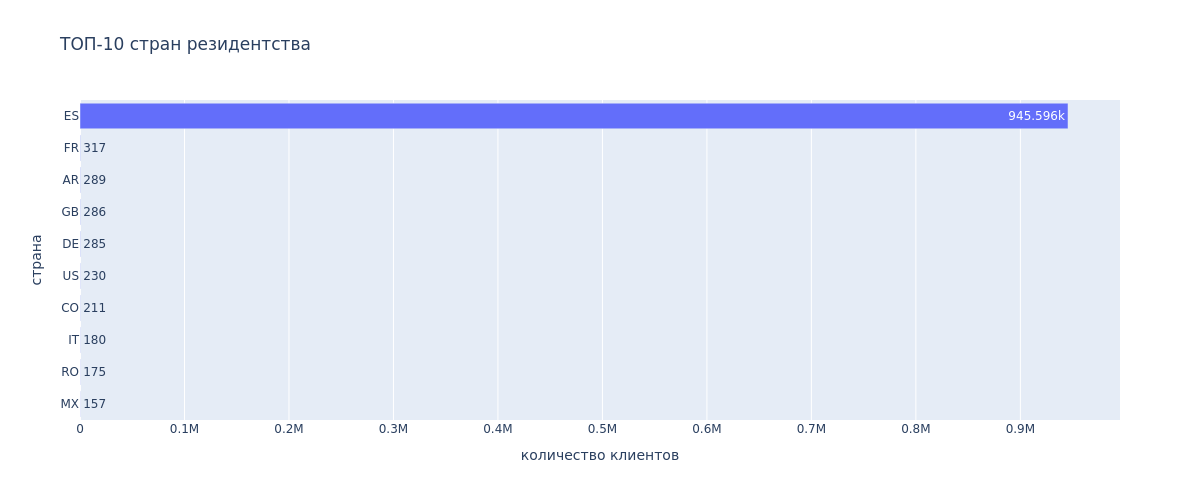

Клиентов из Испании: 945596 (98.85%)


In [43]:
fig = df.groupby("ncodpers")["pais_residencia"].last() \
    .value_counts().head(10).plot(
        kind="barh", text_auto=True,
        title="ТОП-10 стран резидентства",
        labels={"value": "количество клиентов", 
                "pais_residencia": "страна"})
fig.update_layout(height=500, width=1200, 
                  yaxis=dict(autorange="reversed"),
                  showlegend=False)
fig.write_html(PLOTS_DIR+"pais_residencia(1).html")
fig.show(renderer="png")

clients = df.groupby("ncodpers")["pais_residencia"].last()
clients = clients == "ES"
print(f"Клиентов из Испании: {clients.sum()} ({clients.mean():.2%})")

Практически все клиенты являются резидентами Испании, также в ТОП-10 вошли клиенты Европейских стран а также стран Южной и Серверной Америк, однако таких клиентов существенно меньше.

In [44]:
clients = df.groupby("ncodpers")["pais_residencia"] \
    .nunique().loc[lambda x: x > 1].index
print("Клиентов с разными странами резиденции:", len(clients))
df.loc[df["ncodpers"].isin(clients), feats].tail(20)

Клиентов с разными странами резиденции: 106


,fecha_dato,ncodpers,pais_residencia,indresi,indext,tipodom,cod_prov,nomprov
13257028,2016-01-28,1472391,ES,S,N,1.00,43.00,TARRAGONA
13257029,2016-02-28,1472391,US,S,N,1.00,NaN,NaN
13257030,2016-03-28,1472391,US,N,N,1.00,NaN,NaN
13257031,2016-04-28,1472391,US,N,N,1.00,NaN,NaN
13257032,2016-05-28,1472391,US,N,N,1.00,NaN,NaN
13507234,2015-11-28,1508801,ES,S,N,1.00,41.00,SEVILLA
13507235,2015-12-28,1508801,ES,S,N,1.00,41.00,SEVILLA
13507236,2016-01-28,1508801,ES,S,N,1.00,41.00,SEVILLA
13507237,2016-02-28,1508801,GB,N,N,1.00,NaN,NaN
13507238,2016-03-28,1508801,GB,N,N,1.00,NaN,NaN


По таким клиентам можно отметить, что довольно часто страна изначально указывается как Испания, но через некоторое время изменяется как страна, так и признак резидентства. Это может быть как признак переезда, так и вероятные ошибки ввода. Также можно заметить, что признак отличия резидентства клиента и банка может быть не сразу изменен, как у клиента 1472391, который поменялся только на следующий месяц.

Оценим какой процент клиентов являются резидентами Испания в первые месяцы, а также все ли эти клиенты являются уроженцами Испании.

In [45]:
print(
    "Процент резидентов Испании в начале:",
    df[df["ncodpers"].isin(clients)] \
        .groupby("ncodpers")["pais_residencia"] \
        .agg(lambda x: x.iloc[0] == "ES").mean().round(2),
    "%")
print(
    "Процент уроженцев Испании:",
    df[df["ncodpers"].isin(clients)] \
        .groupby("ncodpers")["indext"] \
        .agg(lambda x: x.iloc[0] == "N").mean().round(2),
    "%")

Процент резидентов Испании в начале: 0.59 %
Процент уроженцев Испании: 0.81 %


Только 59% клиентов сначала являлись резидентами Испании, также не все клиенты являлись уроженцами. Вероятнее всего такие данные говорят о переезде клиентов.

Оценим наличие информации о доходах для нерезидентов.

In [46]:
# Количество нерезидентов с указанными доходами
clients = df[df["pais_residencia"] != "ES"] \
    .groupby("ncodpers")["renta"] \
    .agg(lambda x: x.notna().any())
clients = clients[clients].index
print(
    "Клиентов нерезидентов с указанными доходами:",
    len(clients))
print()
# Стран для нерезидентов с доходами
print("Распределение клиентов по количеству стран:")
display(df[df["ncodpers"].isin(clients)] \
    .groupby("ncodpers")["pais_residencia"] \
    .nunique().value_counts().to_frame())
# Сколько имеют 2 страну Испанию
print(
    "Из них резиденты Испании:",
    df[df["ncodpers"].isin(clients)] \
        .groupby("ncodpers")["pais_residencia"] \
        .agg(lambda x: x.str.contains("ES").any()) \
        .sum())
# Первы записи клиентов с 1 страной
clients = df[df["ncodpers"].isin(clients)] \
    .groupby("ncodpers")["pais_residencia"] \
    .nunique().loc[lambda x: x == 1].index
print()
print("Первые записи клиентов с одной страной резиденции:")
df.loc[
    df["ncodpers"].isin(clients), 
    feats + ["renta"]
].groupby("ncodpers").head(2)

Клиентов нерезидентов с указанными доходами: 49

Распределение клиентов по количеству стран:


,count
pais_residencia,
2,44
1,5


Из них резиденты Испании: 44

Первые записи клиентов с одной страной резиденции:


,fecha_dato,ncodpers,pais_residencia,indresi,indext,tipodom,cod_prov,nomprov,renta
1008994,2015-01-28,142775,DE,N,S,1.00,28.00,MADRID,141913.68
1008995,2015-02-28,142775,DE,N,S,1.00,28.00,MADRID,141913.68
1054613,2015-01-28,148749,BO,N,S,1.00,28.00,MADRID,94299.96
1054614,2015-02-28,148749,BO,N,S,1.00,28.00,MADRID,94299.96
1133618,2015-01-28,158803,IT,N,S,1.00,28.00,MADRID,149309.34
1133619,2015-02-28,158803,IT,N,S,1.00,28.00,MADRID,149309.34
1270117,2015-01-28,176484,IT,N,S,1.00,28.00,MADRID,669790.32
1270118,2015-02-28,176484,IT,N,S,1.00,28.00,MADRID,669790.32
3183943,2015-01-28,425950,PY,N,N,1.00,19.00,GUADALAJARA,128107.92
3183944,2015-02-28,425950,PY,N,N,1.00,19.00,GUADALAJARA,128107.92


Судя по всему данные по доходам у иностранных клиентов банка не запрашиваются. Имеются всего 49 клиентов с записями, причем у 44 из них указаны 2 страны, вторая из которых Испания. У оставшихся 5 клиентов указана одна страна, однако у таких клиентов имеются сведения о провинции и данные начинаются с января 2015 года, поэтому можно сделать предположение, что ранее они были отмечены как резиденты Испании, а в последствии страна резиденции была исправлена, а код и наименование провинции нет.

Таким образом, доходы для иностранных резидентов определить невозможно.

#### Резидент страны банка

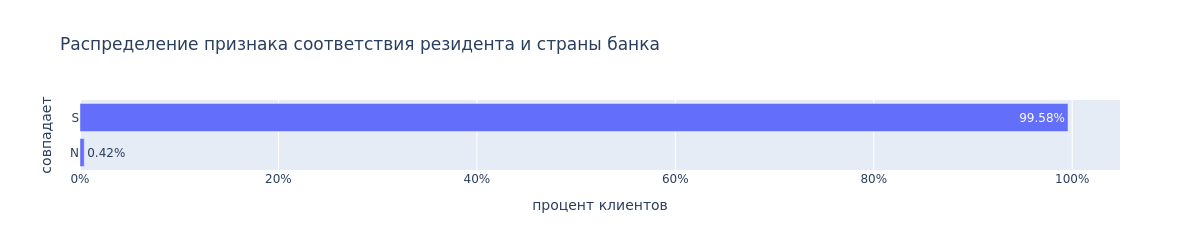

In [47]:
fig = df.groupby("ncodpers")["indresi"].last() \
    .value_counts(normalize=True).head(10).plot(
        kind="barh", text_auto=True,
        title="Распределение признака соответствия резидента и страны банка",
        labels={"value": "процент клиентов", 
                "indresi": "совпадает"})
fig.update_traces(texttemplate="%{x:.2%}")
fig.update_layout(
    height=250, width=1200, 
    showlegend=False,
    yaxis=dict(autorange="reversed"),
    xaxis_tickformat=".0%")
fig.write_html(PLOTS_DIR+"indresi(1).html")
fig.show(renderer="png")

Большая часть клиентов являются резидентами страны банка. Взглянем на количество клиентов без значений.

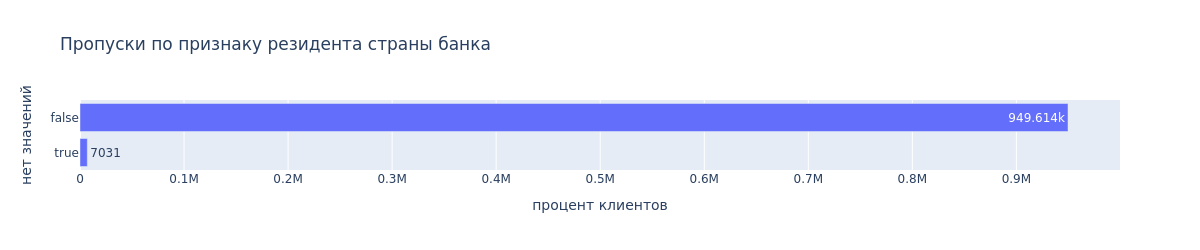

Некорректных записей: 5


In [48]:
fig = df.groupby("ncodpers")["indresi"] \
    .agg(lambda x: x.isna().all()) \
    .value_counts().plot(
        kind="barh", text_auto=True,
        title="Пропуски по признаку резидента страны банка",
        labels={"value": "процент клиентов", 
                "indresi": "нет значений"})
fig.update_layout(
    height=250, width=1200, 
    showlegend=False,
    yaxis=dict(autorange="reversed"))
fig.write_html(PLOTS_DIR+"indresi(2).html")
fig.show(renderer="png")

# некорректные записи
clients = (
    (df["indresi"] == "S") & 
    (df["pais_residencia"] != "ES"))
clients = clients | (
    (df["indresi"] == "N") & 
    (df["pais_residencia"] == "ES"))
print("Некорректных записей:", clients.sum())

 Имеются порядка 7 тысяч записей, у которых отсутствуют значения признака соответствия страны банка. Также имеются несоотвесттвия по 5 записям, оценим записи таких клиентов.

In [49]:
clients = clients | clients.shift(-1) | clients.shift(1)
df.loc[clients, feats]

,fecha_dato,ncodpers,pais_residencia,indresi,indext,tipodom,cod_prov,nomprov
233935,2016-02-28,47550,CL,N,N,1.00,NaN,NaN
233936,2016-03-28,47550,ES,N,N,1.00,28.00,MADRID
233937,2016-04-28,47550,ES,S,N,1.00,28.00,MADRID
338953,2016-01-28,61163,CH,N,N,1.00,NaN,NaN
338954,2016-02-28,61163,ES,N,N,1.00,28.00,MADRID
338955,2016-03-28,61163,ES,S,N,1.00,28.00,MADRID
2237795,2015-07-28,304433,ES,S,S,1.00,45.00,TOLEDO
2237796,2015-08-28,304433,CO,S,S,1.00,NaN,NaN
2237797,2015-09-28,304433,CO,N,S,1.00,NaN,NaN
6034282,2016-01-28,834558,ES,S,S,1.00,8.00,BARCELONA


Имеются только записи, у которых расхождения в тот месяц, когда произошли изменения со страны ES на другую, а смена признака резидентства со страной банка произошла в следующий месяц.

#### Признак иностранца

Оценим признак отличия страны рождения от страны банка.

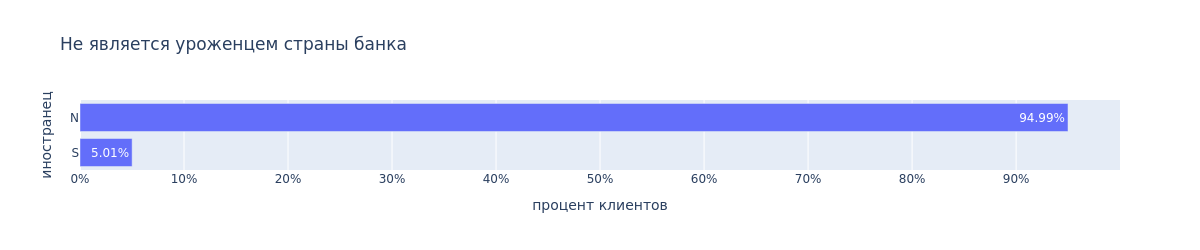

In [50]:
fig = df.groupby("ncodpers")["indext"].last() \
    .value_counts(normalize=True).plot(
        kind="barh", text_auto=True,
        title="Не является уроженцем страны банка",
        labels={"indext": "иностранец", 
                "value": "процент клиентов"})
fig.update_traces(texttemplate="%{x:.2%}")
fig.update_layout(
    height=250, width=1200, 
    showlegend=False,
    yaxis=dict(autorange="reversed"),
    xaxis_tickformat=".0%")
fig.write_html(PLOTS_DIR+"indext(1).html")
fig.show(renderer="png")

Большая часть клиентов не являются иностранцами по рождению, оценим какое количество пропусков имеется в датасете.

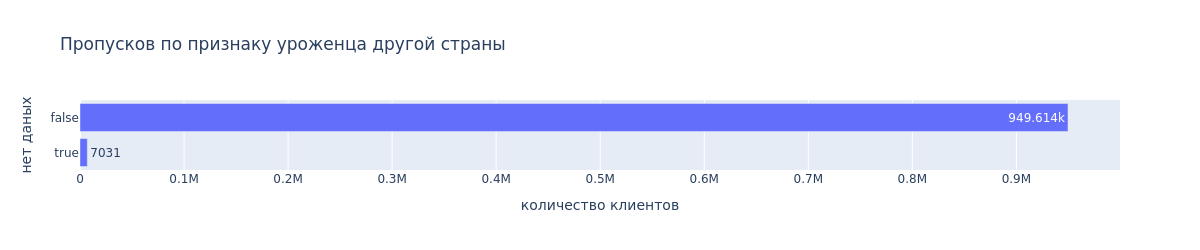

Количество клиентов с 2-мя значениями: 235


In [51]:
fig = df.groupby("ncodpers")["indext"] \
    .agg(lambda x: x.isna().all()) \
    .value_counts().plot(
        kind="barh", text_auto=True,
        title="Пропусков по признаку уроженца другой страны",
        labels={"indext": "нет даных", "value": "количество клиентов"}
    )
fig.update_layout(
    height=250, width=1200, 
    showlegend=False,
    yaxis=dict(autorange="reversed"))
fig.write_html(PLOTS_DIR+"indext(2).html")
fig.show(renderer="png")

# Два значения признака
clients = df.groupby("ncodpers")["indext"].nunique() \
    .loc[lambda x: x > 1].index
print(f"Количество клиентов с 2-мя значениями: {len(clients)}")

Пропусков также порядка 7 тысяч, возможно это одни и те же клиенты. В части двойных значений признака рождения в стране, отличной от страны банка - имеется у 235 клиентов. Взглянем на выгрузки таких клиентов.

In [52]:
display(df.loc[df["ncodpers"].isin(clients), feats].tail(15))

# Оценка первых и последних значений
clients = df[df["ncodpers"].isin(clients)] \
    .groupby("ncodpers")["indext"].first() == "N"
print(f"Значение 'N' в первых записях: {clients.sum()} ({clients.mean():.2%})")

,fecha_dato,ncodpers,pais_residencia,indresi,indext,tipodom,cod_prov,nomprov
13591173,2016-02-28,1526766,ES,S,S,1.00,41.00,SEVILLA
13591174,2016-03-28,1526766,ES,S,S,1.00,41.00,SEVILLA
13591175,2016-04-28,1526766,ES,S,N,1.00,41.00,SEVILLA
13591176,2016-05-28,1526766,ES,S,N,1.00,41.00,SEVILLA
13604764,2016-02-28,1530946,ES,S,S,1.00,39.00,CANTABRIA
13604765,2016-03-28,1530946,ES,S,N,1.00,39.00,CANTABRIA
13604766,2016-04-28,1530946,ES,S,N,1.00,39.00,CANTABRIA
13604767,2016-05-28,1530946,ES,S,N,1.00,39.00,CANTABRIA
13606715,2016-02-28,1531624,ES,S,S,1.00,28.00,MADRID
13606716,2016-03-28,1531624,ES,S,S,1.00,28.00,MADRID


Значение 'N' в первых записях: 2 (0.85%)


Возможно изначально таких клиентов записывали как иностранца, впоследствии данная информация была изменена при получении корректной информации. Причем основная масса помечается как иностранец, обратных случаев существенно меньше. По данному признаку необходимо заполнять все записи последним значением по дате.

#### Тип адреса

По типу адреса было только одно значение - 1, оценим количество пропусков у клиентов по данному полю.

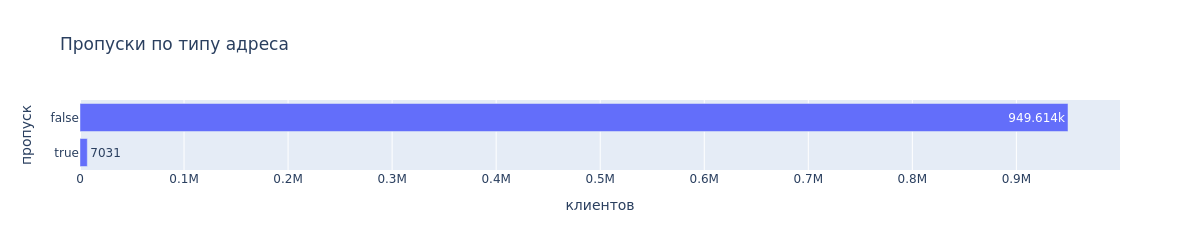

In [53]:
fig = df.groupby("ncodpers")["tipodom"].agg(lambda x: x.isna().all()) \
    .value_counts().plot(
        kind="barh", text_auto=True,
        title="Пропуски по типу адреса",
        labels={"tipodom": "пропуск", "value": "клиентов"})
fig.update_layout(
    height=250, width=1200,
    yaxis=dict(autorange="reversed"),
    showlegend=False)
fig.write_html(PLOTS_DIR+"tipodom(1).html")
fig.show(renderer="png")

Отсутствует данные также по 7 тысячам клиентов, по которым отсутствовали другие адресные данные. Данный признак не несет никакой информации и подлежит удалению.

#### Регион

В датасете имеются 2 поля, обозначающие регион клиента. Оценим количество значений по каждому региону.

In [54]:
print(
    "Расхождений в коде и наименовании региона:",
    (df.groupby("cod_prov")["nomprov"].nunique() > 1).sum())

print(
    "Страны, для которых имеется регион:",
    df[df["cod_prov"].notna()]["pais_residencia"].unique())

Расхождений в коде и наименовании региона: 0
Страны, для которых имеется регион: ['ES' 'DE' 'BO' 'IT' 'PY']


Расхождений между кодом и наименованием региона не наблюдается. Однако имеются регионы для других стран, кроме Испании. Взглянем на такие значения.

In [55]:
print("Страны и названия повинций:")
clients = df[(df["pais_residencia"] != "ES") & df["nomprov"].notna()]
display(
    clients.groupby("pais_residencia")["nomprov"].unique().to_dict())

clients = clients["ncodpers"].unique()
print(f"Клиентов с регионами в других сранах: {len(clients)}")

Страны и названия повинций:


{'BO': array(['MADRID'], dtype=object),
 'DE': array(['MADRID'], dtype=object),
 'IT': array(['MADRID'], dtype=object),
 'PY': array(['PALMAS, LAS', 'GUADALAJARA'], dtype=object)}

Клиентов с регионами в других сранах: 6


По 6 клиентам имеются записи, где указан регион Мадрид для стран Боливия, Германи, Италия, а для Парагвая указаны два региона. Посмотрим выгрузки по указанным клиентам, оценим только первые и последние значения.

In [56]:
clients = df.loc[df["ncodpers"].isin(clients), feats]
pd.concat([
    clients.groupby("ncodpers").head(1),
    clients.groupby("ncodpers").tail(1)])

,fecha_dato,ncodpers,pais_residencia,indresi,indext,tipodom,cod_prov,nomprov
1008994,2015-01-28,142775,DE,N,S,1.00,28.00,MADRID
1054613,2015-01-28,148749,BO,N,S,1.00,28.00,MADRID
1133618,2015-01-28,158803,IT,N,S,1.00,28.00,MADRID
1270117,2015-01-28,176484,IT,N,S,1.00,28.00,MADRID
3096315,2015-01-28,415005,PY,N,N,1.00,35.00,"PALMAS, LAS"
3183943,2015-01-28,425950,PY,N,N,1.00,19.00,GUADALAJARA
1009010,2016-05-28,142775,DE,N,S,1.00,28.00,MADRID
1054629,2016-05-28,148749,BO,N,S,1.00,28.00,MADRID
1133634,2016-05-28,158803,IT,N,S,1.00,28.00,MADRID
1270133,2016-05-28,176484,IT,N,S,1.00,NaN,NaN


Видимо для части клиентов изначально были введены данные некорректно, что присутствует провинция при указании другой страны. Также можно отметить, что для всех таких случаев информация имеется с января 2015 года, возможно ранее не было проверки такого условия. Так как для новых клиентов такой проблемы не наблюдается, возможно данная проблема была ранее но впоследствии была исправлена. Для таких клиентов необходимо удалить данные о провинции заменив их пропусками.

Оценим наличие пропусков по провинции, если указана страна Испания.

In [57]:
clients = df.loc[
    (df["pais_residencia"] == "ES") & df["nomprov"].isna(), 
    feats]
print(f"Количество записей с пропусками: {len(clients)}")

clients = clients["ncodpers"].unique()
print(f"Количество клиентов: {len(clients)}")

Количество записей с пропусками: 92
Количество клиентов: 7


Имеются пропуски в записях по региону у которых страна резиденции указана как Испания. Оценим записи для таких клиентов.

In [58]:
clients = df.loc[df["ncodpers"].isin(clients), feats]
display(clients[
    lambda x: x.groupby("ncodpers")["nomprov"] \
        .transform(lambda x: x.notna().any())])

print(
    "Клиентов, имеющих значения провинции:",
    clients.groupby("ncodpers")["nomprov"] \
        .agg(lambda x: x.notna().any()).sum())

,fecha_dato,ncodpers,pais_residencia,indresi,indext,tipodom,cod_prov,nomprov
187768,2015-01-28,41449,NaN,NaN,NaN,NaN,NaN,NaN
187769,2015-02-28,41449,NaN,NaN,NaN,NaN,NaN,NaN
187770,2015-03-28,41449,NaN,NaN,NaN,NaN,NaN,NaN
187771,2015-04-28,41449,NaN,NaN,NaN,NaN,NaN,NaN
187772,2015-05-28,41449,NaN,NaN,NaN,NaN,NaN,NaN
187773,2015-06-28,41449,NaN,NaN,NaN,NaN,NaN,NaN
187774,2015-11-28,41449,ES,S,N,NaN,NaN,NaN
187775,2015-12-28,41449,ES,S,N,1.00,28.00,MADRID
187776,2016-01-28,41449,ES,S,N,1.00,28.00,MADRID
187777,2016-02-28,41449,ES,S,N,1.00,28.00,MADRID


Клиентов, имеющих значения провинции: 2


Среди таких клиентов всего у 2-х из 7-ми имеются записи, которые располагаются в последних выгрузках, по остальным клиентам только пропуски. 

Взглянем на ТОП-10 регионов по количеству клиентов.

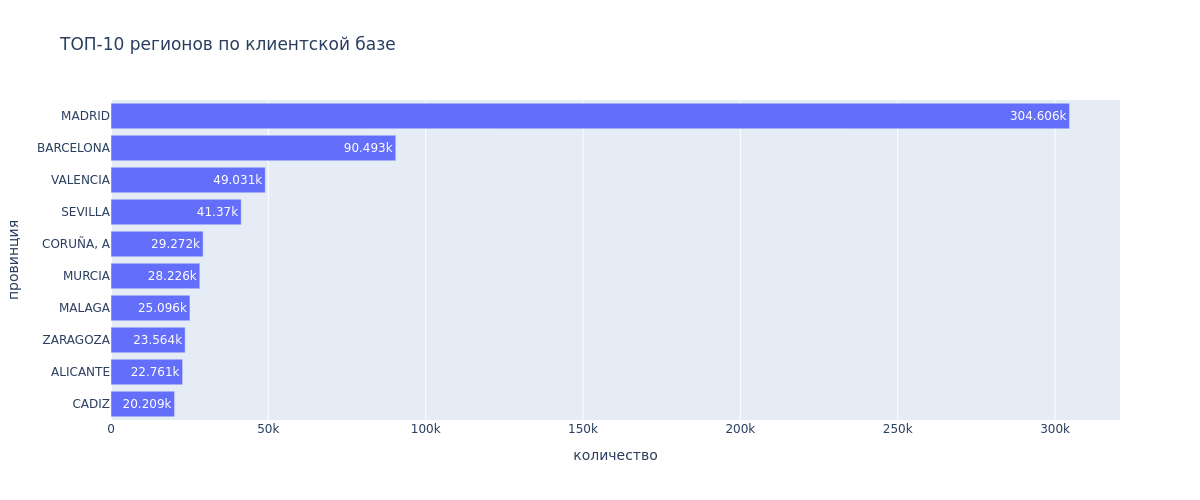

In [59]:
fig = df.groupby("ncodpers")["nomprov"].agg("last") \
    .value_counts().head(10).plot(
        kind="barh", text_auto=True,
        title="ТОП-10 регионов по клиентской базе",
        labels={"nomprov": "провинция", "value": "количество"})
fig.update_layout(
    height=500, width=1200,
    yaxis=dict(autorange="reversed"),
    showlegend=False)
fig.write_html(PLOTS_DIR+"nomprov(1).html")
fig.show(renderer="png")

Наибольшее число клиентов относятся к провинции Мадрид, с более чем трехкратным отрывом по количеству клиентов располагается провинция Барселона, тройку лидеров с почти двукратным отрывом от предыдущего региона располагается Валенсия. Остальные регионы по количеству клиентов снижаются не так существенно по сравнению с предыдущим, ТОП-10 замыкает регион Кадиз.

Пропуски резидентов Испании по региону лучше заполнять ближайшим непустым значением с сортировкой по дате выгрузки, а если все значения пропущены - медианой или другим способом типа kNN или классификационной моделью. Для обработки расхождений по стране и региону, а также признаку нахождения в стране банка, подготовим функцию.

In [60]:
def fix_residence(
        data: pd.DataFrame, 
        client_col: str = "ncodpers",
        country_col: str = "pais_residencia",
        residence_col: str = "indresi",
        province_col: str = "nomprov",
        country_code: str = "ES"
):
    """
    Функция исправляет аномальные значения адресных данных
    клиентов банка.
    1. Признак резидентства: True - если соответствует и 
    False - если не соответствует стране нахождения банка;
    2. Удаляет название провинции, если страна резиденции 
    не является страной нахождения банка.
    3. Заполняет методом ffill и bfill название провинции 
    для резидентов на случай пропусков в данных.
    """
    data = data.copy()
    # Исправление значений по индикатору резиденции
    country_ids = data[country_col] == country_code
    data[residence_col] = country_ids
    # Исправление значений провинции
    data.loc[~country_ids, province_col] = np.nan
    data.loc[country_ids, province_col] = data[country_ids] \
        .groupby(client_col).ffill()
    data.loc[country_ids, province_col] = data[country_ids] \
        .groupby(client_col).bfill()
    return data

Проверим работу функции.

In [61]:
cols = ["fecha_dato", "ncodpers", "pais_residencia", 
       "indresi", "nomprov"]

# Признак резиденции +/- одна строка
clients = (
    ((df["pais_residencia"] == "ES") & (df["indresi"] == "N")) | 
    ((df["pais_residencia"] != "ES") & (df["indresi"] == "S")))
clients = clients | clients.shift(1, fill_value=False)
clients = clients | clients.shift(-1, fill_value=False)

# Признак пропуска региона 1-я и последняя строка
clients = clients | (
    (df[(df["pais_residencia"] != "ES") & df["nomprov"].notna()] \
        .groupby("ncodpers").cumcount() == 0) |
    (df[(df["pais_residencia"] != "ES") & df["nomprov"].notna()] \
        .groupby("ncodpers").cumcount(ascending=False) == 0))

df.loc[clients, cols].merge(
    fix_residence(df[clients])[cols].drop(columns="pais_residencia"),
    on=["fecha_dato", "ncodpers"], how="left", suffixes=("", "_new"))

,fecha_dato,ncodpers,pais_residencia,indresi,nomprov,indresi_new,nomprov_new
0,2016-02-28,47550,CL,N,NaN,False,NaN
1,2016-03-28,47550,ES,N,MADRID,True,MADRID
2,2016-04-28,47550,ES,S,MADRID,True,MADRID
3,2016-01-28,61163,CH,N,NaN,False,NaN
4,2016-02-28,61163,ES,N,MADRID,True,MADRID
5,2016-03-28,61163,ES,S,MADRID,True,MADRID
6,2015-01-28,142775,DE,N,MADRID,False,NaN
7,2016-05-28,142775,DE,N,MADRID,False,NaN
8,2015-01-28,148749,BO,N,MADRID,False,NaN
9,2016-05-28,148749,BO,N,MADRID,False,NaN


Функция произвела замену бинарных признаков проживания в стране банка со значений 'S'/'N' на логические True/False, также исправлены значения региона на пропуски, если страна не Испания. Обработку пропусков необходимо выполнять после исправления признаков.

Взглянем на средние значения доходов по региону.

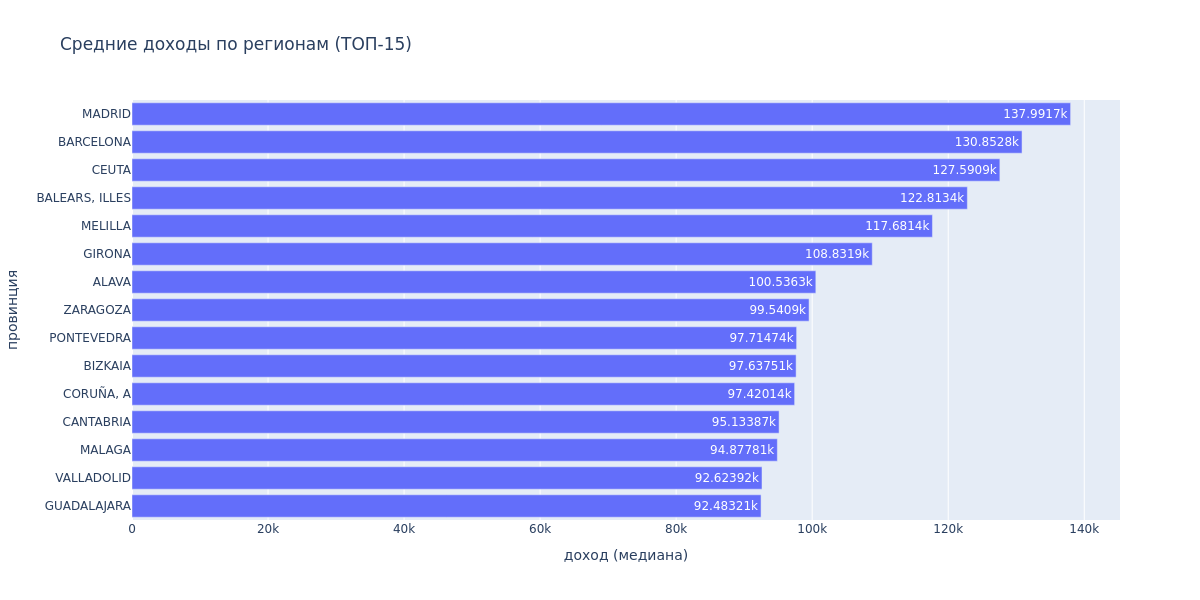

In [62]:
fig = df.groupby("ncodpers").tail(1) \
    .groupby("nomprov")["renta"].median() \
    .sort_values().tail(15).plot(
        kind="barh", text_auto=True,
        title="Средние доходы по регионам (ТОП-15)",
        labels={"nomprov": "провинция", "value": 
                "доход (медиана)"})
fig.update_layout(
    height=600, width=1200,
    showlegend=False)
fig.write_html(PLOTS_DIR+"nomprov(2)_renta.html")
fig.show(renderer="png")

По медианным доходам домохозяйств в разрезе регионов различия имеются но не существенно большие. Самый большой как по количеству клиентов, так и по доходам является Мадрид, за ним также идет Барселона, а дальше уже данные по доходам и по количеству клиентов расходятся. Взглянем на доходы регионов с самыми низкими медианными значениями.

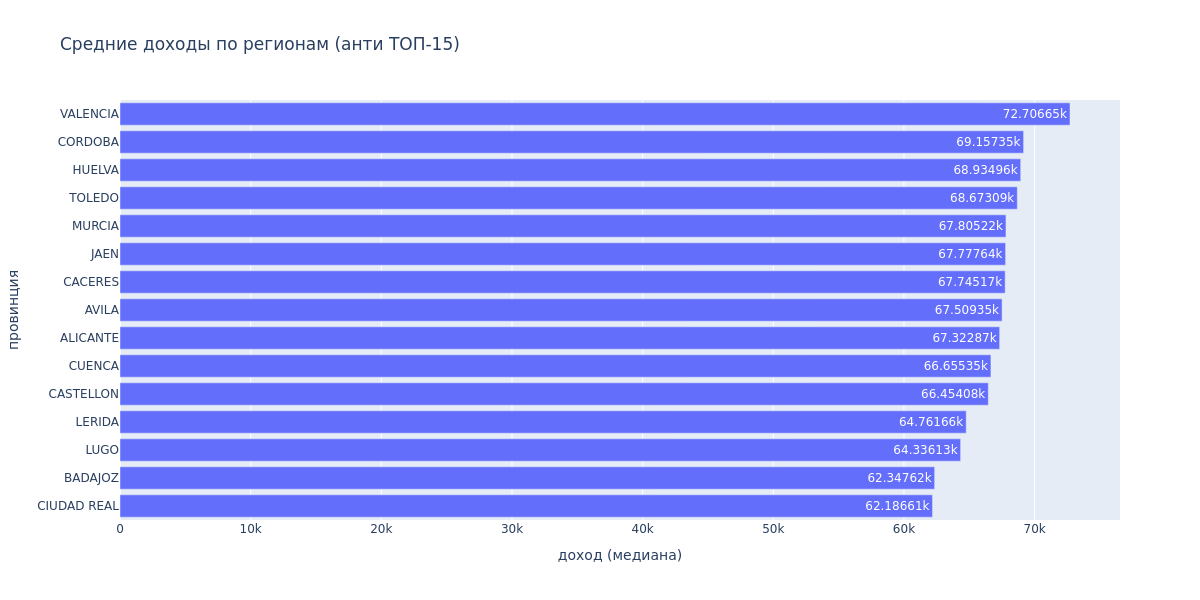

In [63]:
fig = df.groupby("ncodpers").tail(1) \
    .groupby("nomprov")["renta"].median() \
    .sort_values().head(15).plot(
        kind="barh", text_auto=True,
        title="Средние доходы по регионам (анти ТОП-15)",
        labels={"nomprov": "провинция", "value": 
                "доход (медиана)"})
fig.update_layout(
    height=600, width=1200,
    showlegend=False)
fig.write_html(PLOTS_DIR+"nomprov(3)_renta.html")
fig.show(renderer="png")

Среди регионов с самыми низкими доходами вошла Валенсия, которая занимает третью строчку по количеству и 15-ю с конца по доходам. Самые низкие регионы по доходам расходятся в 2 раза с самыми высокими.

#### Промежуточные выводы

По результатам оценки адресных данных и гражданства можно сделать 
следующие выводы:
1. Страна резидентства в основном представлена жителями Испании, 
остальные 117 стран распределены на 1.15% оставшегося датасета, 
статистика по таким клиентам будет ненадежна.
2. По признаку проживания в стране банка - он полностью дублирует 
предыдущий признак в части соответствия стране резиденции Испания. 
Однако встречаются расхождения, когда признак изменяется только 
в последующем месяце после смены страны резиденции.
3. По признаку отличия страны рождения и страны банка выявлена 
замена данного признака, вероятно данные были уточнены позднее и 
внесены изменения.
4. По типу адреса все значения равны 1, данный признак бесполезен.
5. По региону имеются 2 признака, которые дублируют друг друга - 
числовой код и название провинции. Они имеются только для страны 
Испания, однако встречаются аномалии - наличие региона для другой 
страны, а также отсутствие региона для Испании.

**Рекомендации по исправлению**:
- Исключить признак типа адреса и кода региона, а также страны 
резидентства, так как дублирует признак проживания в стране банка 
для значительной части датасета. Для региона оставить название, 
так как это категориальный признак и не имеет смысла использовать 
код региона без преобразования.
- Заполнить признак иностранца последним значением, а пропуски - 
следующими значениями по дате (метод обратного заполнения `bfill`);
- Обработать аномалии по стране резидентства и признакам проживания 
и рождения в стране банка функцией `fix_residence`.
- Пропуски названий региона, если страна резиденции отличается от 
страны нахождения банка закрыть заглушкой типа `unknown`.
- Пропущенные данные по региону в стране нахождения банка стоит 
заполнить самым частым значением, либо другими ML инструментами.

### Взаимоотношения с банком

В части взаимоотношений с банком можно выделить следующие признаки:
- `fecha_alta` – Дата, когда клиент впервые заключил договор в банке.
- `antiguedad` – Стаж клиента (в месяцах).
- `ind_nuevo` – Признак регистрации клиента за последние 6 месяцев.
- `canal_entrada` - Канал, по которому пришел клиент.
- `indrel` – Тип отношений с банком (1 – основной клиент, 99 – бывший клиент).
- `indfall` - Индекс актуальности счёта (англ. Deceased index, N/S).
- `ind_actividad_cliente` - Активность клиента (1 — активный, 0 — неактивный).
- `tiprel_1mes` – Тип отношений клиента в начале месяца:
    - A — активный
    - I — неактивный
    - P — бывший
    - R — потенциальный
- `indrel_1mes` – Тип клиента в начале месяца:
    - 1 — премиальный
    - 2 — собственник
    - P — потенциальный
    - 3 — раньше был премиальным
    - 4 — раньше был собственником
- `ult_fec_cli_1t` – Последняя дата, когда клиент был премиальным.

#### Обзор признаков

In [64]:
# Список общих признаков о клиенте
feats = [
    "fecha_dato", "ncodpers", "fecha_alta", "antiguedad", "ind_nuevo",
    "canal_entrada", "indrel", "indfall", "ind_actividad_cliente",
    "indrel_1mes", "tiprel_1mes", "ult_fec_cli_1t"]

df[feats].head(20)

,fecha_dato,ncodpers,fecha_alta,antiguedad,ind_nuevo,canal_entrada,indrel,indfall,ind_actividad_cliente,indrel_1mes,tiprel_1mes,ult_fec_cli_1t
0,2015-01-28,15889,1995-01-16,245.00,0.00,KAT,1.00,N,1.00,1,A,NaT
1,2015-02-28,15889,1995-01-16,245.00,0.00,KAT,1.00,N,1.00,1,A,NaT
2,2015-03-28,15889,1995-01-16,245.00,0.00,KAT,1.00,N,1.00,1,A,NaT
3,2015-04-28,15889,1995-01-16,245.00,0.00,KAT,1.00,N,1.00,1,A,NaT
4,2015-05-28,15889,1995-01-16,245.00,0.00,KAT,1.00,N,1.00,1,A,NaT
5,2015-06-28,15889,1995-01-16,245.00,0.00,KAT,1.00,N,1.00,1,A,NaT
6,2015-07-28,15889,1995-01-16,245.00,0.00,KAT,1.00,N,1.00,1,A,NaT
7,2015-08-28,15889,1995-01-16,246.00,0.00,KAT,1.00,N,1.00,1,A,NaT
8,2015-09-28,15889,1995-01-16,247.00,0.00,KAT,1.00,N,1.00,1,A,NaT
9,2015-10-28,15889,1995-01-16,248.00,0.00,KAT,1.00,N,1.00,1,A,NaT


Заметно, что стаж клиента в месяцах может повторяться, при этом клиент не новый и активный, а счет актуальный - возможно имеются проблемы с такими данными. Оценим количество уникальных значений признаков.

In [65]:
# Количество уникальных значений
print("Уникальных значений признаков:")
df[feats].nunique()

Уникальных значений признаков:


fecha_dato                   17
ncodpers                 956645
fecha_alta                 6756
antiguedad                  258
ind_nuevo                     2
canal_entrada               162
indrel                        2
indfall                       2
ind_actividad_cliente         2
indrel_1mes                   9
tiprel_1mes                   5
ult_fec_cli_1t              223
dtype: int64

Признаки нового клиента, типа отношений с банком, актуальности счета и активности клиента вероятно являются бинарными. Статус отношений и тип отношений являются категориальными с небольшим количеством категорий, а вот канал по которому зашел клиент имеет довольно большое количество категорий. Взглянем на уникальные значения категориальных признаков.

In [66]:
cols = ["ind_nuevo", "indrel", "indrel_1mes", 
        "tiprel_1mes", "canal_entrada",
        "indfall", "ind_actividad_cliente"]
for col in cols:
    print(f"{col}:")
    display(df[col].unique())

ind_nuevo:


array([ 0.,  1., nan])

indrel:


array([ 1., 99., nan])

indrel_1mes:


...

array(['KAT', '013', 'KFA', nan, 'KFC', 'KAS', '007', 'KHK', 'KCH', 'KHN',
       'KHC', 'KFD', 'RED', 'KAW', 'KHM', 'KCC', 'KAY', 'KBW', 'KAG',
       'KBZ', 'KBO', 'KEL', 'KCI', 'KCG', 'KES', 'KBL', 'KBQ', 'KFP',
       'KEW', 'KAD', 'KDP', 'KAE', 'KAF', 'KAA', 'KDO', 'KEY', 'KHL',
       'KEZ', 'KAH', 'KAR', 'KHO', 'KHE', 'KBF', 'KBH', 'KAO', 'KFV',
       'KDR', 'KBS', 'KCM', 'KAC', 'KCB', 'KAL', 'KGX', 'KFT', 'KAQ',
       'KFG', 'KAB', 'KAZ', 'KGV', 'KBJ', 'KCD', 'KDU', 'KAJ', 'KEJ',
       'KBG', 'KAI', 'KBM', 'KDQ', 'KAP', 'KDT', 'KBY', 'KAM', 'KFK',
       'KFN', 'KEN', 'KDZ', 'KCA', 'KHQ', 'KFM', '004', 'KFH', 'KFJ',
       'KBR', 'KFE', 'KDX', 'KDM', 'KDS', 'KBB', 'KFU', 'KAV', 'KDF',
       'KCL', 'KEG', 'KDV', 'KEQ', 'KAN', 'KFL', 'KDY', 'KEB', 'KGY',
       'KBE', 'KDC', 'KBU', 'KAK', 'KBD', 'KEK', 'KCF', 'KED', 'KAU',
       'KEF', 'KFR', 'KCU', 'KCN', 'KGW', 'KBV', 'KDD', 'KCV', 'KBP',
       'KCT', 'KBN', 'KCX', 'KDA', 'KCO', 'KCK', 'KBX', 'KDB', 'KCP',
       'KDE', '

indfall:


array(['N', 'S', nan], dtype=object)

ind_actividad_cliente:


array([ 1.,  0., nan])

По всем признакам имеются пропуски, также имеется неизвестный тип отношений с клиентом - "N". Оценим изменчивость признаков у клиентов.

In [67]:
df.groupby("ncodpers")[feats[2:]] \
    .nunique().describe(percentiles=PERCENTILES).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
fecha_alta,956645.00,0.99,0.09,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00
antiguedad,956645.00,10.18,2.08,0.00,1.00,5.00,11.00,11.00,11.00,11.00,11.00,11.00
ind_nuevo,956645.00,1.11,0.34,0.00,1.00,1.00,1.00,1.00,1.00,2.00,2.00,2.00
canal_entrada,956645.00,0.98,0.15,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,3.00
indrel,956645.00,1.01,0.15,0.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,2.00
indfall,956645.00,0.99,0.09,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00
ind_actividad_cliente,956645.00,1.08,0.29,0.00,1.00,1.00,1.00,1.00,1.00,2.00,2.00,2.00
indrel_1mes,956645.00,0.99,0.15,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,3.00
tiprel_1mes,956645.00,1.14,0.39,0.00,0.00,1.00,1.00,1.00,1.00,2.00,2.00,4.00
ult_fec_cli_1t,956645.00,0.02,0.14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,5.00


По дате начала отношений можно отметить, что встречаются две даты. Также можно отметить, что для всех клиентов максимальное количество различных месяцев составляет 11, хотя максимальным должно быть значение 17.

Наиболее часто меняющееся значение - тип отношений клиента в начале месяца и чаще встречаются 2 и более значений - не менее 5%. Также более высокая изменчивость по признаку типа клиента в начале месяца и каналу прихода, однако по ним чаще всего только одно значение. Также по всем 3-м признакам больше пропусков - не менее 1% от датасета. По остальным признакам максимум 2 значения, причем в основном только одно кроме признака новизны и активности клиента.

#### Дата начала отношений


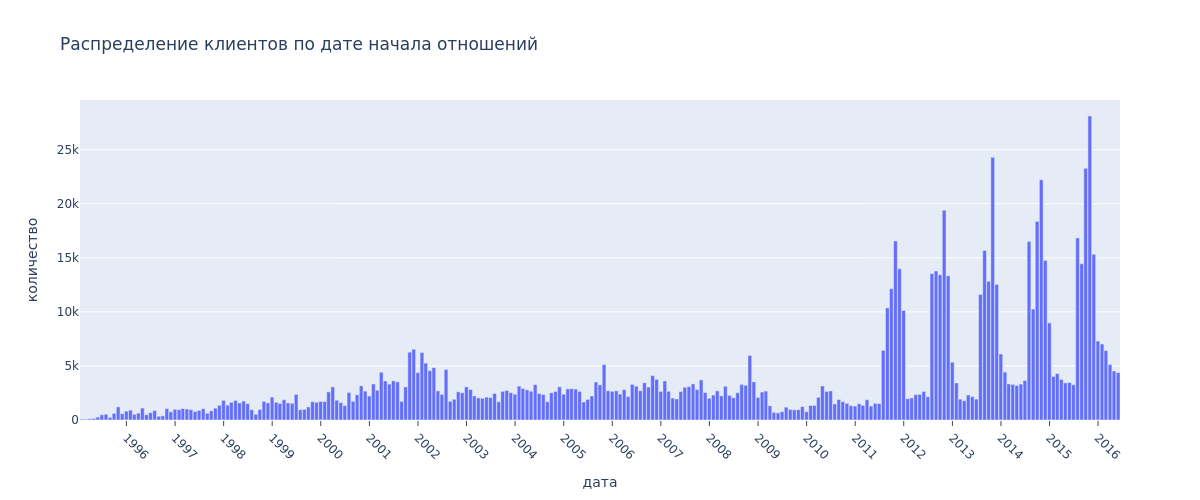

In [68]:
fig = (df.groupby("ncodpers")["fecha_alta"].agg("last") + 
       pd.offsets.MonthEnd(0)).value_counts().plot(
           kind="bar",
            title="Распределение клиентов по дате начала отношений",
            labels={"fecha_alta": "дата", "value": "количество"})
fig.update_layout(
    height=500, width=1200,
    showlegend=False, bargap=0,
    xaxis=dict(tickmode="linear", 
               dtick="M12", tickangle=45, 
               ticks="outside"))
fig.write_html(PLOTS_DIR+"fecha_alta(1).html")
fig.show(renderer="png")

По дате начала отношений можно отметить, что регистрация клиентов началась с 1995 года, количество новых клиентов в постепенно росло до 2002 года после чего рост замедлился. Также заметно снижение количества новых клиентов в 2009-2011 годы. С 2011 года можно отметить взрывной рост новых клиентов, который происходит ежегодно во втором полугодии и спадает к концу года.

Оценим количество клиентов без признака даты начала взаимоотношений.

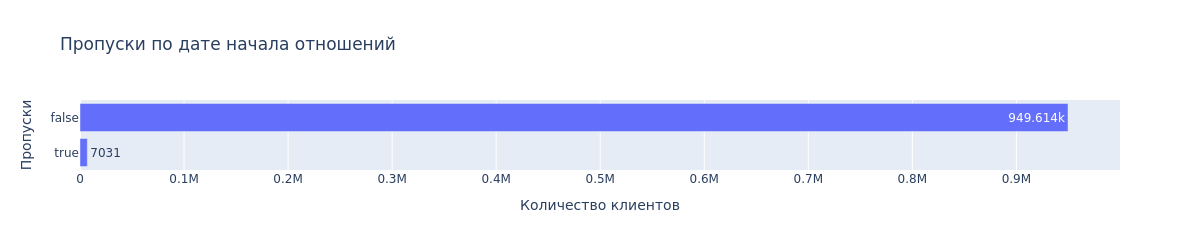

In [69]:
fig = df.groupby("ncodpers")["fecha_alta"] \
    .agg(lambda x: x.isna().all()).value_counts() \
    .plot(
        kind="barh", text_auto=True,
        title="Пропуски по дате начала отношений",
        labels={"fecha_alta": "Пропуски", 
                "value": "Количество клиентов"})
fig.update_layout(
    height=250, width=1200,
    yaxis=dict(autorange="reversed"),
    showlegend=False)
fig.write_html(PLOTS_DIR+"fecha_alta(2).html")
fig.show(renderer="png")

Полностью пропущены значения также у 7031 клиентов. Оценим наличие даты начала больше чем дата выгрузки.

In [70]:
clients = (df['fecha_alta'].dt.to_period("M") > 
           df['fecha_dato'].dt.to_period("M"))
print(
    f"Количество записей позже даты выгрузки: {clients.sum()}")

Количество записей позже даты выгрузки: 0


Все даты регистрации приходятся на месяц выгрузки. Взглянем на записи по клиентам с 2-мя датами начала регистрации.

In [71]:
clients = df.groupby("ncodpers")["fecha_alta"] \
    .nunique().loc[lambda x: x > 1]
clients = df.loc[df["ncodpers"].isin(clients.index), feats]
display(clients.tail(50))
print(
    "Клиентов с расхождениями:", 
    clients["ncodpers"].nunique())

,fecha_dato,ncodpers,fecha_alta,antiguedad,ind_nuevo,canal_entrada,indrel,indfall,ind_actividad_cliente,indrel_1mes,tiprel_1mes,ult_fec_cli_1t
12737270,2016-03-28,1408765,2010-03-11,72.00,0.00,KFD,1.00,N,1.00,1,A,NaT
12737271,2016-04-28,1408765,2010-03-11,73.00,0.00,KFD,1.00,N,0.00,1,A,NaT
12737272,2016-05-28,1408765,2010-03-11,74.00,0.00,KFD,1.00,N,0.00,1,A,NaT
13110484,2015-09-28,1453502,2015-09-17,0.00,1.00,NaN,1.00,N,1.00,NaN,NaN,NaT
13110485,2015-10-28,1453502,2008-07-30,1.00,1.00,KHM,1.00,N,1.00,1.0,A,NaT
13110486,2015-11-28,1453502,2008-07-30,2.00,1.00,KHM,1.00,N,1.00,1.0,A,NaT
13110487,2015-12-28,1453502,2008-07-30,3.00,1.00,KHM,1.00,N,1.00,1.0,A,NaT
13110488,2016-01-28,1453502,2008-07-30,4.00,1.00,KHM,1.00,N,1.00,1.0,A,NaT
13110489,2016-02-28,1453502,2008-07-30,5.00,1.00,KHM,1.00,N,1.00,1.0,A,NaT
13110490,2016-03-28,1453502,2008-07-30,6.00,0.00,KHM,1.00,N,1.00,1.0,A,NaT


Клиентов с расхождениями: 17


Имеются клиенты без каких-либо изменений, меняется только дата начала взаимодействия, причем это может быть как в большую так и в меншую сторону. Оценим наличие соответствия между датой регистрации, датой выгрузки и месяцем.

In [72]:
clients["check"] = ((
    clients["fecha_dato"].dt.year - 
    clients["fecha_alta"].dt.year) * 12 + (
    clients["fecha_dato"].dt.month - 
    clients["fecha_alta"].dt.month
))
clients["check"] = (
    clients["check"] == clients["antiguedad"].astype(int))
clients["fixable"] = clients.groupby("ncodpers")["check"] \
    .transform(lambda x: x.any())
print(
    "Количество клиентов с совпадениями:",
    clients.loc[clients["fixable"], "ncodpers"].nunique())
display(pd.concat([
    clients[clients["check"]].groupby("ncodpers").head(1),
    clients[~clients["check"]].groupby("ncodpers").head(1)
]).loc[lambda x: x["fixable"]] \
    .sort_values(["ncodpers", "fecha_dato"]).head(15))

print()
print("Записи клиентов без совпадений:")
clients[~clients["fixable"]].iloc[:,:-2]

Количество клиентов с совпадениями: 15


,fecha_dato,ncodpers,fecha_alta,antiguedad,ind_nuevo,canal_entrada,indrel,indfall,ind_actividad_cliente,indrel_1mes,tiprel_1mes,ult_fec_cli_1t,check,fixable
5209113,2015-01-28,703383,2007-07-16,96.00,0.00,KFA,1.00,N,0.00,1.0,I,NaT,False,True
5209119,2015-07-28,703383,2007-07-16,96.00,0.00,KFA,1.00,N,0.00,1.0,I,NaT,True,True
5217743,2015-01-28,704904,2007-07-21,96.00,0.00,KFC,1.00,N,0.00,1,I,NaT,False,True
5217745,2015-07-28,704904,2007-07-21,96.00,0.00,KFC,1.00,N,0.00,1,I,NaT,True,True
5711412,2016-01-28,784688,2016-01-25,0.00,1.00,NaN,1.00,N,0.00,NaN,NaN,NaT,True,True
5711415,2016-04-28,784688,2006-11-10,3.00,1.00,KHM,1.00,N,0.00,1.0,I,NaT,False,True
8785910,2015-09-28,1083881,2015-09-17,0.00,1.00,NaN,99.00,N,0.00,P,R,2015-09-17,True,True
9077130,2015-01-28,1105591,2012-11-26,32.00,0.00,KHE,1.00,N,1.00,1.0,A,NaT,False,True
9077136,2015-07-28,1105591,2012-11-26,32.00,0.00,KHE,1.00,N,1.00,1.0,A,NaT,True,True
12548907,2015-05-28,1386925,2015-03-10,4.00,1.00,KHL,1.00,N,1.00,1,A,NaT,False,True



Записи клиентов без совпадений:


,fecha_dato,ncodpers,fecha_alta,antiguedad,ind_nuevo,canal_entrada,indrel,indfall,ind_actividad_cliente,indrel_1mes,tiprel_1mes,ult_fec_cli_1t
2844860,2015-10-28,383905,2015-10-24,157.00,0.00,KAT,1.00,N,0.00,2.0,A,NaT
2844861,2015-11-28,383905,2015-11-02,158.00,0.00,KAT,1.00,N,1.00,1.0,A,NaT
2844862,2015-12-28,383905,2015-11-02,159.00,0.00,KAT,1.00,N,1.00,1.0,A,NaT
2844863,2016-01-28,383905,2015-11-02,160.00,0.00,KAT,1.00,N,1.00,1.0,A,NaT
2844864,2016-02-28,383905,2015-11-02,161.00,0.00,KAT,1.00,N,1.00,1.0,A,NaT
2844865,2016-03-28,383905,2015-11-02,162.00,0.00,KAT,1.00,N,1.00,1.0,A,NaT
2844866,2016-04-28,383905,2015-11-02,163.00,0.00,KAT,1.00,N,1.00,1.0,A,NaT
2844867,2016-05-28,383905,2015-11-02,164.00,0.00,KAT,1.00,N,1.00,1.0,A,NaT
10861897,2015-12-28,1250752,2015-12-24,21.00,0.00,KFC,1.00,N,1.00,2.0,A,NaT
10861898,2016-01-28,1250752,2015-12-28,22.00,0.00,KFC,1.00,N,1.00,1.0,A,NaT


Из 17 клиентов 15 имеют совпадения между полями, для таких клиентов можно будет восстановить точную дату выгрузки. По клиентам без точной даты начала взаимодействий можно отметить, что в первый месяц была указана дата, которая входит в первый месяц самой выгрузки, при этом клиент не новый, а также имеются расхождения в типе клиента на начало месяца - сперва как повторный, потом как первичный. Возможно таких клиентов некорректно обозначили вначале как повторно пришедших, а потом исправили как первичных.

Также стоит взглянуть на выгрузки клиента 1083881, у него в одну дату было начало и окончание взаимодействия, при этом имеются другие записи.

In [73]:
df.loc[df["ncodpers"] == 1083881, feats]

,fecha_dato,ncodpers,fecha_alta,antiguedad,ind_nuevo,canal_entrada,indrel,indfall,ind_actividad_cliente,indrel_1mes,tiprel_1mes,ult_fec_cli_1t
8785910,2015-09-28,1083881,2015-09-17,0.00,1.00,NaN,99.00,N,0.00,P,R,2015-09-17
8785911,2016-01-28,1083881,2016-01-20,0.00,1.00,NaN,1.00,N,1.00,P,R,NaT
8785912,2016-02-28,1083881,2016-01-20,1.00,1.00,KFA,1.00,N,1.00,1,A,NaT
8785913,2016-03-28,1083881,2016-01-20,2.00,1.00,KFA,1.00,N,1.00,1,A,NaT
8785914,2016-04-28,1083881,2016-01-20,3.00,1.00,KFA,1.00,N,1.00,1,A,NaT
8785915,2016-05-28,1083881,2016-01-20,4.00,1.00,KFA,1.00,N,1.00,1,A,NaT


Судя по всему данный клиент появился как потенциальный в сентябре 2015 года, но не проявив никакой активности прекратил взаимодействия в тот же день, однако с января стал активным клиентом. Соответственно все даты для него актуальны, однако первая запись не имеет смысла.

Оценим наличие пропусков у клиентов по данному признаку.

In [74]:
clients = df.groupby("ncodpers")["fecha_alta"] \
    .agg(lambda x: x.isna().mean())
display(clients.describe(percentiles=PERCENTILES).to_frame().T)
clients = clients.loc[lambda x: (x != 0) & (x != 1)]
print(f"Клиентов с пропусками: {len(clients)}")

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
fecha_alta,956645.00,0.01,0.09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


Клиентов с пропусками: 309


Большая часть клиентов не имеют пропуски по датасету либо пропуски составляют все записи, однако имеются 309 клиентов с пропусками в записях. Взглянем на записи таких клиентов.

In [75]:
df.loc[df["ncodpers"].isin(clients.index), feats].head(15)

,fecha_dato,ncodpers,fecha_alta,antiguedad,ind_nuevo,canal_entrada,indrel,indfall,ind_actividad_cliente,indrel_1mes,tiprel_1mes,ult_fec_cli_1t
144616,2015-02-28,35152,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
144617,2015-03-28,35152,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
144618,2016-04-28,35152,1996-03-25,0.00,1.00,NaN,1.00,N,1.00,3.0,P,NaT
144619,2016-05-28,35152,1996-03-25,1.00,1.00,KHN,1.00,N,1.00,1.0,A,NaT
187768,2015-01-28,41449,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
187769,2015-02-28,41449,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
187770,2015-03-28,41449,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
187771,2015-04-28,41449,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
187772,2015-05-28,41449,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
187773,2015-06-28,41449,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


Пропуски по таким клиентам имеются по всем признакам взаимоотношений. Причем такие клиенты появляются как новые по признаку стажа и новизны, однако по другим признакам как бывший клиент. Для некоторых клиентов пересчитывается стаж клиента в месяцах на последующих выгрузках. Такие пропуски вероятнее всего подлежат удалению.

#### Стаж клиента

По данному признаку было выявлено повторение значения для первых 7 месяцев датасета, а также расхождение в количестве месяцев и максимальном количестве уникальных 17 против 11 на клиента. Оценим количество уникальных значений в первые 7 месяцев 2015 года.

In [76]:
df[df["fecha_dato"] < "2015-08-01"] \
    .groupby("ncodpers")["antiguedad"].nunique() \
    .describe(percentiles=PERCENTILES).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
antiguedad,837157.00,0.99,0.09,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


Судя по всему в эти месяцы была какая-то ошибка в рассчетах значений стажа. Оценим наиболее часто встречающиеся расхождения между стажем и датой регистрации для записей с 8 месяца 2015 года.

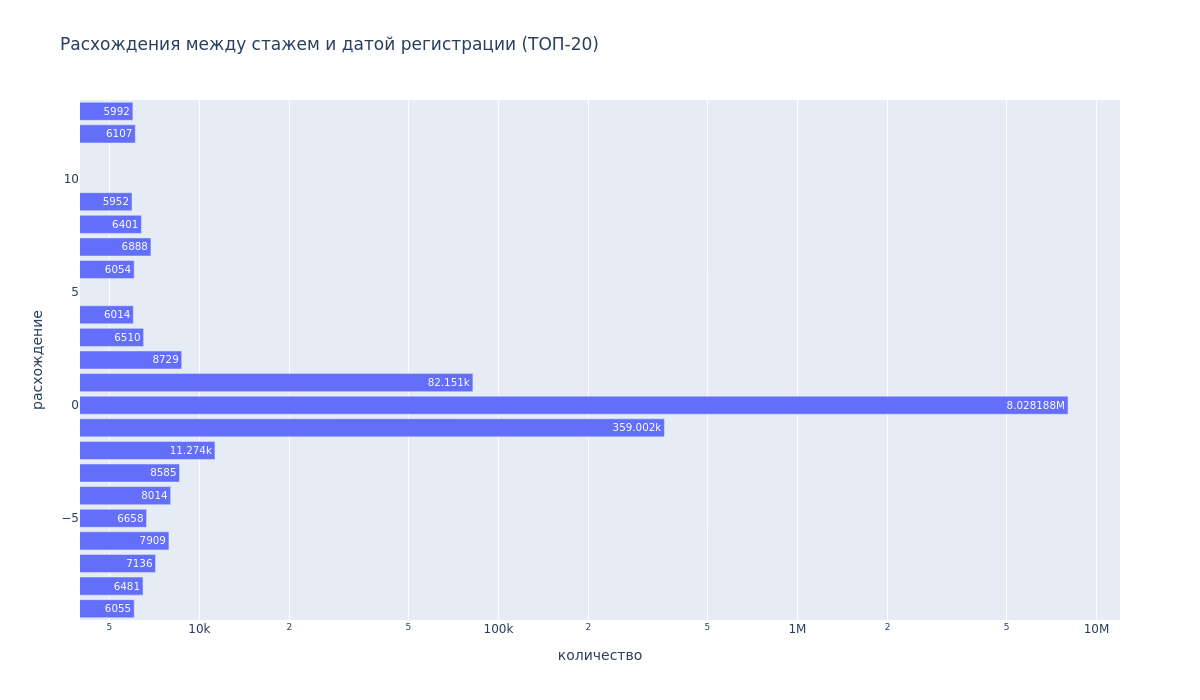

In [77]:
fig = (
    df.loc[df["fecha_dato"] > "2015-08-01", "fecha_dato"] \
        .dt.to_period("M").astype(int) - 
    df.loc[df["fecha_dato"] > "2015-08-01", "fecha_alta"] \
        .dt.to_period("M").astype(int) - 
    df.loc[df["fecha_dato"] > "2015-08-01", "antiguedad"]
).value_counts().head(20).plot(
    kind="barh", text_auto=True,
    title="Расхождения между стажем и датой регистрации (ТОП-20)",
    labels={"value": "количество", "index": "расхождение"})
fig.update_layout(
    height=700, width=1200,
    showlegend=False,
    xaxis_type="log")
fig.write_html(PLOTS_DIR+"antiguedad(1)_fecha_alta.html")
fig.show(renderer="png")

Наиболее часто встречается расхождение - 0 +/- 1 месяц, соответственно для большинства записей дата начала отношений корректна. При этом чаще встречается стаж больше чем расхождение между датами, однако бывают и обратные случаи. Оценим распределение первых и последних значений стажа по каждому клиенту.

In [78]:
pd.DataFrame({
    "first": df.groupby("ncodpers")["antiguedad"].first(),
    "last": df.groupby("ncodpers")["antiguedad"].last()}) \
        .describe(percentiles=PERCENTILES).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
first,949614.00,67.53,1452.88,-999999.00,0.00,0.00,12.00,44.00,123.00,195.00,228.00,250.00
last,949614.00,75.82,1778.82,-999999.00,0.00,6.00,22.00,53.00,133.00,205.00,238.00,256.00


Максимальное количество месяцев у клиента - 256, однако встречаются отрицательные значения. Взглянем на записи клиентов со значениями стажа ниже 0.

In [79]:
clients = df[df["antiguedad"] < 0]["ncodpers"].unique()
print("Записи клиентов (2 первых + 2 последних):")
display(pd.concat([
    df.loc[df["ncodpers"].isin(clients), feats] \
        .groupby("ncodpers").head(2),
    df.loc[df["ncodpers"].isin(clients), feats] \
        .groupby("ncodpers").tail(2)
]).sort_values(["ncodpers", "fecha_dato"]))
print(f"Количество клиентов: {len(clients)}")
print(
    "Уникальные значения стажа:",
    df.loc[df["ncodpers"].isin(clients), "antiguedad"].unique())

Записи клиентов (2 первых + 2 последних):


,fecha_dato,ncodpers,fecha_alta,antiguedad,ind_nuevo,canal_entrada,indrel,indfall,ind_actividad_cliente,indrel_1mes,tiprel_1mes,ult_fec_cli_1t
973903,2015-01-28,138388,1999-07-16,-999999.00,0.00,004,1.00,N,1.00,1,A,NaT
973904,2015-02-28,138388,1999-07-16,-999999.00,0.00,004,1.00,N,1.00,1,A,NaT
973918,2016-04-28,138388,1999-07-16,-999999.00,0.00,004,1.00,N,1.00,1,A,NaT
973919,2016-05-28,138388,1999-07-16,-999999.00,0.00,004,1.00,N,1.00,1,A,NaT
1160337,2015-01-28,162278,2005-06-08,-999999.00,0.00,004,1.00,N,0.00,1.0,A,NaT
1160338,2015-02-28,162278,2005-06-08,-999999.00,0.00,004,1.00,N,0.00,1.0,A,NaT
1160352,2016-04-28,162278,2005-06-08,-999999.00,0.00,004,1.00,N,0.00,1.0,A,NaT
1160353,2016-05-28,162278,2005-06-08,-999999.00,0.00,004,1.00,N,0.00,1.0,A,NaT
5513663,2016-01-28,750561,2016-01-27,0.00,1.00,NaN,1.00,N,1.00,4.0,P,NaT
5513664,2016-02-28,750561,2016-01-27,-999999.00,0.00,RED,1.00,N,1.00,1.0,A,NaT


Количество клиентов: 3
Уникальные значения стажа: [-999999.       0.]


Всего три клиента имеют отрицательные значения, и все значения равны -999999. Только у одного клиента имеется значение 0 в месяц регистрации клиента. По таким клиентам имеются даты регистрации и возможно вычислить стаж клиента. 

Исправим ранее выявленные расхождения, чтобы сравнить оставшиеся значения по стажу и дате начала отношений. Для этого произведем следующие изменения:
- у всех клиентов с 2 датами регистрации, если большая дата начала отношений позже первой даты выгрузки, установим меньшую дату начала отношений;
- у клиентов с 2 датами исправим на ту дату, по которой есть совпадения по стажу;
- у клиентов с 2 датами регистрации но без совпадений устанавливается последняя дата; 

По стажу будем рассматривать 8-й месяц, как более корректный.

In [80]:
# Функция получения разницы в месяцах
def month_diff(
        data: pd.DataFrame,
        start_date: str = "fecha_alta",
        end_date: str = "fecha_dato"
):
    """
    Функция возвращает разницу между датами в месяцах.
    """
    return (data[end_date].dt.to_period("M").astype(int) - 
            data[start_date].dt.to_period("M").astype(int))

# Функция сравнения разницы и стажа
def check_month(
        data: pd.DataFrame,
        start_date: str = "fecha_alta",
        end_date: str = "fecha_dato",
        month_col: str = "antiguedad"
):
    """
    Функция возвращает сравнение результата функции 
    `month_dif` и значения столбца `month_col`.
    """
    result = month_diff(data, start_date, end_date)
    return result == data[month_col]

In [81]:
# Обработка отдельного датасета
cols = ["ncodpers", "fecha_dato", "fecha_alta", "antiguedad"]
clients = df[cols].copy()

In [82]:
def fix_double_dates(
        data: pd.DataFrame,
        start_date: str = "fecha_alta",
        end_date: str = "fecha_dato",
        client_col: str = "ncodpers"
):
    """
    Функция исправляет двойные даты начала отношений:
    1. Если имеется дата позже даты выгрузки - 
    заменяет на меньшую;
    2. Если есть совпадения со стажем - оставляет 
    совпадающие даты;
    3. Если совпадений нет, оставляет последнюю запись
    """
    data = data.copy()
    # Получение клиентов, у которых дата регистрации 
    # больше даты первой выгрузки
    client_ids = data[client_col].map((
        data.groupby(client_col)[end_date].min() + 
        pd.offsets.MonthEnd() -
        data.groupby(client_col)[start_date].max()
    ).dt.days < 0)
    print("Клиентов с датой регистрации > выгрузки:",
        data[client_ids][client_col].nunique())

    # Установка меньшей даты
    if client_ids.sum() > 0:
        data.loc[client_ids, start_date] = data[client_ids] \
            .groupby(client_col)[start_date].transform("min")
        print("Даты исправлены")
    else:
        print("Исправление не выполнено - данные отсутствуют")

    # Получение клиентов с 2 датами регистрации
    client_ids = data[client_col].map(
        data.groupby(client_col)[start_date].nunique() > 1)

    # Удаление клиентов без совпадений
    client_ids = client_ids & data[client_ids] \
        .groupby(client_col)[client_col].transform(
            lambda x: check_month(data[
                data[client_col].isin(x.unique())
            ]).any())
    print()
    print("Клиентов с двойными датами и совпадениями:",
        data.loc[client_ids, client_col].nunique())

    # Установка совпадающей даты
    if client_ids.sum() > 0:
        data.loc[client_ids, start_date] = data.loc[
            client_ids, client_col].map(
                data[client_ids].groupby(client_col).apply(
                    lambda x: next(iter(
                        x.loc[check_month(x), start_date].tail(1)), 
                        np.nan), include_groups=False)).dropna()
        print("Даты исправлены")
    else:
        print("Исправление не выполнено - данные отсутствуют")

    # Получение оставшихся клиентов с 2-мя совпадениями
    client_ids = data[client_col].map(
        data.groupby(client_col)[start_date].nunique() > 1)
    print()
    print("Клиентов с двойными датами:",
        data.loc[client_ids, client_col].nunique())

    # Замена оставшихся значений на последнее
    if client_ids.sum() > 0:
        data.loc[client_ids, start_date] = data[client_ids] \
            .groupby(client_col)[start_date].transform("last")
        print("Даты испралены")
    else:
        print("Исправление не выполнено - данные отсутствуют")
    print()
    print("Осталось клиентов с двойными датами:",
        (data.groupby(client_col)[start_date] \
        .nunique() > 1).sum())
    return data

In [83]:
clients = fix_double_dates(clients)

Клиентов с датой регистрации > выгрузки: 3
Даты исправлены

Клиентов с двойными датами и совпадениями: 13
Даты исправлены

Клиентов с двойными датами: 1
Даты испралены

Осталось клиентов с двойными датами: 0


In [84]:
# Исправление записей стажа меньше 0
client_ids = clients["antiguedad"] < 0
print("Клиентов с отрицательным стажем:",
      clients.loc[client_ids, "ncodpers"].nunique())
if client_ids.sum() > 0:
    clients.loc[client_ids, "antiguedad"] = month_diff(
        clients[client_ids])
    print("Данные исправлены")
else:
    print("Исправление не выполнено - данные отсутствуют")

Клиентов с отрицательным стажем: 3
Данные исправлены


Оценим соответствие стажа и даты регистрации для всех записей датасета после сделанных изменений, разницу посчитаем не более 1 месяца.

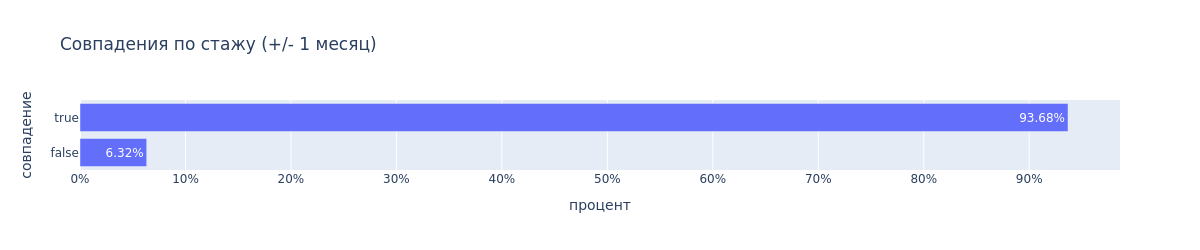

Количество расхождений на клиента:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
check,664673.00,5.76,2.86,1.00,2.00,5.00,5.00,5.00,5.00,14.00,17.00,17.00
fecha_dato,664673.00,5.76,2.86,1.00,2.00,5.00,5.00,5.00,5.00,14.00,17.00,17.00


In [85]:
clients["check"] = abs(month_diff(clients) - clients["antiguedad"]) < 2
fig = clients.loc[clients[
    "fecha_dato"] > pd.to_datetime("2015-08-01"), "check"] \
        .value_counts(normalize=True).plot(
            kind="barh", text_auto=True,
            title="Совпадения по стажу (+/- 1 месяц)",
            labels={"check": "совпадение", "value": "процент"})
fig.update_traces(texttemplate="%{x:.2%}")
fig.update_layout(
    height=250, width=1200, 
    showlegend=False,
    yaxis=dict(autorange="reversed"),
    xaxis_tickformat=".0%")
fig.write_html(PLOTS_DIR+"antiguedad(2).html")
fig.show(renderer="png")

print("Количество расхождений на клиента:")
clients["check"] = ~clients["check"]
clients[clients["check"]].groupby("ncodpers")[["check", "fecha_dato"]] \
    .agg({"check": "sum", "fecha_dato": "count"}) \
        .describe(percentiles=PERCENTILES).T

Записей с расхождениям в стаже и дате регистрации достаточно большое количество - более 6%. Судя по количеству расхождений - они похоже приходятся на все записи клиентов. Вероятнее всего имеются проблемы с расчетом стажа - имеются расхождения более месяца в разные стороны, на первые 7 месяцев приходятся одинаковые значения, также встречаются значения -999999. 

Лучше использовать данные по дате регистрации для рассчета стажа в месяцах после исправления двойных значений.

#### Признак новых отношений

Так как это значение может изменяться с течением времени, оценим соотношение по всем записям.

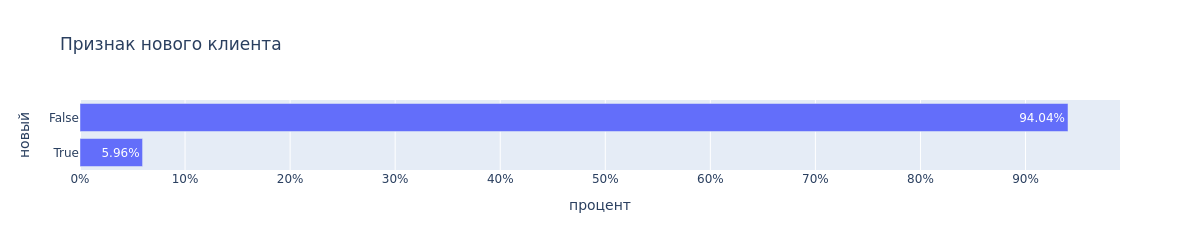

In [86]:
fig = df["ind_nuevo"].value_counts(normalize=True).plot(
    kind="barh", text_auto=True,
    title="Признак нового клиента",
    labels={"ind_nuevo": "новый", "value": "процент"})
fig.update_traces(texttemplate="%{x:.2%}")
fig.update_layout(
    height=250, width=1200, showlegend=False,
    xaxis_tickformat=".0%",
    yaxis=dict(tickvals=[0,1], autorange="reversed",
               ticktext=["False","True"]))
fig.write_html(PLOTS_DIR+"ind_nuevo(1).html")
fig.show(renderer="png")

Большая часть записей в датасете приходится на не новых клиентов. Оценим имеются какой стаж клиента приходится на данный признак.

In [87]:
print(
    "Уникальные значения стажа у новых клиентов:",
    df.loc[(df["ind_nuevo"] == 1), "antiguedad"].unique())

Уникальные значения стажа у новых клиентов: [5. 0. 1. 2. 3. 4. 6.]


Новые клиенты приходятся на значения до 6 месяцев включительно. Для моделей машинного обучения на базе деревьер решений такой признак не нужен, так как модели сами могут определить подходящие значения стажа для целевых значений.

#### Канал прихода

Взглянем на количество уникальных значений канала прихода новых клиентов.

In [88]:
clients = df.groupby("ncodpers")["canal_entrada"] \
    .nunique()
clients.describe(percentiles=PERCENTILES).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
canal_entrada,956645.00,0.98,0.15,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,3.00


В основном у клиентов только один канал прихода, но встречаются менее 1 процента клиентов с большим количеством значений. Взглянем на таких клиентов.

In [89]:
clients = clients.loc[lambda x: x > 1].index
print("Количество клиентов:", len(clients))
df.loc[df["ncodpers"].isin(clients), feats].tail(20)

Количество клиентов: 3704


,fecha_dato,ncodpers,fecha_alta,antiguedad,ind_nuevo,canal_entrada,indrel,indfall,ind_actividad_cliente,indrel_1mes,tiprel_1mes,ult_fec_cli_1t
13631689,2016-03-28,1541272,2016-03-23,0.00,1.00,NaN,1.00,N,1.00,NaN,NaN,NaT
13631690,2016-04-28,1541272,2016-03-23,1.00,1.00,KHM,1.00,N,1.00,1,A,NaT
13631691,2016-05-28,1541272,2016-03-23,15.00,0.00,RED,1.00,N,1.00,1,A,NaT
13631726,2016-03-28,1541290,2016-03-23,0.00,1.00,NaN,1.00,N,1.00,NaN,NaN,NaT
13631727,2016-04-28,1541290,2016-03-23,1.00,1.00,KHM,1.00,N,1.00,1,A,NaT
13631728,2016-05-28,1541290,2016-03-23,15.00,0.00,RED,1.00,N,1.00,1,A,NaT
13631927,2016-04-28,1541377,2016-04-01,1.00,1.00,KHM,1.00,N,1.00,1,A,NaT
13631928,2016-05-28,1541377,2016-04-01,2.00,1.00,KHN,1.00,N,1.00,1,A,NaT
13632854,2016-03-28,1541766,2016-03-28,0.00,1.00,NaN,1.00,N,1.00,NaN,NaN,NaT
13632855,2016-04-28,1541766,2016-03-28,1.00,1.00,KHN,1.00,N,1.00,1,A,NaT


Судя по количеству клиентов и их записям вероятнее всего значения были исправлены после получения точных сведений. Непонятно, могут ли каналы меняться в процессе взаимодействий или это ошибки ввода, возможно все значения лучше исправить на последние сведения. Оценим распределение последних значений.

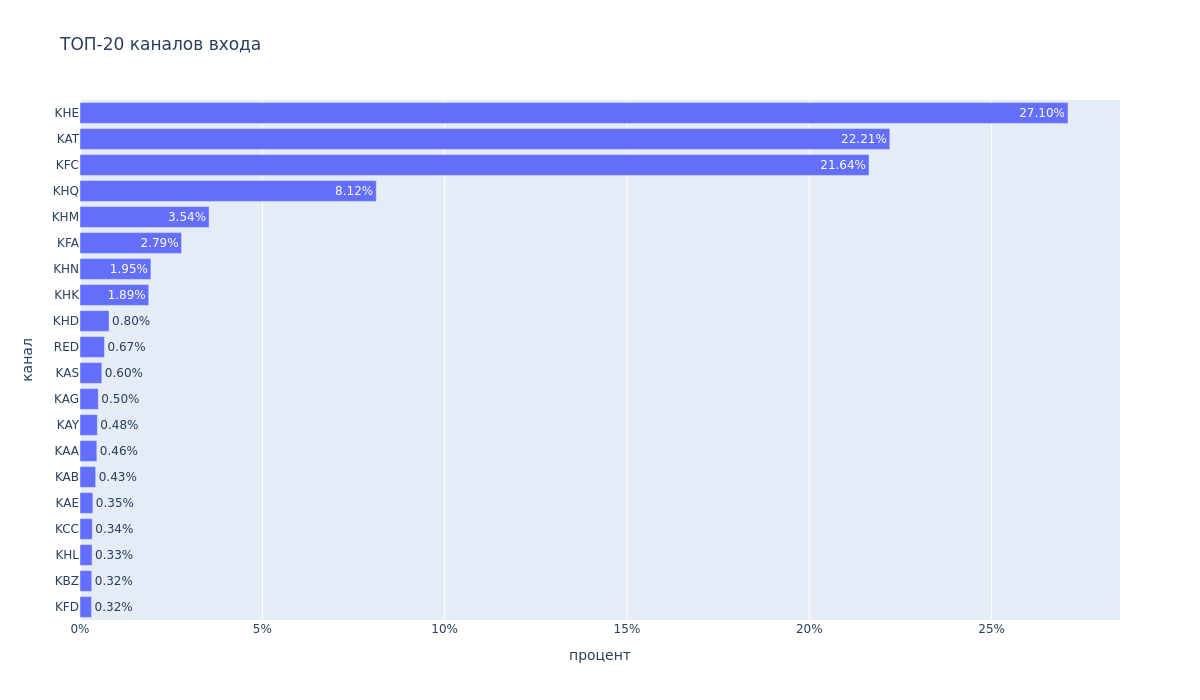

In [90]:
fig = df.groupby("ncodpers")["canal_entrada"].tail(1) \
    .value_counts(normalize=True).head(20).plot(
        kind="barh", text_auto=True,
        title="ТОП-20 каналов входа",
        labels={"canal_entrada": "канал",
                "value": "процент"})
fig.update_traces(texttemplate="%{x:.2%}")
fig.update_layout(
    height=700, width=1200, showlegend=False,
    xaxis_tickformat=".0%",
    yaxis=dict(autorange="reversed",))
fig.write_html(PLOTS_DIR+"canal_entrada(1).html")
fig.show(renderer="png")

Основная масса клиентов приходит через 3 канала, также имеются еще 5 каналов с более высоким количеством клиентов, по остальным каналам приходит менее 1% клиентов, но таких каналов достаточно много. Оценим какой процент клиентов приходится на первую сотню каналов.

In [91]:
for i in [25, 50, 75, 100]:
    print(
        f"Процент клиентов первых {i} каналов: ",
        df.groupby("ncodpers")["canal_entrada"].tail(1) \
            .value_counts(normalize=True).head(i) \
            .mul(100).sum().round(2),
        "%", sep="")

Процент клиентов первых 25 каналов: 96.03%
Процент клиентов первых 50 каналов: 98.83%
Процент клиентов первых 75 каналов: 99.61%
Процент клиентов первых 100 каналов: 99.86%


На первые 25 каналов приходится более 96% датасета. Увеличение до 50 каналов добавляет более 2% от датасета, однако дальнейшее увеличение дает низкий прирост, а оставшиеся категории могут иметь низкую статистическую значимость. Возможно стоит ограничить категории для моделей в пределах первых 50 - 75 каналов, а остальные пометить как other.

#### Тип отношений и актуальность счета

Оценим распределение значений признака, а также количества уникальных значений по клиентам.

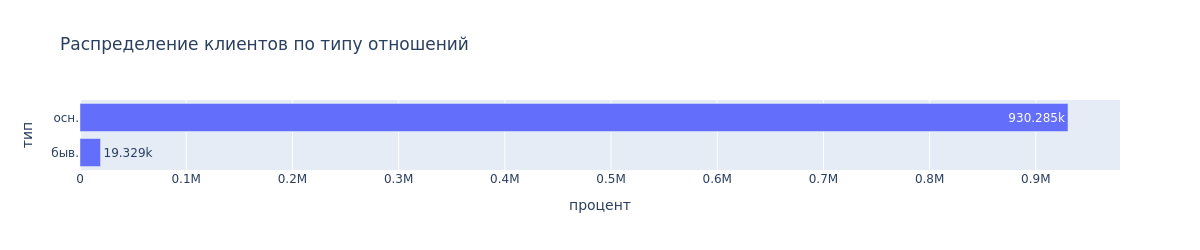

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
indrel,956645.00,1.01,0.15,0.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,2.00


In [92]:
fig = df.groupby("ncodpers")["indrel"].tail(1) \
    .value_counts().plot(
        kind="barh", text_auto=True,
        title="Распределение клиентов по типу отношений",
        labels={"value": "процент", "indrel": "тип"})
fig.update_layout(
    height=250, width=1200, showlegend=False,
    yaxis=dict(
        autorange="reversed",
        tickvals=[1, 99],
        ticktext=["осн.", "быв."]))
fig.write_html(PLOTS_DIR+"indrel(1).html")
fig.show(renderer="png")

df.groupby("ncodpers")["indrel"].nunique() \
    .describe(percentiles=PERCENTILES).to_frame().T

Бывших клиентов чуть больше 19 тысяч. Основное количество клиентов имеют только один тип отношений с банком, но не менее 1% имеют два значения. Данный признак нужно рассматривать с признаком актуальности счета, взглянем на этот признак.

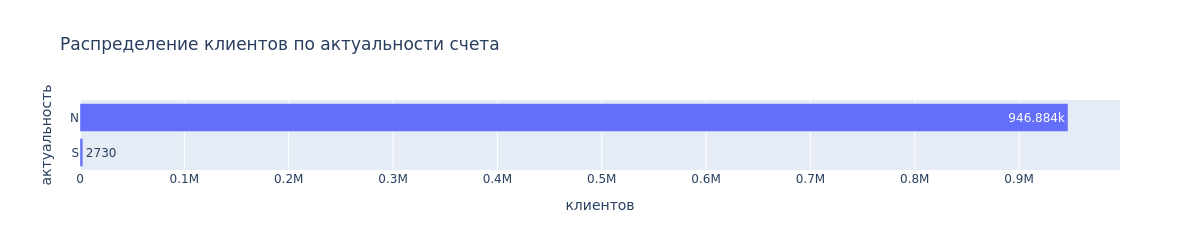

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
indfall,956645.00,0.99,0.09,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00


In [93]:
fig = df.groupby("ncodpers")["indfall"].tail(1) \
    .value_counts().plot(
        kind="barh", text_auto=True,
        title="Распределение клиентов по актуальности счета",
        labels={"value": "клиентов", "indfall": "актуальность"})
fig.update_layout(
    height=250, width=1200, showlegend=False,
    yaxis=dict(autorange="reversed"))
fig.write_html(PLOTS_DIR+"indfall(1).html")
fig.show(renderer="png")

df.groupby("ncodpers")["indfall"].nunique() \
    .describe(percentiles=PERCENTILES).to_frame().T

По признаку актуальности счета имеется существено меньше клиентов - менее 3 тысяч, судя по всему это слабо связанные, либо совсем не связанные признаки. Такое малое количество клиентов скорее всего говорит не об актуальности счета, а о каком-то другом значении признака, судя по описанию Deceased index - вероятнее всего смерти клиента. Взглянем на разброс значений возраста для таких клиентов.

In [94]:
print("Возраст при indfall='S':")
display(df[df["indfall"] == "S"].groupby("ncodpers").tail(1)["age"] \
    .describe(percentiles=PERCENTILES).to_frame().T)
print("Возраст при indfall='N':")
display(df[df["indfall"] == "N"].groupby("ncodpers").tail(1)["age"] \
    .describe(percentiles=PERCENTILES).to_frame().T)
print("Количество клиентов старше 100 лет без признака смерти:",
    df.loc[
        (df["age"] > 100 ) & (df["indfall"] == 'N'), 
        "ncodpers"].nunique())

Возраст при indfall='S':


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,2731.00,77.72,17.15,21.00,39.30,47.00,65.00,81.00,91.00,101.00,107.00,116.00


Возраст при indfall='N':


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,947370.00,40.06,17.07,2.00,20.00,21.00,25.00,38.00,50.00,73.00,88.00,164.00


Количество клиентов старше 100 лет без признака смерти: 848


Минимальное значение для клиентов с признаком 'S' начинается от 21 года, однако основная масса превышает 40 лет а максимальные доходят до 116 лет. Возможно имеются незакрытые счета для ушедших из жизни клиентов. А вот для клиентов с признаком 'N' имеются явные выбросы, так как основная масса не превышает 90 лет, а максимум приходится на 164 года.

Оценим количество уникальных значений у бывших клиентов и неактуальных счетов, а также их совпадения.

In [95]:
print(
    "Уникальные значения актуальности у бывших клиентов:",
    df.loc[df["indrel"] == 99, "indfall"].unique())
print(
    "Уникальные значения типа отношений у неактуальных счетов:",
    df.loc[df["indfall"] == "S", "indrel"].unique())
print(
    "Процент совпадений между признаками: ",
    (df.loc[df["indfall"] == "S", "indrel"] == 99) \
        .mean().round(2) * 100,
    "%", sep="")

Уникальные значения актуальности у бывших клиентов: ['N' 'S']
Уникальные значения типа отношений у неактуальных счетов: [ 1. 99.]
Процент совпадений между признаками: 2.0%


Признаки явно не совпадают, совпадения всего у 2% записей. Проверим, пересечение клиентов у которых по два значения по данным признакам.

In [96]:
rel2 = df.groupby("ncodpers")["indrel"] \
    .nunique().loc[lambda x: x > 1].index.tolist()
print(f"Клиентов с 2 признаками indrel: {len(rel2)}")
fall2 = df.groupby("ncodpers")["indfall"] \
    .nunique().loc[lambda x: x > 1].index.tolist()
print(f"Клиентов с 2 признаками indfall: {len(fall2)}")
print("Пересечений между такими клиентами:",
      len(set(rel2) & set(fall2)))

Клиентов с 2 признаками indrel: 14273
Клиентов с 2 признаками indfall: 487
Пересечений между такими клиентами: 141


Судя по количеству пересечений между такими клиентами - эти признаки пересекаются далеко не всегда. Оценим сколько из таких клиентов имеют положительное значение 'S' в начале и сколько в конце датасета.

In [97]:
print(
    "Значение indfall = 'S' в первой выгрузке:",
    (df[df["ncodpers"].isin(fall2)] \
        .groupby("ncodpers")["indfall"] \
        .head(1) == "S").sum())
print(
    "Значение indfall = 'S' в последней выгрузке:",
    (df[df["ncodpers"].isin(fall2)] \
        .groupby("ncodpers")["indfall"] \
        .tail(1) == "S").sum())

Значение indfall = 'S' в первой выгрузке: 1
Значение indfall = 'S' в последней выгрузке: 486


Такое значение только у одного клиента, взглянем на его выгрузки и для сравнения одного из клиентов со значением "S" в конце. 

In [98]:
client_ids = df.loc[df["ncodpers"].isin(fall2)] \
    .groupby("ncodpers")["indfall"].head(1) == "S"
print("Записи клиента со значением 'S' в начале:")
clients = df.loc[client_ids[client_ids].index, "ncodpers"]
display(df.loc[df["ncodpers"].isin(clients), feats])
print("Записи клиента со значением 'S' в конце:")
clients = df.loc[client_ids[~client_ids].index[0], "ncodpers"]
df.loc[df["ncodpers"] == clients, feats]

Записи клиента со значением 'S' в начале:


,fecha_dato,ncodpers,fecha_alta,antiguedad,ind_nuevo,canal_entrada,indrel,indfall,ind_actividad_cliente,indrel_1mes,tiprel_1mes,ult_fec_cli_1t
1799406,2015-01-28,246319,2001-10-01,166.00,0.00,KFC,1.00,S,1.00,1.0,A,NaT
1799407,2015-02-28,246319,2001-10-01,166.00,0.00,KFC,1.00,S,1.00,1.0,A,NaT
1799408,2015-03-28,246319,2001-10-01,166.00,0.00,KFC,1.00,S,1.00,1.0,A,NaT
1799409,2015-04-28,246319,2001-10-01,166.00,0.00,KFC,1.00,S,1.00,1.0,A,NaT
1799410,2015-05-28,246319,2001-10-01,166.00,0.00,KFC,1.00,S,1.00,1.0,A,NaT
1799411,2015-06-28,246319,2001-10-01,166.00,0.00,KFC,1.00,S,1.00,1.0,A,NaT
1799412,2015-07-28,246319,2001-10-01,166.00,0.00,KFC,1.00,S,1.00,1.0,A,NaT
1799413,2015-08-28,246319,2001-10-01,167.00,0.00,KFC,1.00,S,1.00,1.0,A,NaT
1799414,2015-09-28,246319,2001-10-01,168.00,0.00,KFC,1.00,N,1.00,1.0,A,NaT
1799415,2015-10-28,246319,2001-10-01,169.00,0.00,KFC,1.00,N,1.00,1.0,A,NaT


Записи клиента со значением 'S' в конце:


,fecha_dato,ncodpers,fecha_alta,antiguedad,ind_nuevo,canal_entrada,indrel,indfall,ind_actividad_cliente,indrel_1mes,tiprel_1mes,ult_fec_cli_1t
1300,2015-01-28,15982,1995-01-16,246.00,0.00,KAT,1.00,N,1.00,1,A,NaT
1301,2015-02-28,15982,1995-01-16,246.00,0.00,KAT,1.00,N,1.00,1,A,NaT
1302,2015-03-28,15982,1995-01-16,246.00,0.00,KAT,1.00,N,1.00,1,A,NaT
1303,2015-04-28,15982,1995-01-16,246.00,0.00,KAT,1.00,N,1.00,1,A,NaT
1304,2015-05-28,15982,1995-01-16,246.00,0.00,KAT,1.00,N,1.00,1,A,NaT
1305,2015-06-28,15982,1995-01-16,246.00,0.00,KAT,1.00,N,1.00,1,A,NaT
1306,2015-07-28,15982,1995-01-16,246.00,0.00,KAT,1.00,N,1.00,1,A,NaT
1307,2015-08-28,15982,1995-01-16,247.00,0.00,KAT,1.00,N,1.00,1,A,NaT
1308,2015-09-28,15982,1995-01-16,248.00,0.00,KAT,1.00,N,1.00,1,A,NaT
1309,2015-10-28,15982,1995-01-16,249.00,0.00,KAT,1.00,N,1.00,1,A,NaT


Вероятнее всего здесь также была допущена ошибка, так как клиент основной и он активен, а с 9 месяца 2015 года значения менются на "N". При смене значений на "S" у другого клиента активность не сразу меняется на 0.

Оценим имеются ли клиенты со всеми значениями indfall="S".

In [99]:
print(
    "Количество клиентов имеющих только признак indfall='S':",
    df.loc[
        ~(df["ncodpers"].isin(fall2)) & (df["indfall"] == "S"),
        "ncodpers"].nunique())
del fall2, rel2

Количество клиентов имеющих только признак indfall='S': 2244


#### Активность клиента

Активность клиента скорее всего может меняться ежемесячно. Взглянем на распределение активности по всем событиям.

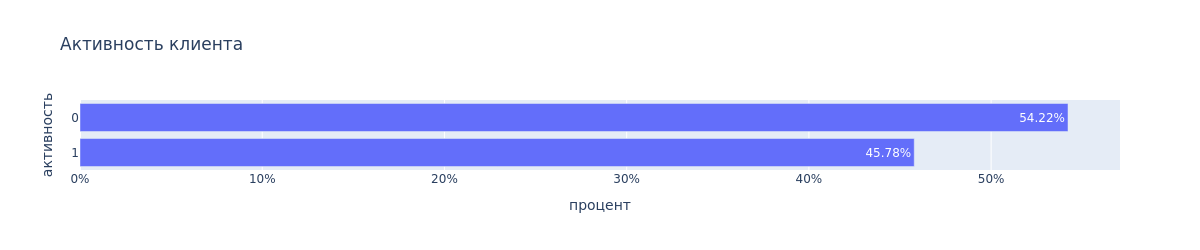

In [100]:
fig = df["ind_actividad_cliente"].value_counts(normalize=True) \
    .plot(
        kind="barh", text_auto=True,
        title="Активность клиента",
        labels={"ind_actividad_cliente": "активность",
                "value": "процент"})
fig.update_traces(texttemplate="%{x:.2%}")
fig.update_layout(
    height=250, width=1200, showlegend=False,
    xaxis_tickformat=".0%",
    yaxis=dict(tickvals=[0,1],
               ticktext=["0", "1"],
               autorange="reversed"))
fig.write_html(PLOTS_DIR+"ind_actividad_cliente(1).html")
fig.show(renderer="png")

Чаще встречаются записи с неактивными клиентами, их порядка 54% от всех записей.

#### Тип отношений и клиента в начале месяца

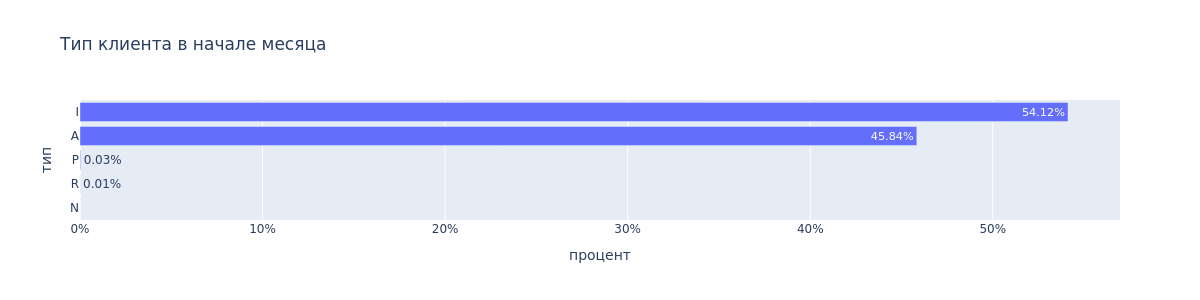

In [101]:
fig = df["tiprel_1mes"].value_counts(normalize=True) \
    .plot(
        kind="barh", text_auto=True,
        title="Тип клиента в начале месяца",
        labels={"tiprel_1mes": "тип",
                "value": "процент"})
fig.update_traces(texttemplate="%{x:.2%}")
fig.update_layout(
    height=300, width=1200, showlegend=False,
    xaxis_tickformat=".0%",
    yaxis=dict(autorange="reversed"))
fig.write_html(PLOTS_DIR+"tiprel_1mes(1).html")
fig.show(renderer="png")

Основная масса записей клиентов приходится на типы `A` - активный и `I` неактивный. Имеется небольшое количество записей с типом `P` - бывший и `R` - потенциальный. Также имеется неизвестный тип `N`, взглянем на записи таких клиентов.

In [102]:
clients = df.loc[df["tiprel_1mes"] == "N", "ncodpers"]
df.loc[df["ncodpers"].isin(clients), feats]

,fecha_dato,ncodpers,fecha_alta,antiguedad,ind_nuevo,canal_entrada,indrel,indfall,ind_actividad_cliente,indrel_1mes,tiprel_1mes,ult_fec_cli_1t
13210371,2015-10-28,1465879,2015-10-02,0.00,1.00,NaN,1.00,N,1.00,P,N,NaT
13210372,2015-11-28,1465879,2015-10-02,1.00,1.00,KHM,1.00,N,1.00,1,A,NaT
13210373,2015-12-28,1465879,2015-10-02,3.00,1.00,KHM,1.00,N,1.00,1,A,NaT
13210374,2016-01-28,1465879,2015-10-02,3.00,1.00,KHM,1.00,N,1.00,1,A,NaT
13210375,2016-02-28,1465879,2015-10-02,5.00,1.00,KHM,1.00,N,1.00,1,A,NaT
13210376,2016-03-28,1465879,2015-10-02,5.00,1.00,KHM,99.00,N,0.00,1,A,2016-03-22
13596451,2016-02-28,1528222,2016-02-02,0.00,1.00,NaN,1.00,N,1.00,P,N,NaT
13596452,2016-03-28,1528222,2016-02-02,1.00,1.00,KFC,1.00,N,1.00,1,A,NaT
13596453,2016-04-28,1528222,2016-02-02,2.00,1.00,KFC,1.00,N,1.00,1,A,NaT
13596454,2016-05-28,1528222,2016-02-02,3.00,1.00,KFC,1.00,N,1.00,1,A,NaT


Имеются несколько таких клиентов, причем значение N приходится на первые записи, где значение indrel_1mes равно `P`. Можно также отметить, что признак активного клиента и его активности могут не совпадать, в частности значение `I` может появляться с отставанием на месяц. Также потенциальный клиент присустствует в двух признаках. Оценим их соответствие.

In [103]:
print("Уникальные значения потенциальных клиентов:")
display(df.loc[df["indrel_1mes"] == "P", "tiprel_1mes"].value_counts())
print("Всего значений tiprel_1mes=`R`:",
      len(df[df["tiprel_1mes"] == "R"]))

Уникальные значения потенциальных клиентов:


tiprel_1mes
R    870
N      4
Name: count, dtype: int64

Всего значений tiprel_1mes=`R`: 870


Все потенциальные клиенты соответствуют значению `R` или `N`, соответственно эти признаки идентичны. Оценим записи для значения `P` признака `tiprel_1mes`.

In [104]:
df.loc[df["tiprel_1mes"] == "P", "indrel_1mes"].value_counts()

indrel_1mes
3.0    2780
3      1570
4.0     223
4        83
Name: count, dtype: int64

По признаку P все записи приходятся на тип клиента 3 или 4 - признаки, что клиент ранее был премиальным или собственником. Оценим обратное соответствие, для этого все значения признака `indrel_1mes` приведем к числовым заменив `P` на 0 и приведения к целочисленному значению.

In [105]:
# не трогаем основной датасет
clients = df[["tiprel_1mes", "indrel_1mes"]].copy()
# приведение к числовому формату
clients.loc[clients["indrel_1mes"] == "P", "indrel_1mes"] = 0
clients["indrel_1mes"] = pd.to_numeric(clients["indrel_1mes"])

client_ids = clients["indrel_1mes"] > 2
clients.loc[client_ids, "tiprel_1mes"].value_counts()

tiprel_1mes
P    4656
Name: count, dtype: int64

Видим полное соответствие между значением `P` - бывший клиент по признаку `tiprel_1mes` и значениями 3 / 4 признака `indrel_1mes`. Также сравним значения `A` и `I` - активный или неактивный с признаком активности клиента. 

In [106]:
clients["activity"] = df["ind_actividad_cliente"]
print("Процент активности по признакам:")
clients[clients["tiprel_1mes"].isin(["A", "I"])].groupby("tiprel_1mes")["activity"].mean().mul(100)

Процент активности по признакам:


tiprel_1mes
A   90.03
I    8.54
Name: activity, dtype: float64

Порядка 90% значений `A` признака приходятся на активные записи, а на неактивные чуть больше 8%. Ранее уже было отмечено, что изменение признака может отставать от активности. Судя по всему признак `tiprel_1mes` дублирует признак `indrel_1mes` и признак активности, причем по активности идет с запозданием, необходимо в дальнейшем сравнить признак активности с целевыми. 

В части типа клиента на начало месяца `indrel_1mes` имеются данные по активности клиента, которые предоставляют сведения за предыдущий месяц, а остальные значения дублируют признак вида отношений с клиентом `tiprel_1mes`. Можно упростить признаки путем их разделения на 3 признака, 2 из которых будут бинарными: 
- признак бывшего клиента, если `indrel_1mes` равен `P` (бывший);
- признак активности в прошлом месяце, если `indrel_1mes` равен `A`;
- по признаку `indrel_1mes` оставить только первые 3 категории как результат целочисленного деления значений на 2 и в последующем кодировать посредством OneHotEncoder;

Оценим распределение значений вида отношений в начале месяца.

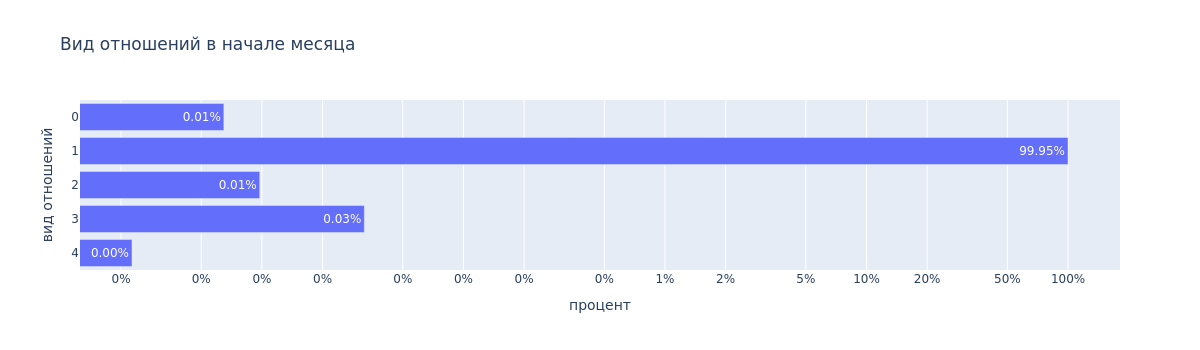

In [107]:
fig = clients["indrel_1mes"].value_counts(normalize=True) \
    .plot(
        kind="barh", text_auto=True,
        title="Вид отношений в начале месяца",
        labels={"indrel_1mes": "вид отношений",
                "value": "процент"})
fig.update_traces(texttemplate="%{x:.2%}")
fig.update_layout(
    height=350, width=1200, showlegend=False,
    xaxis_tickformat=".0%",
    xaxis_type="log",
    yaxis=dict(autorange="reversed"))
fig.write_html(PLOTS_DIR+"indrel_1mes(1).html")
fig.show(renderer="png")

По видам отношений клиента также интересует средние доходы клиентов и их разброс. Для оценки возьмем последние записи по клиентам.

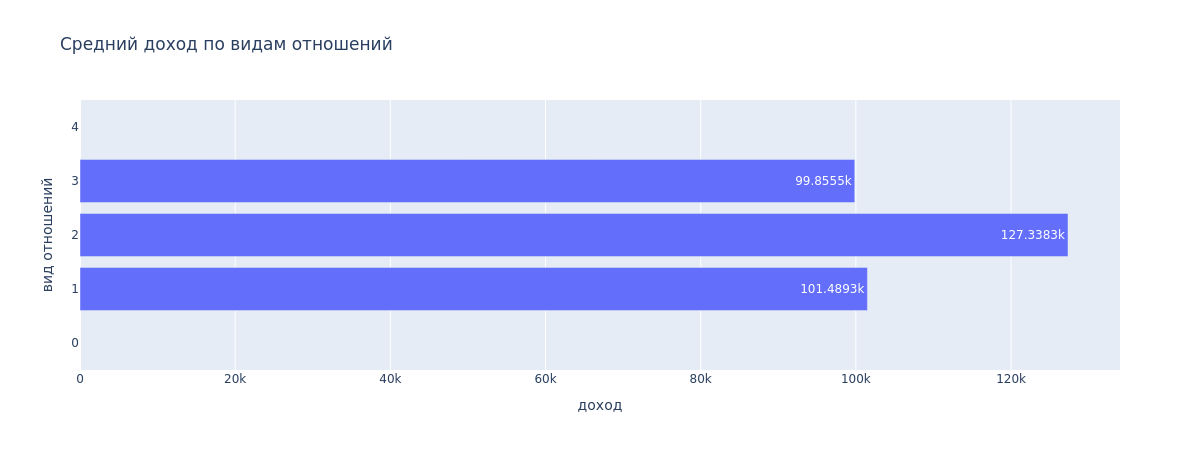

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
indrel_1mes,,,,,,,,,,,,
0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1.00,709275.00,134100.08,232301.61,1202.73,26353.63,40030.40,68489.80,101489.34,155528.57,309966.93,555605.55,28894395.51
2.00,4.00,146660.98,71265.26,90211.92,90317.24,90738.51,92844.89,127338.30,181154.39,229635.19,239331.35,241755.39
3.00,45.00,124934.24,80350.27,32604.81,36552.09,45848.84,70754.55,99855.54,155223.45,299606.92,377245.63,391066.65
4.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [108]:
clients["ncodpers"] = df["ncodpers"]
clients["renta"] = df["renta"]
fig = clients.groupby("ncodpers").tail(1) \
    .groupby("indrel_1mes")["renta"].median().plot(
        kind="barh", text_auto=True,
        title="Средний доход по видам отношений",
        labels={"indrel_1mes": "вид отношений",
                "value": "доход"})
fig.update_layout(height=450, width=1200, showlegend=False)
fig.write_html(PLOTS_DIR+"indrel_1mes(2)_renta.html")
fig.show(renderer="png")
clients.groupby("ncodpers").tail(1) \
    .groupby("indrel_1mes")["renta"] \
    .describe(percentiles=PERCENTILES)
    

#### Последняя дата премиального

По данному признаку было много пропусков, также имелись клиенты с несколькими значениями. Оценим количество пропусков в записях.

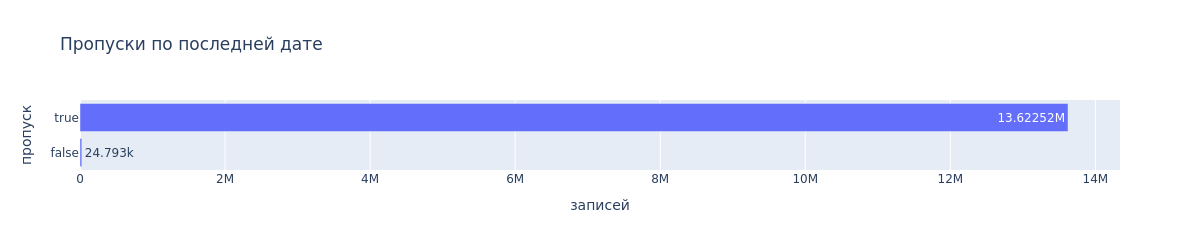

Клиентов с записями: 19889


In [109]:
fig = df["ult_fec_cli_1t"].isna().value_counts().plot(
    kind="barh", text_auto=True,
    title="Пропуски по последней дате",
    labels={"ult_fec_cli_1t": "пропуск",
            "value": "записей"})
fig.update_layout(
    height=250, width=1200, showlegend=False,
    yaxis=dict(autorange="reversed"))
fig.write_html(PLOTS_DIR+"ult_fec_cli_1t(1).html")
fig.show(renderer="png")
print("Клиентов с записями:",
      df.loc[df["ult_fec_cli_1t"].notna(), "ncodpers"].nunique())

Значения без пропусков имеются у почти 20 тысяч клиентов, причем записей без пропусков всего чуть больше 24 тысяч, соответственно значения приходятся не на все записи, а на отдельные. Взглянем на такие записи.

In [110]:
df.loc[df["ult_fec_cli_1t"].notna(), feats].head(20)

,fecha_dato,ncodpers,fecha_alta,antiguedad,ind_nuevo,canal_entrada,indrel,indfall,ind_actividad_cliente,indrel_1mes,tiprel_1mes,ult_fec_cli_1t
35,2015-08-28,15891,2015-07-28,246.00,0.00,KAT,99.00,N,0.00,1,A,2015-08-05
2941,2016-03-28,16136,1995-02-24,252.00,0.00,KAT,99.00,N,0.00,1,A,2016-03-17
2956,2016-03-28,16137,1999-05-18,252.00,0.00,KAT,99.00,N,1.00,1,A,2016-03-17
4091,2015-12-28,16254,1995-03-14,9.00,0.00,KHK,99.00,N,0.00,1.0,I,2015-12-04
4445,2016-03-28,16283,2009-04-29,252.00,0.00,KAT,99.00,N,0.00,1.0,I,2016-03-29
8083,2015-01-28,16817,1995-05-05,242.00,0.00,KAT,99.00,N,0.00,1.0,A,2015-07-15
8084,2015-02-28,16817,1995-05-05,242.00,0.00,KAT,99.00,N,0.00,1.0,A,2015-07-15
8085,2015-03-28,16817,1995-05-05,242.00,0.00,KAT,99.00,N,0.00,1.0,A,2015-07-15
8086,2015-04-28,16817,1995-05-05,242.00,0.00,KAT,99.00,N,0.00,1.0,A,2015-07-15
8087,2015-05-28,16817,1995-05-05,242.00,0.00,KAT,99.00,N,0.00,1.0,A,2015-07-15


Можно заметить, что имеются записи за предыдущие месяцы, где значение признака позже даты выгрузки, причем клиент не новый и отмечен как активный на начало месяца, однако клиент отмечен как бывший - 99. Также можно отметить возможность соответствия со значением 99 признака `indrel`, оценим на все ли значения приходятся такие совпадения.

In [111]:
display(df.loc[df["ult_fec_cli_1t"].notna(), "indrel"] \
        .value_counts())
print("Всего значений 99:", len(df[df["indrel"] == 99]))

indrel
99.00    24793
Name: count, dtype: int64

Всего значений 99: 24793


Значение 99 признака отношений с банком от и наличие даты `ult_fec_cli_1t` полностью совпадают, вероятно признак `indrel` рассчетный на основании наличия последней даты клиента. Однако имеются ошибки, признак должен быть отмечен только если последняя дата соответствует месяцу выгрузки. Проверим количество записей, у которых дата выгрузки раньше последней даты, а также оценим количество записей, отличается от последней даты более чем на 31 день.


In [112]:
print("Записей раньше последней даты:", 
      ((df["fecha_dato"] + pd.offsets.MonthEnd(0)) <= 
       df["ult_fec_cli_1t"]).sum())
print("Записей в следующем месяце:",
      df[["fecha_dato", "ult_fec_cli_1t"]].dropna().apply(
          lambda x: (x["fecha_dato"] - x["ult_fec_cli_1t"]).days,
          axis=1).loc[lambda x: x > 31].shape[0])
      

Записей раньше последней даты: 4721
Записей в следующем месяце: 0


Имеется менее 5 тысяч записей по клиентам, у которых последняя дата раньше месяца выгрузки. Записи позже месяца последней даты отсутствуют.

Оценим в какие месяцы клиенты уходили чаще всего.

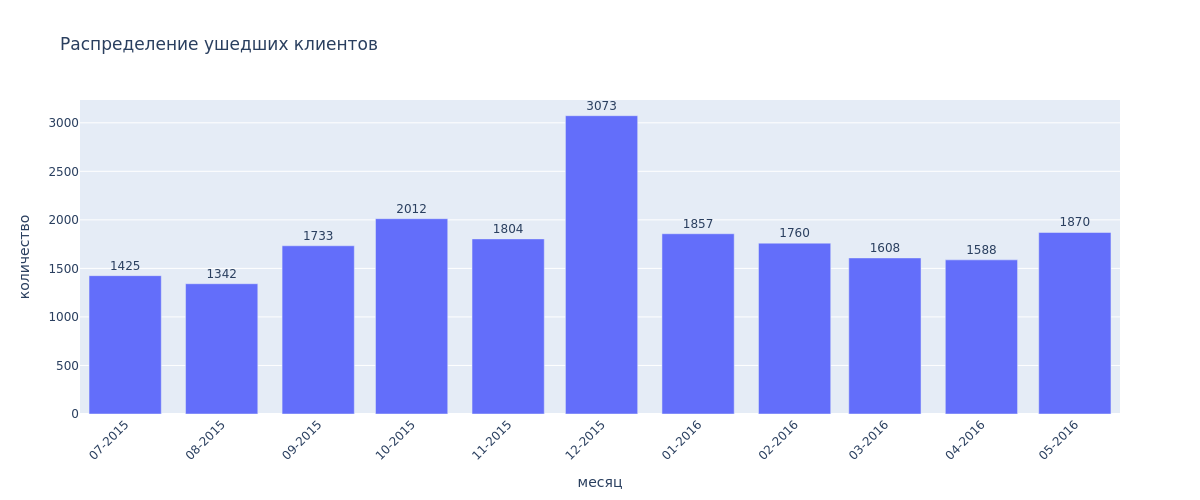

In [113]:
fig = df[["ncodpers", "ult_fec_cli_1t"]] \
    .drop_duplicates()["ult_fec_cli_1t"] \
    .dropna().dt.to_period("M") \
    .astype(str).value_counts().sort_index().plot(
        kind="bar", text_auto=True,
        title="Распределение ушедших клиентов",
        labels={"ult_fec_cli_1t": "месяц", 
                "value": "количество"})
fig.update_layout(
    height=500, width=1200, showlegend=False)
fig.update_xaxes(
    tickformat="%m-%Y",
    tickangle=-45, 
    dtick="M1")
fig.update_traces(textposition="outside")
fig.write_html(PLOTS_DIR+"ult_fec_cli_1t(2).html")
fig.show(renderer="png")

В среднем уходит порядка 1300-2000 клиентов, однако в декабре 2015 года ушло существенно больше клиентов. Взглянем на ТОП-5 дат ухода клиентов.

In [114]:
df[["ncodpers", "ult_fec_cli_1t"]].dropna() \
    .drop_duplicates()["ult_fec_cli_1t"] \
    .value_counts().head(15)

ult_fec_cli_1t
2015-12-24    763
2015-12-28    521
2015-12-21    206
2015-12-17    172
2016-01-19    169
2016-01-05    167
2015-12-16    158
2015-12-18    139
2016-04-01    132
2015-10-26    131
2016-02-15    129
2015-10-05    129
2016-05-26    128
2016-05-02    128
2015-11-02    128
Name: count, dtype: int64

Декабрь очень сильно выбивается, если для других месяцев в день уходит не блее 170 клиентов, то в декабре за 3 дня ушло почти 1.5 тысячи клиентов. Возможно в конце года клиенты принимают решение о том, чтобы прекратить отношения с банком.

#### Промежуточные выводы

Проведен анализ признаков взаимоотношения с банком, по результатам 
которого можно сделать следующие выводы:

1. Имеются расхождения стажа клиента и даты начала отношений, 
при этом имеющиеся проблемы с датами - двойные значения можно 
исправить ориентируясь на имеющийся стаж клиента, а в случае 
отсутствия совпадений - исправить на последнее или наименьшее 
значение.
2. Признак новых отношений зависит от стажа клиента и может быть 
малоинформативным, так как современные модели машинного обучения, 
основанные на деревьях решений могут самостоятельно определить 
наиболее актуальные пороги значений стажа.
3. Имеются расхождения в канале прихода, не совсем понятно как 
данные сведения собираются и могут ли они менятся со временем.
4. Тип отношений полностью соответствует наличию последней даты 
взаимодействия, однако имеются расхождения - наличие последней 
даты взаимодействия в выгрузках с ранней датой.
5. Признак `indfall` судя по всему является признаком смерти 
клиента, при этом в датасете более 2 тысяч клиентов отмечены 
данным признаком, в том числе имеющие большой возраст, для таких 
клиентов возраст не является выбросом.
6. Активность клиента нужно оценить по целевым признакам.
7. По данным о типе клиента и виде отношений на начало месяца имеет 
смысл значения признака `indrel_1mes` сократить до - основной и 
совладелец (значения 1 и 2), так как признаки потенциального и 
бывшего клиента уже имеются в признаке `tiprel_1mes` и привносят 
избыточность в датасет.

**Предпринятые меры**
- Подготовлена функция для исправления дублирующихся дат начала 
взаимоотношений с клиентом - `fix_double_dates`;
- Подготовлена функция для расчета стажа - `month_diff`.

### Банковские продукты

Банковские продукты являются целевыми признаками, 
которые занимают с 25 по 48 колонки:

- `ind_ahor_fin_ult1` - Сберегательный счёт
- `ind_aval_fin_ult1` - Банковская гарантия
- `ind_cco_fin_ult1` - Текущие счета
- `ind_cder_fin_ult1` - Деривативный счёт
- `ind_cno_fin_ult1` - Зарплатный проект
- `ind_ctju_fin_ult1` - Детский счёт
- `ind_ctma_fin_ult1` - Особый счёт 3
- `ind_ctop_fin_ult1` - Особый счёт
- `ind_ctpp_fin_ult1` - Особый счёт 2
- `ind_deco_fin_ult1` - Краткосрочный депозит
- `ind_deme_fin_ult1` - Среднесрочный депозит
- `ind_dela_fin_ult1` - Долгосрочный депозит
- `ind_ecue_fin_ult1` - Цифровой счёт
- `ind_fond_fin_ult1` - Денежный средства
- `ind_hip_fin_ult1` - Ипотека
- `ind_plan_fin_ult1` - Пенсионный план
- `ind_pres_fin_ult1` - Кредит
- `ind_reca_fin_ult1` - Налоговый счёт
- `ind_tjcr_fin_ult1` - Кредитная карта
- `ind_valo_fin_ult1` - Ценные бумаги
- `ind_viv_fin_ult1` - Домашний счёт
- `ind_nomina_ult1` - Аккаунт для выплаты зарплаты
- `ind_nom_pens_ult1` - Аккаунт для пенсионных обязательств
- `ind_recibo_ult1` - Дебетовый аккаунт

#### Обзор признаков

In [115]:
feats = (["fecha_dato", "ncodpers"] + 
    [col for col in df.columns if col.endswith("ult1")])

df[feats].tail(15)

,fecha_dato,ncodpers,ind_ahor_fin_ult1,ind_aval_fin_ult1,ind_cco_fin_ult1,ind_cder_fin_ult1,ind_cno_fin_ult1,ind_ctju_fin_ult1,ind_ctma_fin_ult1,ind_ctop_fin_ult1,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
13647294,2016-05-28,1553672,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.00,0.00,0
13647295,2016-05-28,1553673,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.00,0.00,0
13647296,2016-05-28,1553675,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.00,0.00,0
13647297,2016-05-28,1553676,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.00,0.00,0
13647298,2016-05-28,1553677,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.00,0.00,0
13647299,2016-05-28,1553679,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.00,0.00,0
13647300,2016-05-28,1553680,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.00,0.00,0
13647301,2016-05-28,1553681,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.00,0.00,0
13647302,2016-05-28,1553683,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.00,0.00,0
13647303,2016-05-28,1553684,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.00,0.00,0


Оценим уникальные значения признаков

In [116]:
for col in feats[2:]:
    print(col, df[col].unique())

ind_ahor_fin_ult1 [0 1]
ind_aval_fin_ult1 [0 1]
ind_cco_fin_ult1 [1 0]
ind_cder_fin_ult1 [0 1]
ind_cno_fin_ult1 [0 1]
ind_ctju_fin_ult1 [0 1]
ind_ctma_fin_ult1 [0 1]
ind_ctop_fin_ult1 [0 1]
ind_ctpp_fin_ult1 [1 0]
ind_deco_fin_ult1 [0 1]
ind_deme_fin_ult1 [0 1]
ind_dela_fin_ult1 [0 1]
ind_ecue_fin_ult1 [0 1]
ind_fond_fin_ult1 [0 1]
ind_hip_fin_ult1 [0 1]
ind_plan_fin_ult1 [0 1]
ind_pres_fin_ult1 [0 1]
ind_reca_fin_ult1 [0 1]
ind_tjcr_fin_ult1 [1 0]
ind_valo_fin_ult1 [1 0]
ind_viv_fin_ult1 [0 1]
ind_nomina_ult1 [ 0.  1. nan]
ind_nom_pens_ult1 [ 0.  1. nan]
ind_recibo_ult1 [0 1]


По всем целевым признакам только 2 значения, кроме признаков `ind_nomina_ult1` и `ind_nom_pens_ult1` которые содержат пропуски. Оценим количество пропусков.

In [117]:
df[feats[-3: -1]].isna().sum()

ind_nomina_ult1      16063
ind_nom_pens_ult1    16063
dtype: int64

Пропусков одинаковое количество, скорее всего они приходятся на одни и те же записи. Оценим по каким еще столбцам имеются пропуски.

In [118]:
df.loc[df[feats[-3]].isna() & df[feats[-2]].isna()].isna().sum() \
    .loc[lambda x: x > 0]

ind_empleado             15846
pais_residencia          15846
sexo                     15430
age                      15846
fecha_alta               15846
ind_nuevo                15846
antiguedad               15846
indrel                   15846
ult_fec_cli_1t           16062
indrel_1mes              15846
tiprel_1mes              15846
indresi                  15846
indext                   15846
conyuemp                 16061
canal_entrada            15911
indfall                  15846
tipodom                  15846
cod_prov                 15846
nomprov                  15846
ind_actividad_cliente    15846
renta                    15886
segmento                 15926
ind_nomina_ult1          16063
ind_nom_pens_ult1        16063
dtype: int64

Все пропуски по целевому признаку совпадают, однако имеются пропуски и по большинству других столбцов, однако таких пропусков немного меньше для большинства признаков - 15846. Возможно пропуски приходятся также и на первые записи новых клиентов. Получим целевые признаки только для тех записей, у которых указана дата начала взаимоотношений, так как у нас были записи без таких значений, которые будут удалены перед подготовкой датасета. Все пропуски в целевых признаках заполним значением 0 для дальнейшего анализа.

In [119]:
target = df.loc[df["fecha_alta"].notna(), feats].copy()
target = target.fillna(0)
target[feats[2:]] = target[feats[2:]].astype(bool)

with open("products.yaml", "r") as fd:
    prods = yaml.safe_load(fd)

#### Самые популярные 

Оценим продукты по популярности.

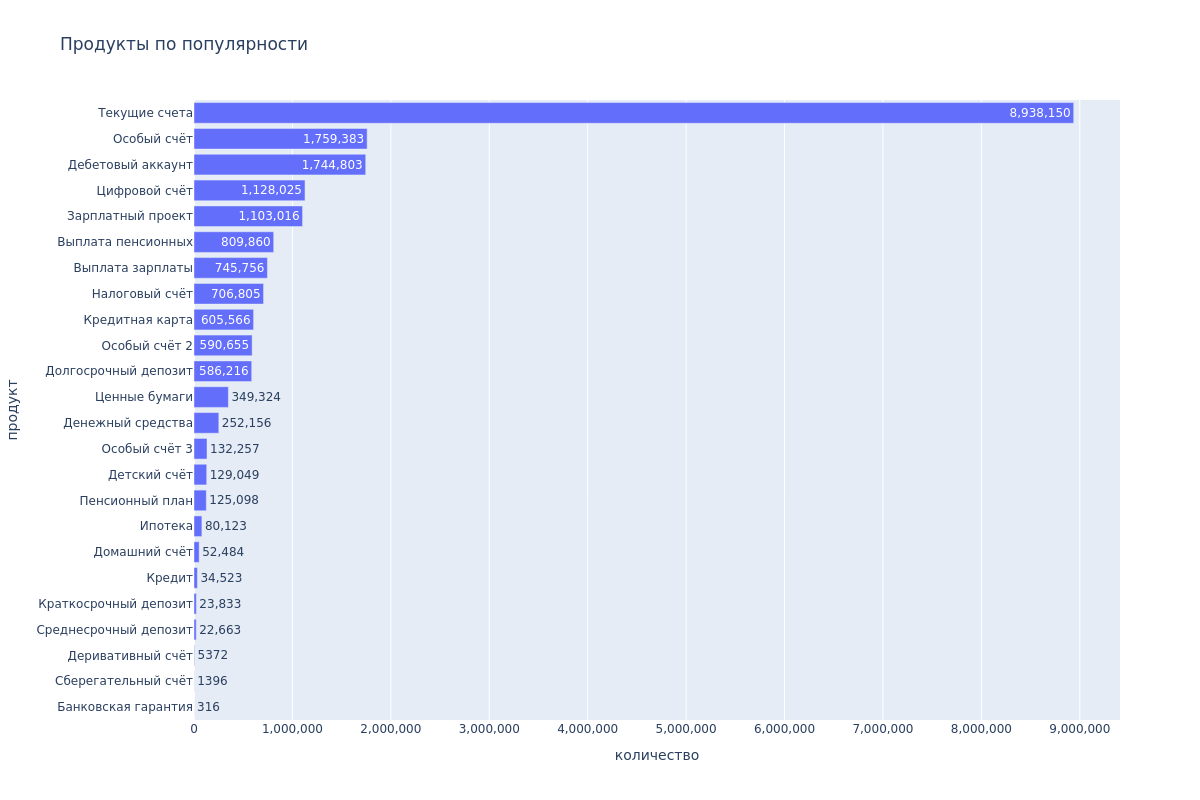

In [120]:
fig = target[feats[2:]].rename(columns=prods) \
        .sum().sort_values().plot(
        kind="barh", text_auto=True,
        title="Продукты по популярности",
        labels={"index": "продукт", "value": "количество"})
fig.update_layout(
    height=800, width=1200, showlegend=False,
    xaxis=dict(exponentformat="none"))
fig.write_html(PLOTS_DIR+"target(1).html")
fig.show(renderer="png")

Самым популярным является продукт "Текущие счета", который существенно вырывается по количеству использований. Далее довольно близко по количеству расположились продукты "Особый счет" и "Дебетовый аккаунт". Последними в ТОП-5 входят продукты "Цифровой счет" и "Зарплатный проект".

#### Популярность продуктов по возрасту

Взглянем на ТОП-5 продуктов в зависимости от возраста.

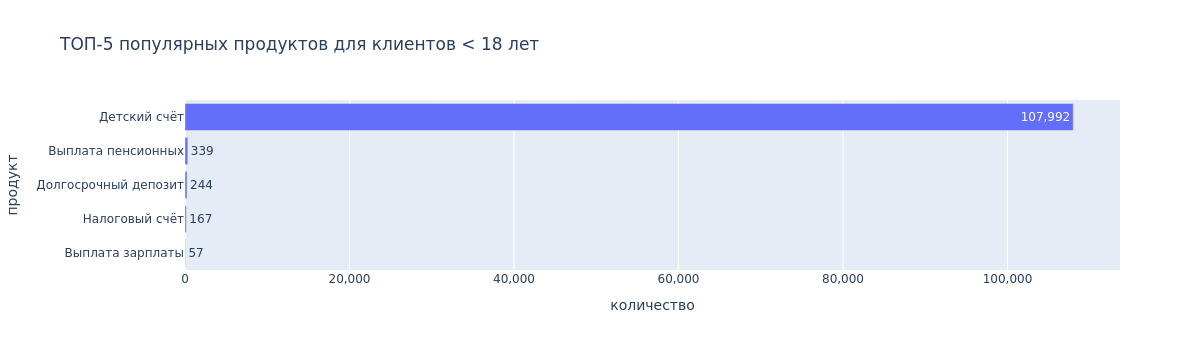

In [121]:
client_ids = df.loc[df["fecha_alta"].notna(), "age"]
fig = target.loc[client_ids < 18, feats[2:]].rename(columns=prods) \
    .sum().sort_values().tail(5).plot(
        kind="barh", text_auto=True,
        title="ТОП-5 популярных продуктов для клиентов < 18 лет",
        labels={"index": "продукт", "value": "количество"})
fig.update_layout(
    height=350, width=1200, showlegend=False,
    xaxis=dict(exponentformat="none"))
fig.write_html(PLOTS_DIR+"target(2)_age.html")
fig.show(renderer="png")

Для клиентов моложе 18 лет самым популярным является "Детский счет", причем такой продукт практически единственный. Судя по всему имеются несовершеннолетние клиенты, однако встречаются и другие продукты, например "Выплата пенсионных", вероятно имеются клиенты с ошибками по возрасту до 18 лет, однако таких клиентов совсем мало. Оценим следующую группу от 18 до 30 лет.

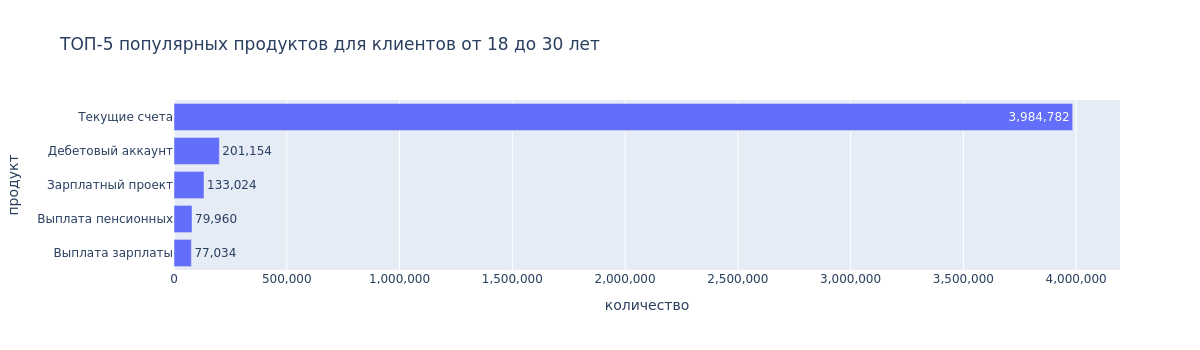

In [122]:
fig = target.loc[
    (client_ids >= 18) & (client_ids < 30), feats[2:]].rename(columns=prods) \
    .sum().sort_values().tail(5).plot(
        kind="barh", text_auto=True,
        title="ТОП-5 популярных продуктов для клиентов от 18 до 30 лет",
        labels={"index": "продукт", "value": "количество"})
fig.update_layout(
    height=350, width=1200, showlegend=False,
    xaxis=dict(exponentformat="none"))
fig.write_html(PLOTS_DIR+"target(3)_age.html")
fig.show(renderer="png")

По клиентам в возрасте от 18 до 30 лет наиболее популярным становятся текущие счета, как и для всего датасета, однако из ТОП-5 пропадают продукты "Особый счет" и "Цифровой счет". Взглянем на клиентов от 30 до 65 лет.

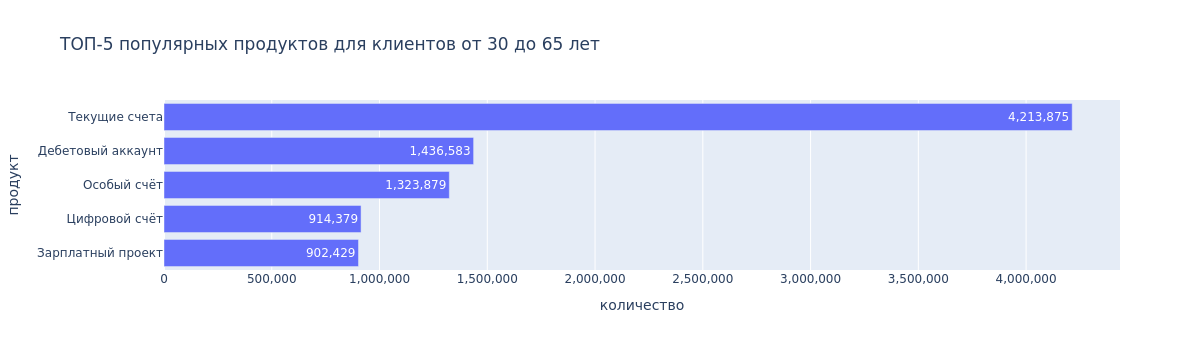

In [123]:
fig = target.loc[
    (client_ids >= 30) & (client_ids < 65), feats[2:]].rename(columns=prods) \
    .sum().sort_values().tail(5).plot(
        kind="barh", text_auto=True,
        title="ТОП-5 популярных продуктов для клиентов от 30 до 65 лет",
        labels={"index": "продукт", "value": "количество"})
fig.update_layout(
    height=350, width=1200, showlegend=False,
    xaxis=dict(exponentformat="none"))
fig.write_html(PLOTS_DIR+"target(4)_age.html")
fig.show(renderer="png")

У таких клиентов в ТОП-5 поднимаются продукты "Особый счет" и "Цифровой счет". Взглянем на клиентов от 65 до 100 лет.

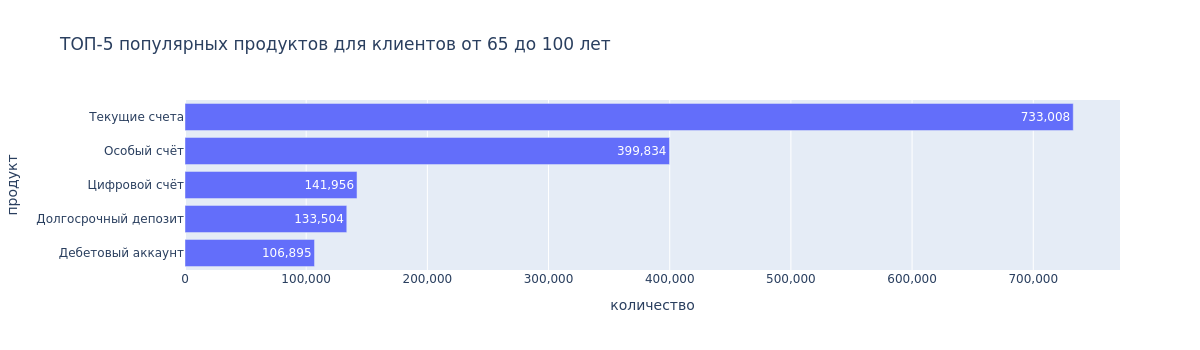

In [124]:
fig = target.loc[
    (client_ids >= 65) & (client_ids < 100), feats[2:]].rename(columns=prods) \
    .sum().sort_values().tail(5).plot(
        kind="barh", text_auto=True,
        title="ТОП-5 популярных продуктов для клиентов от 65 до 100 лет",
        labels={"index": "продукт", "value": "количество"})
fig.update_layout(
    height=350, width=1200, showlegend=False,
    xaxis=dict(exponentformat="none"))
fig.write_html(PLOTS_DIR+"target(5)_age.html")
fig.show(renderer="png")

Для клиентов старше 65 лет возрастает количество операций по продукту "Особый счет", также в ТОП-5 появляется продукт "Долгосрочный депозит", а "Дебетовый аккаунт" спускается на последнюю строчку. Оценим клиентов с самым большим значением возраста.

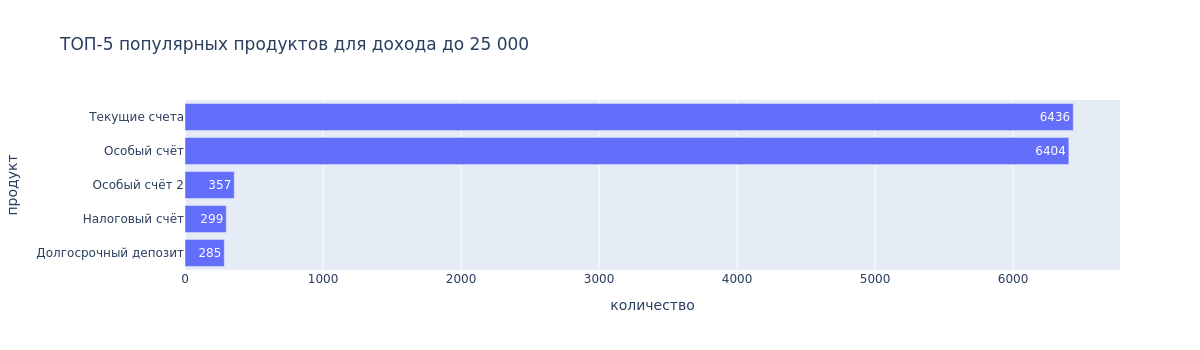

In [125]:
fig = target.loc[client_ids >= 100, feats[2:]].rename(columns=prods) \
    .sum().sort_values().tail(5).plot(
        kind="barh", text_auto=True,
        title="ТОП-5 популярных продуктов для дохода до 25 000",
        labels={"index": "продукт", "value": "количество"})
fig.update_layout(
    height=350, width=1200, showlegend=False,
    xaxis=dict(exponentformat="none"))
fig.write_html(PLOTS_DIR+"target(6)_age.html")
fig.show(renderer="png")

Для клиентов старше 100 лет еще больше увеличивается соотношение продукта "Особый счет", которое почти выходит на первое место. Также у таких клиентов в ТОП-5 появляется "Особый счет 2" и "Налоговый счет".

In [126]:
print(
    "Активных клиентов старше 100 лет:",
    df.loc[
        (df["age"] > 100) & (df[feats[2:]].sum(axis=1) > 0), 
        "ncodpers"].nunique())

Активных клиентов старше 100 лет: 562


#### Популярность продуктов по доходу

Взглянем на наиболее популярные продукты в разрезе доходов клиентов.

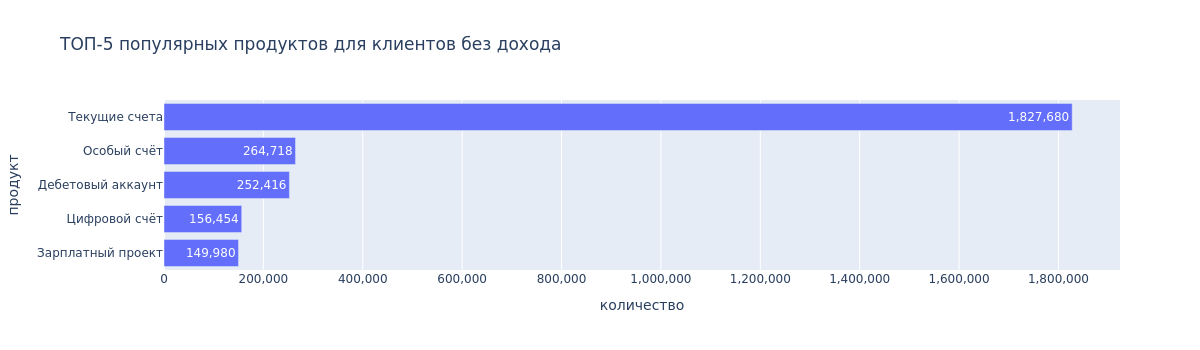

In [127]:
client_ids = df.loc[df["fecha_alta"].notna(), "renta"]
fig = target.loc[client_ids.isna(), feats[2:]].rename(columns=prods) \
    .sum().sort_values().tail(5).plot(
        kind="barh", text_auto=True,
        title="ТОП-5 популярных продуктов для клиентов без дохода",
        labels={"index": "продукт", "value": "количество"})
fig.update_layout(
    height=350, width=1200, showlegend=False,
    xaxis=dict(exponentformat="none"))
fig.write_html(PLOTS_DIR+"target(7)_renta.html")
fig.show(renderer="png")

Основным продуктом является "Текущие счета", также достаточно высокая популярность у признаков "Особый счет", "Дебетовый аккаунт", "Цифровой счет" - популярность близка к общему распределению продуктов по популярности.

Оценим популярность у клиентов с доходом до 25 тысяч, что близко к первому перцентилю датасета.

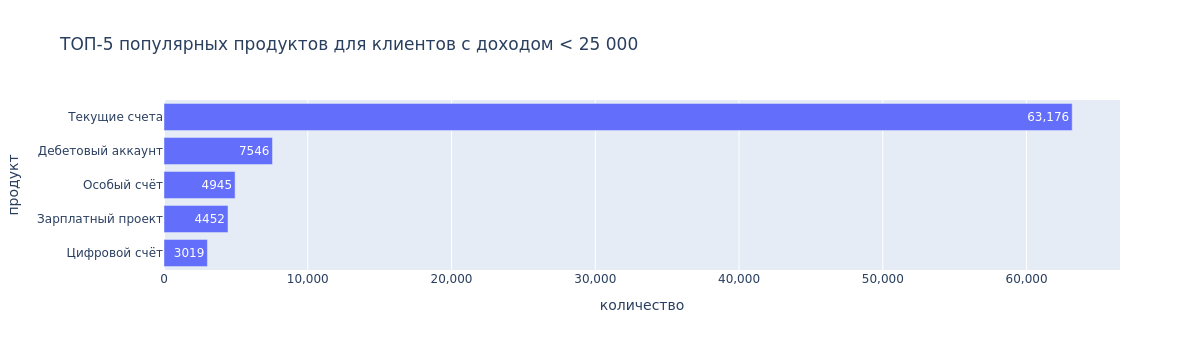

In [128]:
fig = target.loc[client_ids < 25000, feats[2:]].rename(columns=prods) \
    .sum().sort_values().tail(5).plot(
        kind="barh", text_auto=True,
        title="ТОП-5 популярных продуктов для клиентов c доходом < 25 000",
        labels={"index": "продукт", "value": "количество"})
fig.update_layout(
    height=350, width=1200, showlegend=False,
    xaxis=dict(exponentformat="none"))
fig.write_html(PLOTS_DIR+"target(8)_renta.html")
fig.show(renderer="png")

Распределение для клиентов с низким доходом сочетают распределения близкие как к молодым специалистам, так и клиентов старшего возраста. 

Оценим распределение популярности продуктов для клиентов с доходом выше 555 000 тысяч, что составляет последний перцентиль датасета.

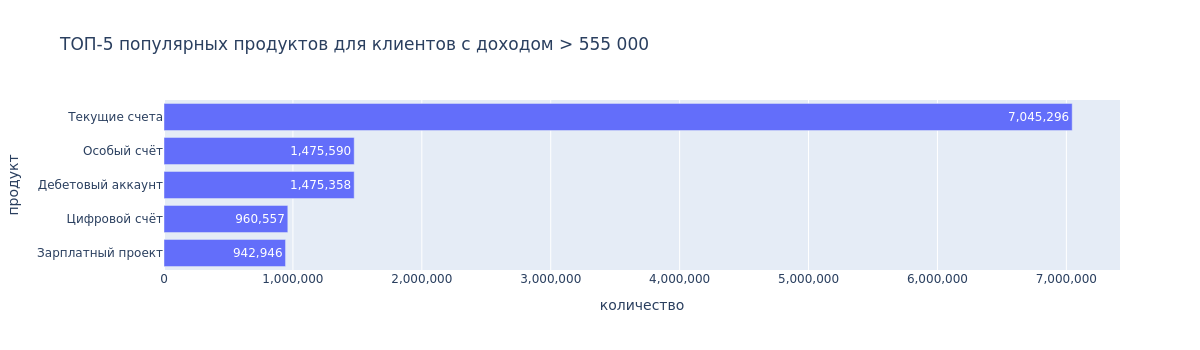

In [129]:
fig = target.loc[client_ids < 555000, feats[2:]].rename(columns=prods) \
    .sum().sort_values().tail(5).plot(
        kind="barh", text_auto=True,
        title="ТОП-5 популярных продуктов для клиентов c доходом > 555 000",
        labels={"index": "продукт", "value": "количество"})
fig.update_layout(
    height=350, width=1200, showlegend=False,
    xaxis=dict(exponentformat="none"))
fig.write_html(PLOTS_DIR+"target(9)_renta.html")
fig.show(renderer="png")

Распределение для таких клиентов очень похожа на клиентов в возрасте от 30 до 65 лет.

#### Количество продуктов и активность клиентов

Оценим распределение количества использованных продуктов в месяц.

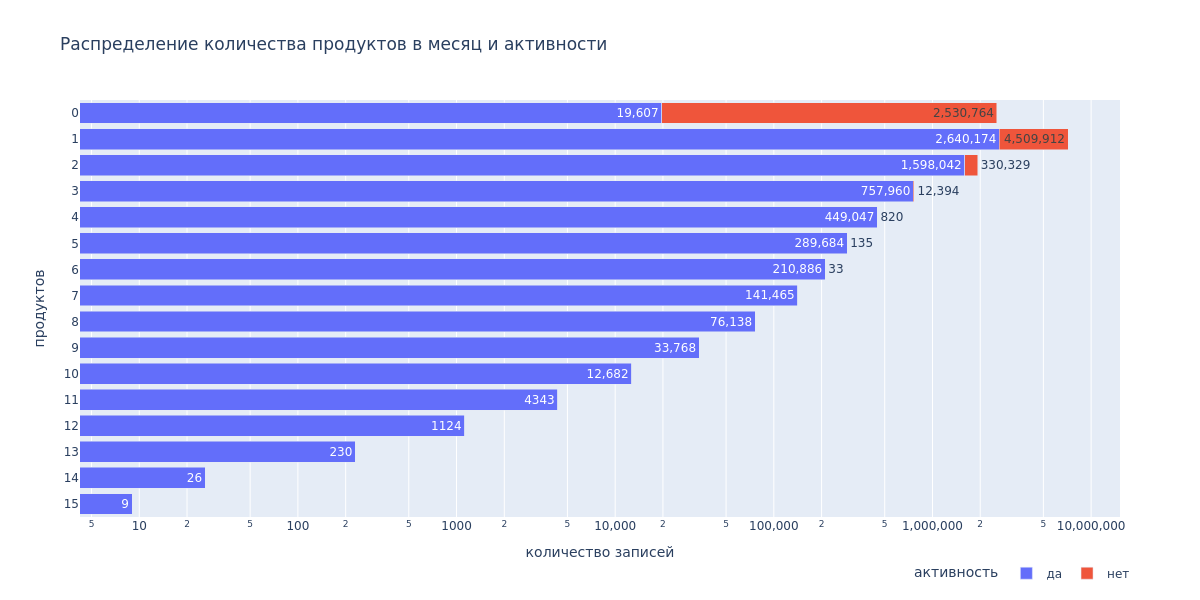

In [130]:
client_ids = df.loc[
    df["fecha_alta"].notna(), "ind_actividad_cliente"
].rename("активность").to_frame().astype(int)
client_ids["продуктов"] = target[feats[2:]].sum(axis=1)
client_ids = client_ids.pivot_table(
    index="продуктов", columns="активность", 
    aggfunc="size", fill_value=0).rename(
        columns = {1: "да", 0: "нет"})
client_ids = client_ids[client_ids.columns[::-1]]
fig = client_ids.plot(
    kind="barh", text_auto=True, barmode="stack",
    title="Распределение количества продуктов в месяц и активности",
    labels={"value": "количество записей"})
fig.update_layout(
    height=600, width=1200, 
    xaxis=dict(type="log", exponentformat="none"),
    yaxis=dict(autorange="reversed", dtick=1),
    legend=dict(orientation="h", x=0.8, y=-0.1))
fig.write_html(PLOTS_DIR+"target(10)_ind_actividad_cliente.html")
fig.show(renderer="png")

Исходя из количества продуктов, которыми клиент пользовался ежемесячно можно отметить, что для некоторых записей была указана активность клиента при отсутствии использованных продуктов за этот месяц. И имеются обратные случаи, когда использовалось до 6 продуктов неактивными клиентами. Возможно не все продукты помечаются активностью клиента. Например, при использовании в месяц одного продукта более половины таких записей отмечены как неактивные. Оценим какие продукты приходятся на записи для клиентов без активности.

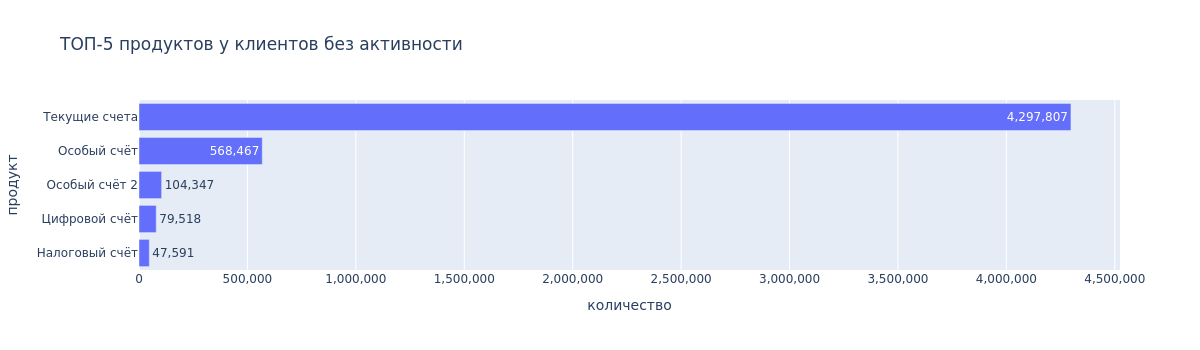

In [131]:
client_ids = df.loc[
    df["fecha_alta"].notna(), "ind_actividad_cliente"]
fig = target.loc[client_ids == 0, feats[2:]].rename(columns=prods) \
    .sum().sort_values().tail(5).plot(
        kind="barh", text_auto=True,
        title="ТОП-5 продуктов у клиентов без активности",
        labels={"index": "продукт", "value": "количество"})
fig.update_layout(
    height=350, width=1200, showlegend=False,
    xaxis=dict(exponentformat="none"))
fig.write_html(PLOTS_DIR+"target(11)_ind_actividad_cliente.html")
fig.show(renderer="png")

Основная масса неактивных записей у клиентов приходится на продукт "Текущие счета", также немало записей по продукту "Особый счет". По остальным продуктам существенно меньше записей с признаком неактивности клиента.

Дополнительно можно отметить, что на одного клиента доходило до 15-ти продуктов за месяц, однако основная масса клиентов использовали 1-2 продукта, либо не использовали ни одного. Для таких случаев подойдут как модели классификации для продуктов, предложенных алгоритмами рекоммендации, типа ALS, так и мульти-лейбл (multi-label) классификации.

In [132]:
del clients

#### Новые продукты

Оценим распределение новых продуктов у клиента, которых не было в предыдущем месяце.

In [133]:
# Признак не последней записи у клиента
client_ids = target.groupby("ncodpers") \
    .cumcount(ascending=False) != 0
# Получение целевых признаков
target[target.columns[2:]] = (
    # Получаем результат логического И между
    # неиспользованными продуктами в текущем месяце 
    ~target[target.columns[2:]] & 
    # и использованными продуктами в следующем
    target.groupby("ncodpers")[target.columns[2:]] \
        .shift(-1))
# Исключение последних записей по клиенту
target = target[client_ids].copy()
del client_ids

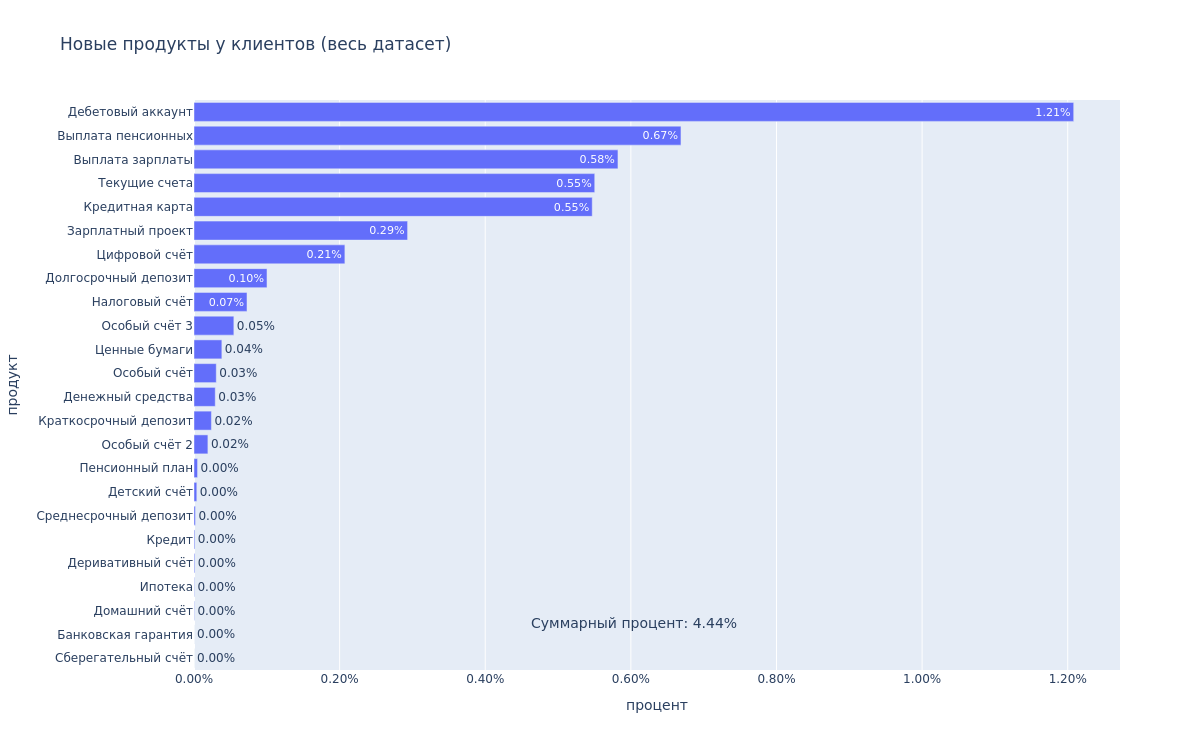

In [134]:
fig = target[feats[2:]].mean() \
    .rename(index=prods).loc[lambda x: x > 0] \
    .sort_values().plot(
        kind="barh", text_auto=True,
        title="Новые продукты у клиентов (весь датасет)",
        labels={"index": "продукт", "value": "процент"}
)
fig.update_traces(texttemplate="%{x:.2%}")
fig.update_layout(
    height=750, width=1200, 
    showlegend=False,
    xaxis_tickformat=".2%",
    annotations=[dict(
        text=f"Суммарный процент: {fig.data[0].x.sum():.2%}",
        x=fig.data[0].x.max()/2, showarrow=False,
        font=dict(size=14))])
fig.write_html(PLOTS_DIR+"target(12)_new_products.html")
fig.show(renderer="png")

Если рассматривать весь датасет, то количество новых продуктов в последнем месяце не превышают 1.2% по всем выгрузкам, лидером является продукт "Дебетовый аккаунт" (1.2%), с большим отрывом от него расположился продукт "Выплата пенсионных" (0.67%), далее достаточно бизко по популярности расположился продукт "Выплата зарплаты" (0.58). Первую пятерку по популярности замыкают продукты "Текущие счета" и "Кредитная карта" по 0.55%. Далее продукты существенно теряют в популярности. Суммарный процент по продуктам не превышает 4.44%, однако на клиента могут приходиться несколько продуктов, соответственно процент клиентов будет еще ниже. 

Оценим количество клиентов с новыми продуктами по месяцам.

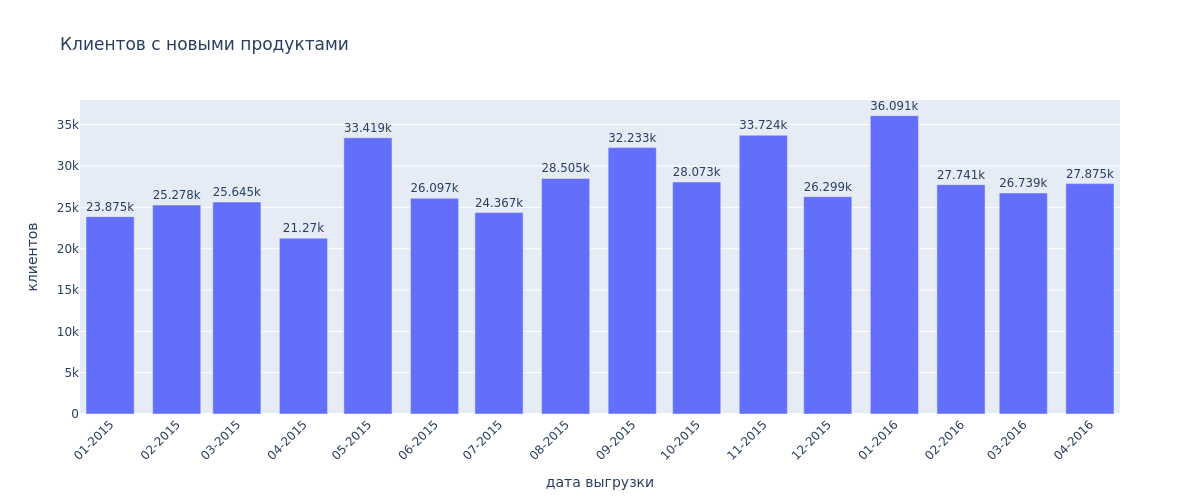

In [135]:
fig = target[
    target[target.columns[2:]].any(axis=1)
].groupby("fecha_dato")["ncodpers"].count().plot(
    kind="bar", text_auto=True,
    title="Клиентов с новыми продуктами",
    labels={"fecha_dato": "дата выгрузки",
            "value": "клиентов"})
fig.update_layout(
    height=500, width=1200, showlegend=False)
fig.update_xaxes(
    tickmode="array",
    tickvals=df["fecha_dato"].unique(),
    ticktext=[
        date.strftime("%m-%Y") 
        for date in df["fecha_dato"].unique()],
    tickformat="%m-%Y",
    tickangle=-45)
fig.update_traces(textposition="outside")
fig.write_html(PLOTS_DIR+"target(13)_new_products.html")
fig.show(renderer="png")

Ежемесячно новыми продуктами пользуются от 21 до 36 тысяч клиентов. Оценим какое количество новых продуктов было у клиентов за весь период.

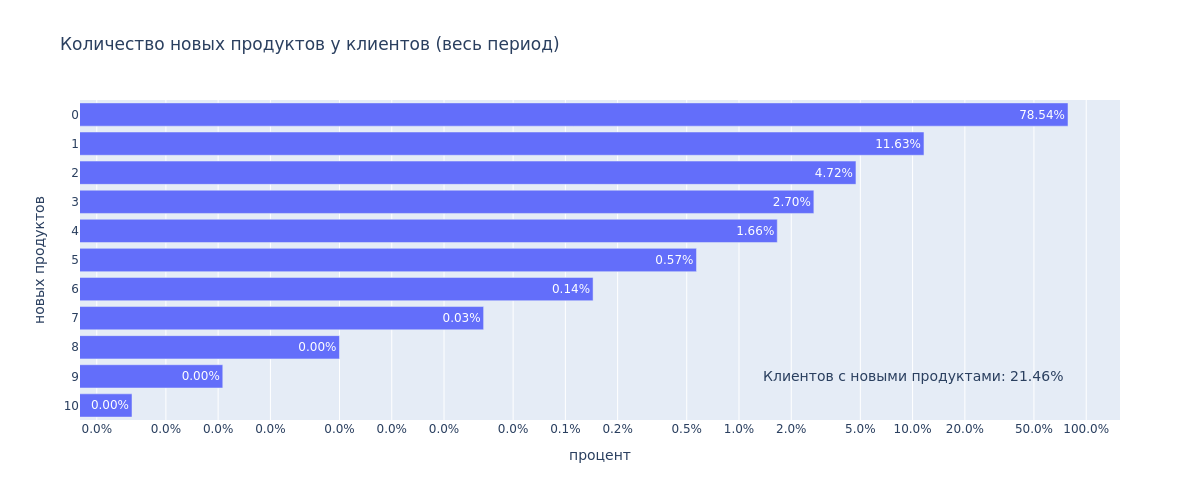

In [136]:
fig = target.groupby("ncodpers")[target.columns[2:]] \
    .any().sum(axis=1).value_counts(normalize=True) \
    .plot(
        kind="barh", text_auto=True,
        title="Количество новых продуктов у клиентов (весь период)",
        labels={"index": "новых продуктов", "value": "процент"})
fig.update_traces(texttemplate="%{x:.2%}")
fig.update_layout(
    height=500, width=1200, showlegend=False, 
    xaxis_type="log", xaxis_tickformat=".1%", 
    yaxis=dict(autorange="reversed", dtick=1),
    annotations=[dict(
        text=f"Клиентов с новыми продуктами: {fig.data[0].x[1:].sum():.2%}",
        x=-1, y=9, showarrow=False, font=dict(size=14))])
fig.write_html(PLOTS_DIR+"target(14)_new_products.html")
fig.show(renderer="png")

За весь период у более 21% клиентов были новые продукты, максимальное количество новых продуктов на клиента - 10, однако количество таких клиентов крайне низкое. Более половины таких клиентов воспользовались только 1-м новым продуктом, а менее четверти - 2-мя.

Оценим количество новых продуктов у клиентов в 2016 году.

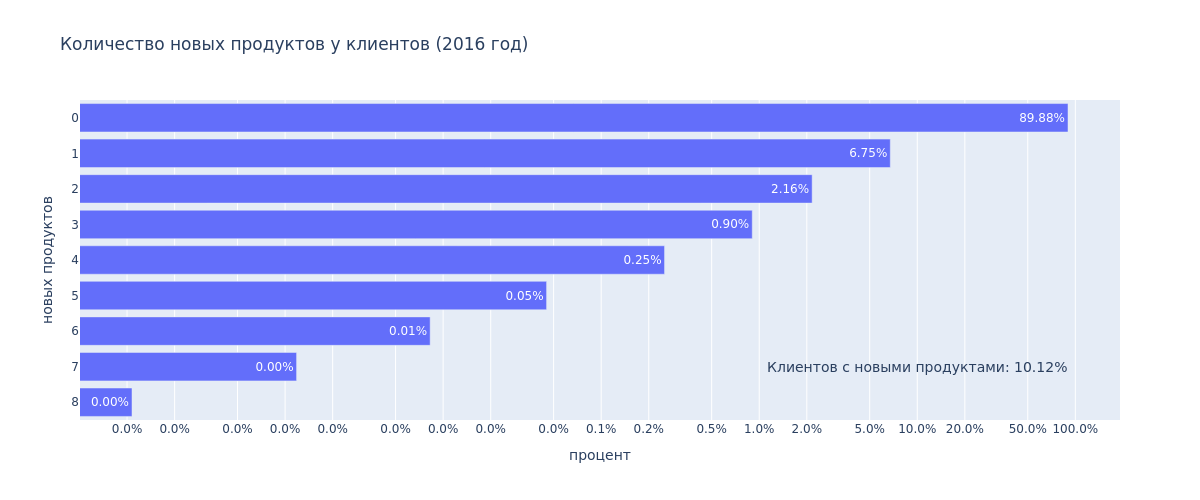

In [137]:
fig = target[target["fecha_dato"] > pd.to_datetime("2016-01-01")] \
    .groupby("ncodpers")[target.columns[2:]] \
    .any().sum(axis=1).value_counts(normalize=True) \
    .plot(
        kind="barh", text_auto=True,
        title="Количество новых продуктов у клиентов (2016 год)",
        labels={"index": "новых продуктов", "value": "процент"})
fig.update_traces(texttemplate="%{x:.2%}")
fig.update_layout(
    height=500, width=1200, showlegend=False, 
    xaxis_type="log", xaxis_tickformat=".1%", 
    yaxis=dict(autorange="reversed", dtick=1),
    annotations=[dict(
        text=f"Клиентов с новыми продуктами: {fig.data[0].x[1:].sum():.2%}",
        x=-1, y=7, showarrow=False, font=dict(size=14))])
fig.write_html(PLOTS_DIR+"target(15)_new_products.html")
fig.show(renderer="png")

В 2016 году процент клиентов с новыми продуктами в следующем месяце существенно ниже и составляет чуть больше 10% от всех клиентов. Также основную массу составляют клиенты, воспользовавшиеся только одним новым продуктом.

#### Промежуточные выводы

Проведен анализ банковских продуктов, в том числе в разрезе признаков возраста, дохода и активности клиента. По результатам анализа можно отметить следующее:

1. Исключены признаки, по которым отсутствует большинство значений;
2. Имеются пропуски по 2-м продуктам, решено заполнить такие пропуски значением 0;
3. Выявлено наличие закономерностей по продуктам для разных возрастных групп клиентов, это может помочь для выявления аномалий по возрасту;
4. Для несовершеннолетних клиентов основным продуктом является "Детский счет", что подтверждает наличие таких клиентов в датасете, причем имеются другие продукты, которые могут говорить о наличии ошибок в возрасте для таких клиентов;
5. По доходам явной закономерности не выявлено, тем более наличие несовершеннолетних клиентов может говорить о том, что пропуски могут говорить об отсутствии доходов, возможно не для всех клиентов такие данные запрашивались.
6. В части активности также выявлены расхождения, имеются записи об активности клиентов, которые не пользовались услугами, а также довольно большое количество клиентов без активности пользовались не менее одним продуктом - не совсем понятная закономерность, по которой формируется данный признак.
7. Произведена оценка целевых признаков - банковских продуктов, которых не было в текущем месяце у клиента, но появились в следующем. Большинство клиентов в датасете не пользовалось новыми продуктами, только у 21% из них были новые продукты за весь период, а за 2016 год только у 10% клиентов. Ежемесячно новыми продуктами пользуются порядка 21-36 тысяч клиентов.

In [138]:
del col, cols, fd, feats, fig, i, prods, target

### Обработка пропусков

#### Массовые пропуски
Оценим количество пропусков в данных.

In [139]:
# Количество пропусков в данных
print("Количество пропусков:")
df.isna().sum().loc[lambda x: x > 0]

Количество пропусков:


ind_empleado                27734
pais_residencia             27734
sexo                        26755
age                         27734
fecha_alta                  27734
ind_nuevo                   27734
antiguedad                  27734
indrel                      27734
ult_fec_cli_1t           13622516
indrel_1mes                149781
tiprel_1mes                149781
indresi                     27734
indext                      27734
conyuemp                 13645501
canal_entrada              186126
indfall                     27734
tipodom                     27735
cod_prov                    93591
nomprov                     93591
ind_actividad_cliente       27734
renta                     2794375
segmento                   189368
ind_nomina_ult1             16063
ind_nom_pens_ult1           16063
dtype: int64

При анализе признаков было отмечено, что имеются клиенты без даты начала отношений, также можно отметить, что для большей части признаков имеется одинаковое количество пропусков. Оценим приходятся ли эти пропуски на все пропуски даты начала отношений.

In [140]:
df[df["fecha_alta"].isna()].isna().sum().loc[lambda x: x > 0]

ind_empleado             27734
pais_residencia          27734
sexo                     26685
age                      27734
fecha_alta               27734
ind_nuevo                27734
antiguedad               27734
indrel                   27734
ult_fec_cli_1t           27734
indrel_1mes              27734
tiprel_1mes              27734
indresi                  27734
indext                   27734
conyuemp                 27734
canal_entrada            27734
indfall                  27734
tipodom                  27734
cod_prov                 27734
nomprov                  27734
ind_actividad_cliente    27734
renta                    27734
segmento                 27734
ind_nomina_ult1          15846
ind_nom_pens_ult1        15846
dtype: int64

Все такие записи пересекаются, хотя для некоторых клиентов имеются значения пола, а также двух целевых признако с пропусками. Оценим сколько клиентов затрагивает такая проблема.

In [141]:
nan_clients = df[df["fecha_alta"].isna()]["ncodpers"].unique()
print(
    "Количество клиентов с пропусками:",
    len(nan_clients))

Количество клиентов с пропусками: 7340


Оценим имеются ли записи без пропусков для таких клиентов.

In [142]:
df[df["ncodpers"].isin(nan_clients)].loc[
    lambda x: ~x["fecha_alta"].isna()].iloc[:, :15]

,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,ult_fec_cli_1t,indrel_1mes,tiprel_1mes,indresi,indext
144618,2016-04-28,35152,N,ES,V,65.00,1996-03-25,1.00,0.00,1.00,NaT,3.0,P,S,N
144619,2016-05-28,35152,N,ES,V,65.00,1996-03-25,1.00,1.00,1.00,NaT,1.0,A,S,N
187774,2015-11-28,41449,N,ES,V,58.00,1998-07-29,1.00,0.00,1.00,NaT,3.0,P,S,N
187775,2015-12-28,41449,N,ES,V,58.00,1998-07-29,0.00,183.00,1.00,NaT,1.0,A,S,N
187776,2016-01-28,41449,N,ES,V,58.00,1998-07-29,0.00,184.00,1.00,NaT,1.0,A,S,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12631006,2016-01-28,1395870,N,ES,V,47.00,2015-05-07,1.00,1.00,1.00,NaT,1.0,A,S,N
12631007,2016-02-28,1395870,N,ES,V,48.00,2015-05-07,1.00,3.00,1.00,NaT,1.0,A,S,N
12631008,2016-03-28,1395870,N,ES,V,48.00,2015-05-07,1.00,4.00,1.00,NaT,1.0,A,S,N
12631009,2016-04-28,1395870,N,ES,V,48.00,2015-05-07,1.00,5.00,1.00,NaT,1.0,A,S,N


Для части клиентов имеются записи, но таких записей довольно мало и они явно не охватывают всех клиентов с пропусками. Оценим даты записи данных для пропущенных и имеющихся значений, также добавим дату регистрации клиента в банке для оценки.

In [143]:
nan_df = df.loc[
    df["ncodpers"].isin(nan_clients),
    ["fecha_dato", "ncodpers", "fecha_alta"]
].dropna().groupby("ncodpers").agg({
    "fecha_dato": ["min", "max"],
    "fecha_alta": "first"
}).droplevel(0, "columns").join(
    df.loc[lambda x: x["fecha_alta"].isna()] \
        .groupby("ncodpers")["fecha_dato"] \
            .agg(["min", "max"]),
    rsuffix="_nan")

print(f"Количество клиентов: {len(nan_df)}")
print(f"Пропуски раньше: {(nan_df['max_nan'] < nan_df['min']).mean():.2%}")
print(f"Пропуски позже: {(nan_df['max'] < nan_df['min_nan']).sum():.2%}")
print(f"Пропуски раньше регистрации: {(nan_df['max_nan'] < nan_df['first']).mean():.2%}")

Количество клиентов: 309
Пропуски раньше: 100.00%
Пропуски позже: 0.00%
Пропуски раньше регистрации: 0.00%


Всего 309 клиентов имеют данные, при этом у всех таких клиентов записи с пропусками раньше чем без пропусков, все пропуски позже даты регистрации клиента. Оценим количество записей без пропусков для таких клиентов.

In [144]:
df[df["ncodpers"].isin(nan_df.index)] \
    .groupby("ncodpers")[["fecha_dato", "fecha_alta"]] \
    .count().describe(percentiles=PERCENTILES).rename(columns={
        "fecha_dato": "Записей всего:",
        "fecha_alta": "Записей без пропусков:"}).T
del nan_df

В среднем от половины до 2/3 записей у таких клиентов с пропусками. Оценим первые записи без пропусков по таким клиентам.

In [145]:
df.loc[df["ncodpers"].isin(nan_clients) & df["fecha_alta"].notna()] \
    .groupby("ncodpers").head(1)[[
        "fecha_dato", "ncodpers", "fecha_alta", "antiguedad", 
        "tiprel_1mes", "indrel_1mes"]]

,fecha_dato,ncodpers,fecha_alta,antiguedad,tiprel_1mes,indrel_1mes
144618,2016-04-28,35152,1996-03-25,0.00,P,3.0
187774,2015-11-28,41449,1998-07-29,0.00,P,3.0
242397,2016-02-28,48623,1996-10-30,0.00,P,3.0
277740,2015-10-28,53148,1996-12-30,0.00,P,3
317425,2015-08-28,58520,1997-07-23,0.00,P,3.0
...,...,...,...,...,...,...
12518458,2016-02-28,1383859,2015-02-20,0.00,P,3
12533909,2015-08-28,1385426,2015-03-02,0.00,P,3.0
12563952,2016-03-28,1388484,2015-03-19,0.00,P,3.0
12615496,2015-09-28,1394072,2015-04-27,0.00,P,3.0


Похоже, что большинство из этих клиентов являются повторно пришедшими, по которым данные только появились, однако имеются и первичные клиенты. Взглянем на количество уникальных значений признаков tiprel_1mes и indrel_1mes.

In [146]:
df.loc[df["ncodpers"].isin(nan_clients) & df["fecha_alta"].notna()] \
    .groupby("ncodpers").head(1)[["tiprel_1mes", "indrel_1mes"]].value_counts()

tiprel_1mes  indrel_1mes
P            3.0            199
             3               79
A            1.0             16
             1                5
             2                4
I            2.0              3
A            2.0              3
Name: count, dtype: int64

В основном это повторно пришедшие клиенты, однако по ним невозможно восстановить дату их ухода - для большинства из них были взаимодействия с банковскими продуктами в предыдущий период. Также будет сложным восстановить активность таких клиентов, так как не совсем понятна логика получения данных признаков. Записи со значениями можно оставить.

Также датасет вероятно содержит клиентов, у которых всего одна запись, а после удаления клиентов с пропусками по дате регистрации. Такие клиенты также подлежат удалению, так как для таких клиентов нет данных по продуктам в следующем месяце.

Оценим оставшиеся пропуски после удаления пропусков по дате регистрации `fecha_alta` и удаления клиентов с одной записью. Также заполним пропуски по целевым столбцам нулями и преобразуем в логические, пропущенный признак `conyuemp` нулями, а возможные пропуски в значениях некоторых столбцов ближайшими заполненными значениями.

In [147]:
# Удаление клиентов с пропусками
df = df[~df["fecha_alta"].isna()].copy()

# Удаление клиентов с одной записью
nan_clients = df["ncodpers"].map(
    df.groupby("ncodpers")["ncodpers"].count()) == 1
print("Клиентов с одной записью:", nan_clients.sum())
# Удаление клиентов с одной записью
df = df[~nan_clients].copy()

# Заполнение пропусков по целевым признакам 
# и перевод значений в логические
for col in df.columns[24:]:
    df[col] = df[col].fillna(0).astype(bool)

# Заполнение пропусков ближайшими значениями 
for col in ["sexo", "conyuemp", "tipodom", 
            "canal_entrada", "segmento"]:
    df[col] = df.groupby("ncodpers")[col].ffill()
    df[col] = df.groupby("ncodpers")[col].bfill()

# Заполнение пропусков conyuemp нулями
df["conyuemp"] = df["conyuemp"].fillna(0).astype(bool)

# Вывод количества оставшихся пропусков
print("Пропуски после обработки:")
print(df.isna().sum().loc[lambda x: x > 0])

Клиентов с одной записью: 9242
Пропуски после обработки:
sexo                    70
ult_fec_cli_1t    13590252
indrel_1mes         114392
tiprel_1mes         114392
canal_entrada        22865
cod_prov             65857
nomprov              65857
renta              2757492
segmento             24664
dtype: int64


После такой обработки остались пропуски по полу клиента, отношениям на начало месяца, каналам прихода, а также сегменту клиента. Значения последней даты и провинции могут иметь пропуски, а по доходу клиента вероятно не все данные собирались, особенно для иностранных резидентов.

#### Пол

Так как пропусков по полу клиента очень мало, данный признак заполним наиболее часто встречающимся значением.

In [148]:
df["sexo"] = df["sexo"].fillna(df["sexo"].mode().iloc[0])
print("Осталось пропусков по полу:", df["sexo"].isna().sum())

Осталось пропусков по полу: 0


#### Отношения на начало месяца

Оценим пропуски по признакам `indrel_1mes` и `tiprel_1mes`.

Количество клиентов совпадает с количеством пропусков по данным признакам. Судя по всему достаточно большую из них долю составляют новые клиенты с одной записью. Такие клиенты не нужны в датасете, так как по ним отсутствуют сведения о продуктах в следующем месяце. Исключим таких клиентов и оценим оставшиеся записи с пропусками.

In [149]:
nan_clients = df[df["indrel_1mes"].isna()]["ncodpers"].unique()
print("Клиентов с пропуском по indrel:", len(nan_clients))
nan_clients = np.unique(np.concatenate([
    nan_clients, 
    df[df["tiprel_1mes"].isna()]["ncodpers"].unique()]))
print(
    "Клиентов с пропусками по indrel и tiprel:",
    len(nan_clients))
df[df["ncodpers"].isin(nan_clients)].iloc[:, :15]

Клиентов с пропуском по indrel: 114392
Клиентов с пропусками по indrel и tiprel: 114392


,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,ult_fec_cli_1t,indrel_1mes,tiprel_1mes,indresi,indext
187865,2015-08-28,41467,N,ES,H,60.00,2015-08-28,1.00,0.00,1.00,NaT,NaN,NaN,S,N
187866,2015-09-28,41467,N,ES,H,60.00,2015-08-28,1.00,1.00,1.00,NaT,1.0,A,S,N
187867,2015-10-28,41467,N,ES,H,60.00,2015-08-28,1.00,2.00,1.00,NaT,1.0,A,S,N
187868,2015-11-28,41467,N,ES,H,60.00,2015-08-28,1.00,3.00,1.00,NaT,1.0,A,S,N
187869,2015-12-28,41467,N,ES,H,60.00,2015-08-28,1.00,4.00,1.00,NaT,1.0,A,S,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13643091,2016-05-28,1548204,N,ES,V,54.00,2016-04-29,1.00,1.00,1.00,NaT,1,A,S,N
13643092,2016-04-28,1548206,N,ES,H,40.00,2016-04-29,1.00,0.00,1.00,NaT,NaN,NaN,S,N
13643093,2016-05-28,1548206,N,ES,H,40.00,2016-04-29,1.00,1.00,1.00,NaT,1,A,S,N
13643094,2016-04-28,1548207,N,ES,V,32.00,2016-04-29,1.00,0.00,1.00,NaT,NaN,NaN,S,S


Количество пропусков соответствует количеству клиентов, значит у каждого по одной записи с пропусками. Судя по записям таких клиентов можно предположить, что пропуски приходятся на клиентов, дата появления которых приходится на 28-е и выше число текущего или предыдущего месяца. Оценим приходятся ли все пропуски на первую запись, а также на каких клиентов приходятся пропуски.

In [150]:
print(
    "Процент пропусков в первых записях: ",
    df[df["ncodpers"].isin(nan_clients)] \
        .groupby("ncodpers")["indrel_1mes"] \
        .agg(lambda x: pd.isna(x.iloc[0])).mul(100) \
        .mean().round(2), "%", sep="")
print(
    "Уникальные значения indrel_1mes:",
    df[df["ncodpers"].isin(nan_clients)]["indrel_1mes"] \
        .unique())

Процент пропусков в первых записях: 99.98%
Уникальные значения indrel_1mes: [nan '1.0' '1' '3' '3.0' '2.0']


Большинство пропусков приходятся на первые записи. Встречаются как новые клиенты, так и ранее пользовавшиеся услугами. Для начала взглянем на клиентов, у которых пропуски приходятся не на первую запись.

In [151]:
nan_df = df[df["ncodpers"].isin(
    df[df["ncodpers"].isin(nan_clients)] \
        .groupby("ncodpers")["indrel_1mes"] \
        .agg(lambda x: pd.isna(x.iloc[0])) \
        .loc[lambda x: ~x].index)]
display(nan_df.iloc[:, :15].head(20))
print("Количество клиентов:", nan_df["ncodpers"].nunique())
print(
    "Клиентов с последней датой:", 
    nan_df.groupby("ncodpers")["ult_fec_cli_1t"] \
        .agg(lambda x: x.notna().any()).sum())
print("Значения последней даты",
      nan_df["ult_fec_cli_1t"].dropna().value_counts())
print()
print("Значения даты регистрации:")
nan_df[["ncodpers", "fecha_alta"]] \
    .drop_duplicates()["fecha_alta"].value_counts()
print("Типы отношений с клиентами на начало месяца:", 
      nan_df["indrel_1mes"].unique())

,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,ult_fec_cli_1t,indrel_1mes,tiprel_1mes,indresi,indext
13425030,2015-11-28,1495553,N,ES,H,22.00,2015-10-31,1.00,0.00,99.00,2015-11-02,1.0,A,S,N
13425031,2015-12-28,1495553,N,ES,H,22.00,2015-10-31,1.00,1.00,1.00,NaT,NaN,NaN,S,N
13425032,2016-01-28,1495553,N,ES,H,22.00,2015-10-31,1.00,2.00,1.00,NaT,1.0,I,S,N
13425033,2016-02-28,1495553,N,ES,H,22.00,2015-10-31,1.00,3.00,1.00,NaT,1.0,I,S,N
13425034,2016-03-28,1495553,N,ES,H,22.00,2015-10-31,1.00,5.00,1.00,NaT,1.0,I,S,N
13425035,2016-04-28,1495553,N,ES,H,22.00,2015-10-31,1.00,5.00,1.00,NaT,1.0,I,S,N
13425036,2016-05-28,1495553,N,ES,H,22.00,2015-10-31,0.00,7.00,1.00,NaT,1.0,A,S,N
13425037,2015-11-28,1495554,N,ES,V,35.00,2015-10-31,1.00,0.00,99.00,2015-11-02,1.0,A,S,N
13425038,2015-12-28,1495554,N,ES,V,35.00,2015-10-31,1.00,1.00,1.00,NaT,NaN,NaN,S,N
13425039,2016-01-28,1495554,N,ES,V,35.00,2015-10-31,1.00,2.00,1.00,NaT,1.0,I,S,N


Количество клиентов: 26
Клиентов с последней датой: 26
Значения последней даты ult_fec_cli_1t
2015-11-02    26
2016-05-30     1
Name: count, dtype: int64

Значения даты регистрации:
Типы отношений с клиентами на начало месяца: ['1.0' nan]


Имеются 26 клиентов, у которых дата регистрации равна 31 октября 2015 года, однако клиенты помечены как ушедшие 2 ноября 2015 года, при этом все клиенты являются новыми. Для таких клиентов заполним пропуски методом ffill, а первые значения `indrel_1mes` и `tiprel_1mes` заменим значениями `P` и `R` соответственно.

In [152]:
# Заполнение пропусков
df.loc[
    df["ncodpers"].isin(nan_df["ncodpers"].unique()),
    ["indrel_1mes", "tiprel_1mes"]
] = df.loc[df["ncodpers"].isin(nan_df["ncodpers"].unique()),
           ["ncodpers", "indrel_1mes", "tiprel_1mes"]] \
    .groupby("ncodpers").ffill()
print("Пропуски заполнены")
display(df.loc[
    df["ncodpers"].isin(nan_df["ncodpers"].unique()),
    ["indrel_1mes", "tiprel_1mes"]
].isna().sum().rename("Пропуски"))

# Замена первых значений
df.loc[(
    df["ncodpers"].isin(nan_df["ncodpers"].unique()) & 
    (df.groupby("ncodpers").cumcount() == 0)
),["indrel_1mes", "tiprel_1mes"]] = ["P", "R"]
print("Замена первых значений произведена, первые 2 записи 5 клиентов:")
df[df["ncodpers"].isin(nan_df["ncodpers"].unique())] \
    .groupby("ncodpers")[["indrel_1mes", "tiprel_1mes"]] \
    .head(2).head(10)
del nan_df

Пропуски заполнены


indrel_1mes    0
tiprel_1mes    0
Name: Пропуски, dtype: int64

Замена первых значений произведена, первые 2 записи 5 клиентов:


Для оставшихся клиентов стратегия заполнения пропусков будет следующей:
1. Заполним пропуски методом bfill по признакам;
2. Изменим значение `tiprel_1mes` на `R` если `indrel_1mes` меньше `3` иначе на `P`;
3. Изменим значение `indrel_1mes` на `P` если оно меньше `3`.

In [153]:
nan_clients = df[df["indrel_1mes"].isna()]["ncodpers"].unique()
print(
    "Количество клиентов с пропуском не в первой записи:",
    df[df["ncodpers"].isin(nan_clients)] \
        .groupby("ncodpers")["indrel_1mes"] \
        .agg(lambda x: pd.notna(x.iloc[0])).sum())
# Заполнение пропусков
df.loc[
    df["ncodpers"].isin(nan_clients),
    ["indrel_1mes", "tiprel_1mes"]
] = df[df["ncodpers"].isin(nan_clients)] \
    .groupby("ncodpers")[["indrel_1mes", "tiprel_1mes"]] \
    .bfill()
print("Пропуски заполнены")
display(df.loc[
    df["ncodpers"].isin(nan_clients),
    ["indrel_1mes", "tiprel_1mes"]
].isna().sum().rename("Пропуски"))

# Обработка первых строк
nan_clients = (
    df["ncodpers"].isin(nan_clients) & 
   (df.groupby("ncodpers").cumcount() == 0))
df.loc[nan_clients, "tiprel_1mes"] = df.loc[
    nan_clients, "indrel_1mes"].astype(float) \
        .apply(lambda x: "R" if x < 3 else "P")
df.loc[nan_clients, "indrel_1mes"] = df.loc[
    nan_clients, "indrel_1mes"].apply(
        lambda x: "P" if float(x) < 3 else x)
print("Замена первых значений произведена, первые 2 записи 5 клиентов:")
display(df[
    nan_clients | nan_clients.shift(1)
][["indrel_1mes", "tiprel_1mes"]].tail(10))


Количество клиентов с пропуском не в первой записи: 0
Пропуски заполнены


indrel_1mes    0
tiprel_1mes    0
Name: Пропуски, dtype: int64

Замена первых значений произведена, первые 2 записи 5 клиентов:


,indrel_1mes,tiprel_1mes
13643086,P,R
13643087,1,A
13643088,P,R
13643089,1,A
13643090,P,R
13643091,1,A
13643092,P,R
13643093,1,A
13643094,P,R
13643095,1,A


Пропуски заполнены, а первые значения новых клиентов корректно исправлены.

#### Канал прихода

In [154]:
print(
    "Процент клиентов без канала прихода: ",
    round(
        df[df["canal_entrada"].isna()]["ncodpers"].nunique() / 
        df["ncodpers"].nunique() * 100, 2
    ), "%", sep="")

Процент клиентов без канала прихода: 0.25%


Клиентов без канала прихода довольно мало от всего датасета - порядка четверти процента. Возможно для старых клиентов данная информация не запрашивалась, взглянем на количество клиентов с пропусками по году первого взаимодействия.

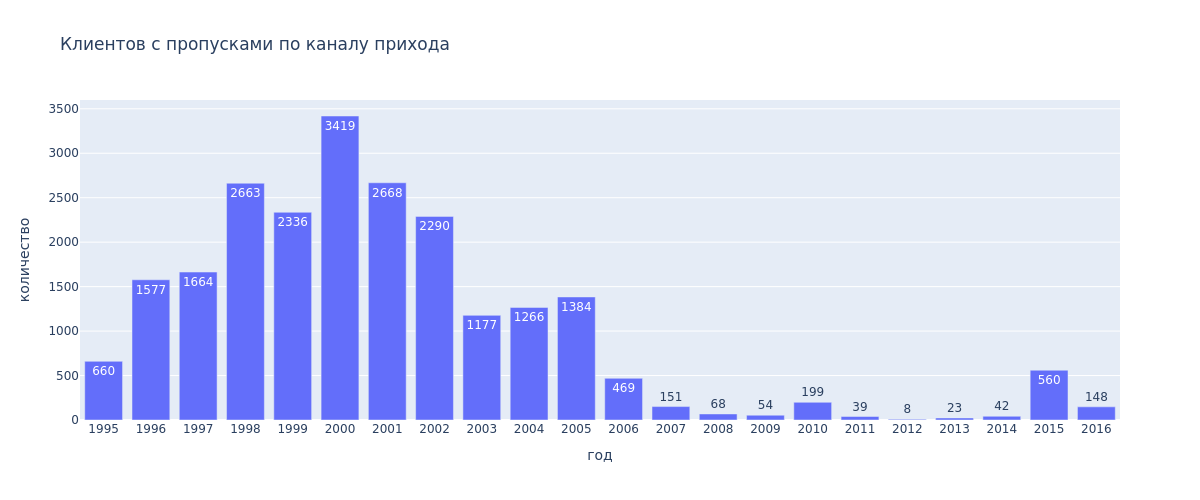

In [155]:
fig = df[df["canal_entrada"].isna()] \
    .groupby("fecha_alta")["ncodpers"] \
        .count().reset_index().apply(
            lambda x: 
            pd.Series({
                "year": x["fecha_alta"].year,
                "count": x["ncodpers"]}
            ), axis=1
        ).groupby("year").sum().plot(
            kind="bar", text_auto=True,
            title="Клиентов с пропусками по каналу прихода",
            labels={"value": "количество", "year": "год"})
fig.update_layout(
    height=500, width=1200, showlegend=False,
    xaxis=dict(dtick=1))
fig.write_html(PLOTS_DIR+"missing(1)_canal_entrada.html")
fig.show(renderer="png")

По каналам прихода можно отметить, что клиенты с пропусками в основном приходили до 2006 года, далее количество пропусков резко снижается. Можно предположить, что не все старые клиенты были достаточно активны, а канал прихода не для всех продуктов фиксировался, соответственно не заполнялся для всех клиентов. Для датасета считаю целесообразным сохранить пропуски по таким клиентам и заполнить их дополнительным значением, например `unknown`, чтобы можно было отличать таких клиентов.

In [156]:
df["canal_entrada"] = df["canal_entrada"].fillna("unknown")

#### Сегмент

Оценим клиентов с пропусками по сегменту.

In [157]:
print(
    "Процент клиентов без сегмента: ",
    round(
        df[df["segmento"].isna()]["ncodpers"].nunique() / 
        df["ncodpers"].nunique() * 100, 2
    ), "%", sep="")

Процент клиентов без сегмента: 0.25%


Клиентов с пропусками по сегменту примерно такое же количество как и с пропусками по каналу прихода. Оценим распределение количества таких клиентов по году прихода.

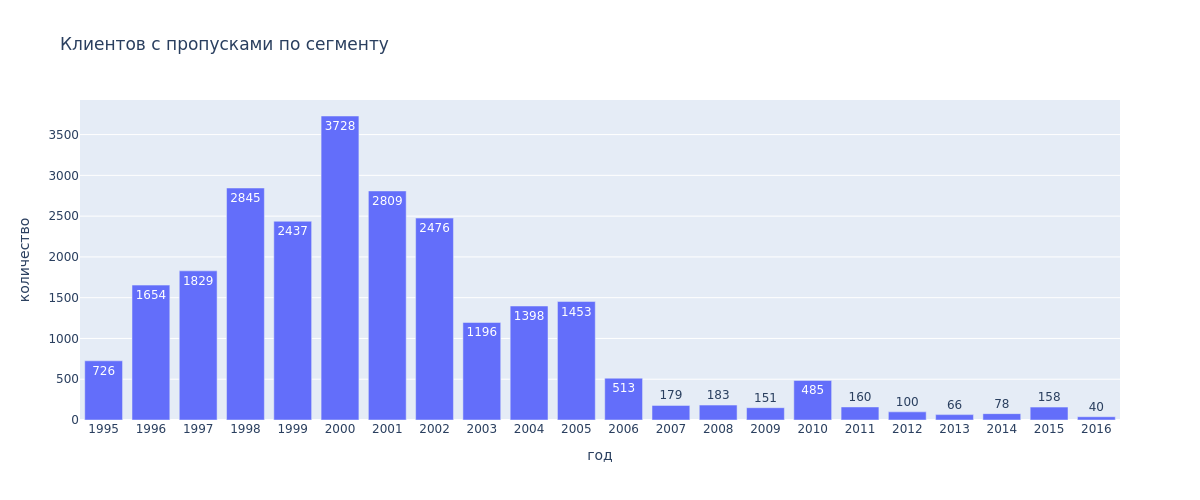

In [158]:
fig = df[df["segmento"].isna()] \
    .groupby("fecha_alta")["ncodpers"] \
        .count().reset_index().apply(
            lambda x: 
            pd.Series({
                "year": x["fecha_alta"].year,
                "count": x["ncodpers"]}
            ), axis=1
        ).groupby("year").sum().plot(
            kind="bar", text_auto=True,
            title="Клиентов с пропусками по сегменту",
            labels={"value": "количество", "year": "год"})
fig.update_layout(
    height=500, width=1200, showlegend=False,
    xaxis=dict(dtick=1))
fig.write_html(PLOTS_DIR+"missing(2)_segmento.html")
fig.show(renderer="png")

Клиентов с пропусками по сегменту больше среди старых клиентов, но меньше среди новых по сравнению с пропусками по каналу прихода. Однако сильно выделается 2010 год, возможно там были какие-то проблемы с данными как по каналу прихода, так и по сегментации, либо пришедшие в 2010 году также проявляли довольно слабую активность. По данному признаку также считаю целесообразным заполнить пропуски отдельным значением `unknown` для выделения таких клиентов.

In [159]:
df["segmento"] = df["segmento"].fillna("unknown")

In [160]:
print("Оставшиеся пропуски в датасете:")
print(df.isna().sum().rename("Пропуски").loc[lambda x: x > 0])

Оставшиеся пропуски в датасете:
ult_fec_cli_1t    13590252
cod_prov             65857
nomprov              65857
renta              2757492
Name: Пропуски, dtype: int64


#### Промежуточные выводы

Завершена обработка пропусков: 
- удалены все записи с пропусками по значению даты 
начала отношений;
- удалены клиенты с одной записью, так как для них 
отсутствуют значения следующего месяца; 
- пропуски по признакам возраста, пола, канала прихода 
и сегмента заполнены ближайшими значениями у клиента;
- пропуски по полу у клиентов без значений заполнены модой;
- пропуски по каналу прихода и сегменту заполнены значением 
`unknown`;
-пропуски остались по признакам последней даты и провинции, 
которые являются нормой для датасета и будут заполнены при 
обработке аномалий или удалены. 

Пропуски по доходу домохозяйств имеют сложную структуру, 
так как они не заполняются для всех иностранных клиентов, 
также в датасете присутствуют несовершеннолетние клиенты 
с детским счетами а некоторые клиенты возможно не имеют 
доходов или могут находиться на иждивении у родственников/
государства, либо такие сведения могут запрашиваться не 
для всех клиентов или не по всем банковским продуктам.

### Обработка аномалий и редких значений

Обработаем выявленные ранее аномалии, также подготовим список признаков, которые останутся в датасете.

In [161]:
output_cols = df.columns.tolist()

#### Возраст

По возрасту были выявлены аномалии, исправим их подготовленной ранее функцией.

In [162]:
client_ids = df["ncodpers"].map(
    df.groupby("ncodpers")["age"].nunique()) > 1
df.loc[client_ids, "age"] = fix_values_increasing(
    df[client_ids])["age"]
df.groupby("ncodpers")["age"].nunique() \
    .describe(PERCENTILES).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,940372.00,1.78,0.42,1.00,1.00,1.00,2.00,2.00,2.00,2.00,2.00,3.00


После исправления аномалий все клиенты имеют не больше 3-х значений возраста без аномальных изменений значений.

#### Пол

Исправим значения пола у клиентов с 2-мя значениями пола.

In [163]:
client_ids = df["ncodpers"].map(
    df.groupby("ncodpers")["sexo"].nunique()) > 1
df.loc[client_ids, "sexo"] = df[client_ids] \
    .groupby("ncodpers")["sexo"].transform(lambda x: x.iloc[-1])
df.groupby("ncodpers")["sexo"].nunique() \
    .describe(PERCENTILES).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
sexo,940372.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


Аномалии исправлены - все клиенты имеют один пол.

#### Занятость клиента или супруга в банке

По занятости клиента в банке были выявлены расхождения - неизвестная категория `S`. С такой категорией имеется только один клиент, однако причину некорректного значения установить затруднительно - возможно этот клиент является работником банка. Лучше удалить таких клиентов, чтобы не вносить ошибку.

In [164]:
df = df[df["ind_empleado"].isin(["A", "B", "F", "N", "P"])]

В части признака супруга(-и) работника банка имеется всего один клиент с полжительным признаком, а по остальным в основном пропуски, либо редкие клиенты со значением `N`. В виду малого разнообразия лучше удалить данный признак.

In [165]:
output_cols.remove("conyuemp")

#### Страна резидентства, провинция и адрес

Исправим расхождения по стране резидентства и провинции подготовленной ранее функцией, все пропуски пометим как `unknown`.

In [166]:
df = fix_residence(df)
df["nomprov"] = df["nomprov"].fillna("unknown")

Расхождения устранены. Так как страна резидентства имеет большую размерность, однако почти все значения - Испания, а на остальные приходится очень малое количество клиентов, при этом признак резидентства страны банка полностью дублирует страну Испания, лучше исключить признак страны резиденства. Также лишним будет код провинции, так как уже имеется признак названия провинции - код провинции цифровой, а признак по сути категориальный и числовые значения не имеют смысла. Также имеется признак типа адреса, который имеет только одно значение. Исключим лишние признаки из датасета.

In [167]:
output_cols.remove("pais_residencia")
output_cols.remove("cod_prov")
output_cols.remove("tipodom")

#### Иностранец по рождению

Исправим двойные значения по признаку `indext`.

In [168]:
print("Количество клиентов с расхождениями:", 
      len(df.groupby("ncodpers")["indext"] \
          .nunique().loc[lambda x: x > 1]))
df["indext"] = df.groupby("ncodpers")["indext"].transform("last")
print("Осталось клиентов с рахождениями:",
      len(df.groupby("ncodpers")["indext"] \
          .nunique().loc[lambda x: x > 1]))

Количество клиентов с расхождениями: 235
Осталось клиентов с рахождениями: 0


#### Дата начала отношений и стаж

Исправим выявленные расхождения по дате начала отношений, на основании которой пересчитаем стаж. Воспользуемся подготовленной ранее функцией.

In [169]:
df = fix_double_dates(df)

Клиентов с датой регистрации > выгрузки: 3
Даты исправлены

Клиентов с двойными датами и совпадениями: 13
Даты исправлены

Клиентов с двойными датами: 1
Даты испралены

Осталось клиентов с двойными датами: 0


Данные по расхождениям в дате регистрации исправлены. Также при анализе данных были выявлены случаи, когда записи с датой регистрации в конце предыдущего месяца были в следующем месяце. Исправим расхождения по стажу, а также расхождение в 1 месяц, чтобы значения стажа начинались с 0.

In [170]:
# Исправление стажа
df["antiguedad"] = month_diff(df)

# Исправление расхождений в 1 месяц
client_ids = df["ncodpers"].map(df.groupby("ncodpers")["antiguedad"] \
    .agg(lambda x: x.iloc[0] == 1))
print(
    "Количество клиентов с расхождением в 1 месяц:",
    df[client_ids]["ncodpers"].nunique())
df.loc[client_ids, "antiguedad"] = df.loc[client_ids, "antiguedad"] - 1

Количество клиентов с расхождением в 1 месяц: 9898


Расхождения исправлены, признак даты начала отношений для работы моделей не понадобится.

In [171]:
output_cols.remove("fecha_alta")

Оценим расхождения по признаку нового клиента.

In [172]:
df[
    (df["ind_nuevo"] == 1) & 
    (df["antiguedad"] > 5)
].groupby("ncodpers")["antiguedad"].head(1) \
    .describe(PERCENTILES).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
antiguedad,13419.00,41.85,56.86,6.00,6.00,6.00,6.00,6.00,75.00,169.00,215.00,249.00


Имеются расхождения по 13.4 тысячам клиентов, не менее половины клиентов имеют расхождения в 1 месяц, однако порядка 25% таких клиентов имеют существенные расхождения. На всякий случай оставим такой признак как есть, вдруг он несет скрытый смысл для модели.

#### Типы клиентов и отношение в начале месяца

Значение `P` признака `indrel_1mes` и `R` признака `tiprel_1mes` полностью дублируют друг друга, также значение `P` признака `tiprel_1mes` приходится на все значения `3` и `4` признака `indrel_1mes`. Чтобы исключить такую избыточность по признакам удалим все значения `P` признака `indrel_1mes`, заполним следующим значеним по клиенту и сократим все значения до признаков основного/совладельца путем получения остатка от деления на 2 и приведения к логическому типу bool. А значения признака `tiprel_1mes` уже имеют и сведения о том, что этот клиент являлся бывшим или потенциальным.

In [173]:
# Удаление записей
df.loc[df["indrel_1mes"] == "P", "indrel_1mes"] = np.nan
print("Количество записей удалено:",
      df["indrel_1mes"].isna().sum())

# Заполнение методом ffill по клиентам
df["indrel_1mes"] = df.groupby("ncodpers")["indrel_1mes"].bfill()
print("Осталось пропусков:",
      df["indrel_1mes"].isna().sum())

# Преобразование значений
df["indrel_1mes"] = pd.to_numeric(df["indrel_1mes"])
df["indrel_1mes"] = df["indrel_1mes"] % 2
df["indrel_1mes"].value_counts()

Количество записей удалено: 115029
Осталось пропусков: 0


indrel_1mes
1.00    13608855
0.00        1461
Name: count, dtype: int64

Также признак `tiprel_1mes` содержал неизвестное значение `N`, которое приходилось на значение `P` (потенциальный) признака `indrel_1mes`. Исправим значение `N` на `R` (потенциальный).

In [174]:
df.loc[df["tiprel_1mes"] == "N", "tiprel_1mes"] = "R"

Оценим наличие расхождений по значению `R` (потенциальный) признака `tiprel_1mes` на первый месяц нового клиента.

In [175]:
client_ids = (
    (df["antiguedad"] == 0) & 
    (df["tiprel_1mes"] != "R"))
print("Расхождений по потенциальному клиенту:",
      client_ids.sum())

Расхождений по потенциальному клиенту: 30658


Имеется более 30 тысяч расхождений, причину установить которых невозможно. Оставим признак как есть, возможно в этом есть какой-то скрытый смысл.

#### Признак смерти

В датасете был выявлен один клиент, значение признака смерти у которого изначально введено как `S`, а в последствии исправлено. Исправим начальные данные по такому клиенту.

In [176]:
client_ids = df["ncodpers"].map(
    df.groupby("ncodpers")["indfall"].agg(
        lambda x: 
        (x.iloc[0] == "S") and 
        (x.iloc[-1] == "N")))
df.loc[client_ids, "indfall"] = "N"

#### Дата последнего взаимодействия

По дате последнего взаимодействия и признаку ухода клиента было выявлено наличие значений 99 в выгрузках ранее даты ухода. Исправим такие значения.

In [177]:
client_ids = df["indrel"] == 99
print("Клиентов с датой ухода:", 
      df[client_ids]["ncodpers"].nunique())
print("Записей бывшего клиента:",
      client_ids.sum())

df.loc[client_ids, "indrel"] = df[client_ids] \
    .groupby(["ncodpers", "ult_fec_cli_1t"])["indrel"].transform(
        lambda x: x.where(x.index == x.index[-1], 1))

print("Осталось записей бывшего клиента:",
      len(df[df["indrel"] == 99]))
print("Клиентов с несколькими датами",
      df.groupby("ncodpers")["ult_fec_cli_1t"] \
            .nunique().value_counts()[2:])

Клиентов с датой ухода: 15177
Записей бывшего клиента: 20081
Осталось записей бывшего клиента: 15360
Клиентов с несколькими датами ult_fec_cli_1t
2    159
3      4
4      4
5      1
Name: count, dtype: int64


Теперь все клиенты имеют только последнюю запись по дате ухода. Дата последнего взаимодействия с клиентом также может быть исключена.

In [178]:
output_cols.remove("ult_fec_cli_1t")

#### Бинарные признаки

Обработаем бинарные признаки - все признаки со значениями S/N, а также тип отношений 1/99, активность клиента, признак нового пользователя и исправленный вид отношений заменим на True/False.

In [179]:
for col in ["indrel", "ind_actividad_cliente", 
            "ind_nuevo", "indrel_1mes"]:
    df[col] = df[col] == 1
for col in ["indext", "indfall"]:
    df[col] = df[col] == "S"

Оставшиеся признаки для выгрузки датасета:

In [180]:
print(np.array(output_cols))

['fecha_dato' 'ncodpers' 'ind_empleado' 'sexo' 'age' 'ind_nuevo'
 'antiguedad' 'indrel' 'indrel_1mes' 'tiprel_1mes' 'indresi' 'indext'
 'canal_entrada' 'indfall' 'nomprov' 'ind_actividad_cliente' 'renta'
 'segmento' 'ind_ahor_fin_ult1' 'ind_aval_fin_ult1' 'ind_cco_fin_ult1'
 'ind_cder_fin_ult1' 'ind_cno_fin_ult1' 'ind_ctju_fin_ult1'
 'ind_ctma_fin_ult1' 'ind_ctop_fin_ult1' 'ind_ctpp_fin_ult1'
 'ind_deco_fin_ult1' 'ind_deme_fin_ult1' 'ind_dela_fin_ult1'
 'ind_ecue_fin_ult1' 'ind_fond_fin_ult1' 'ind_hip_fin_ult1'
 'ind_plan_fin_ult1' 'ind_pres_fin_ult1' 'ind_reca_fin_ult1'
 'ind_tjcr_fin_ult1' 'ind_valo_fin_ult1' 'ind_viv_fin_ult1'
 'ind_nomina_ult1' 'ind_nom_pens_ult1' 'ind_recibo_ult1']


#### Промежуточные выводы

Проведена обработка выявленных на этапе анализа аномалий:
- исправлены некорректные изменения в возрасте;
- исправлены расхождения по стране резидентства и признаку резидентства страны банка;
- исправлены на последние все значения признака иностранца по рождению;
- исправлены двойные даты начала отношений и стаж клиента на основании этих данных;
- внесены изменения по типам взаимодействий и видам клиентов на начало месяца, в том числе исключены избыточные значения в двух признаках;
- исправлены аномалии по признаку смерти клиента, когда в начале было значение `S`, а потом `N`;
- исправлены дубликаты по отношению с клиентами, когда отношения были отмечены как бывший клиент, но у него была активность, а дата окончания была позже на несколько месяцев. По таким клиентам оставлены последние записи по каждому значению даты окончания отношений, а предыдущие отмечены как текущий клиент;
- подготовлен список актуальных признаков для модели, все лишние признаки исключены из списка.

### Обработка выбросов

#### Доход домохозяйств

По вопросу обработки выбросов дохода домохозяйств можно отметить следующее:
1. Не совсем понятно, в какое время были получены сведения по доходам, так как во всем датасете у клиента присуствует не более 1-го значения по этому признаку, соответственно значение не менялось за почти 1.5 года. Возможно для некоторых клиентов такие сведения были получены значительно раньше исследуемого промежутка времени и не соответствует текущему уровню дохода;
2. В датасете присутствуют несовершеннолетние клиенты, судя по популярности продукта "Детский счет" у клиентов до 18 лет;
3. Также могут присутсвовать безработные, клиенты с низким достатком или находящиеся на социальном обеспечении, в том числе пенсионеры;
4. Судя по всему, данные о доходах не запрашивались для иностранных граждан, так как такие данные практически отсутствуют и имеются лишь у клиентов, которые вероятнее всего были гражданами Испании, так как у них имеются сведения о регионе. Соответственно по таким клиентам невозможно заполнить пропущенные сведения;
5. Также отсутствие сведений о доходах может говорить об использовании или неиспользовании отдельных банковских продуктов и могут быть полезны для моделей машинного обучения.

На основании вышеизложенного, считаю целесообразным заполнить все пропуски значением `0` которое будет сигнализировать об отсутствии таких сведений в датасете, тем более нулевые значения отсутствуют в выгрузках.

In [181]:
df["renta"] = df["renta"].fillna(0)
print("Пропусков по доходу домохозяйств:",
      df["renta"].isna().sum())

Пропусков по доходу домохозяйств: 0


#### Возраст

По признаку возраста имеется вероятность ошибочных значений, так как имеются аномально большие значения возраста, а также наличие банковских продуктов, которые не характерны для несовершеннолетних клиентов. Обработка выбросов в ручном режиме довольно проблематична, так как имеется большое количество признаков. Воспользуемся регрессионной моделью для предсказания возраста и в случае большого отклоенния фактического возраста от предсказаний заменим такие значения на предсказанные, так как они с большой вероятностью являются выбросами. 

В качестве регрессионной модели будем использовать RandomForest, так как он достаточно быстро обучается, устойчив к переобучению и выбросам, а также может выявить нелинейные взаимосвязи. В качестве признаков для модели воспользуемся следующими:
- банковские продукты, которые могут достаточно сильно зависеть от возраста клиента;
- признак смерти, который влияет на максимальный возраст клиента;
- стаж клиента, который также может коррелировать с возрастом клиента;

In [182]:
# Подготовка признаков для регрессионной модели
prods_cols = df.columns[24:]
ohe_cols = ["indfall", "sexo"]
ohe = OneHotEncoder(drop="first", sparse_output=False)
X_age = df.groupby("ncodpers")[prods_cols].mean()
X_age["antiguedad"] = df.groupby("ncodpers")["antiguedad"].last()
X_age = pd.concat([
    X_age,
    pd.DataFrame(
        ohe.fit_transform(
            df.groupby("ncodpers")[ohe_cols].last()),
        columns=ohe.get_feature_names_out(),
        index=X_age.index)
], axis=1)

y_age = df.groupby("ncodpers")["age"].last()

In [183]:
# Получение предсказаний модели
age_model = RandomForestRegressor(random_state=RANDOM_STATE)
age_model.fit(X_age, y_age)
pred_age = age_model.predict(X_age)

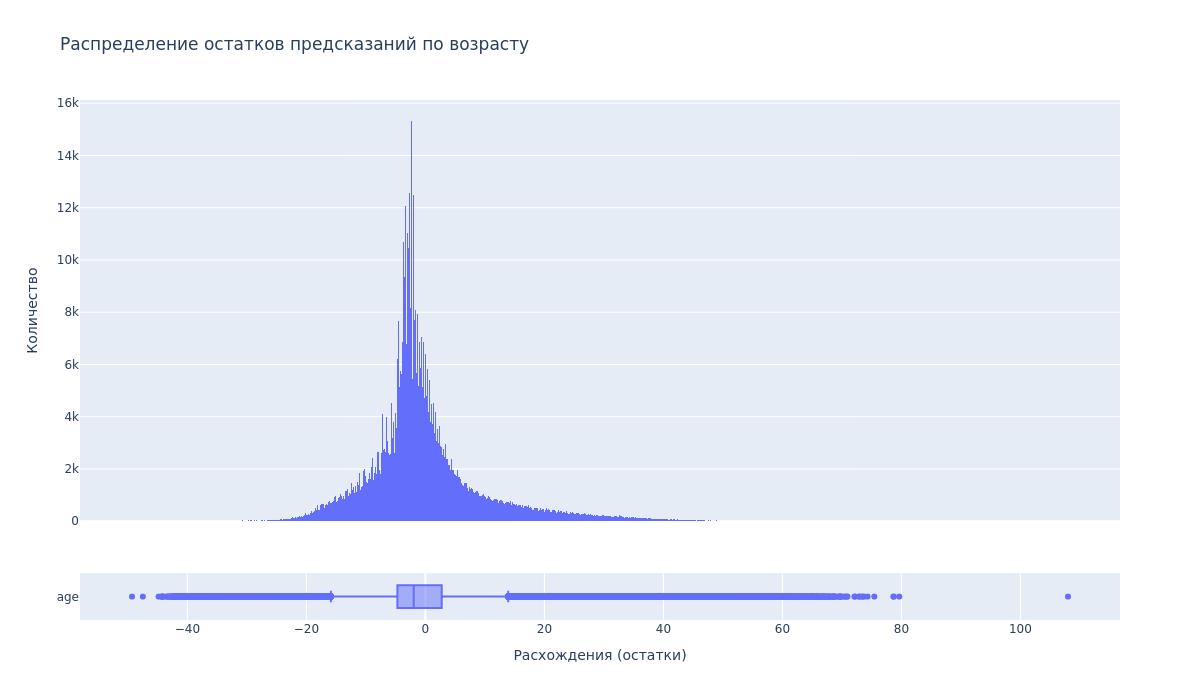

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,940371.00,-0.02,10.26,-49.31,-19.85,-13.84,-4.71,-1.97,2.74,20.91,36.04,108.00


In [184]:
residuals = y_age - pred_age
fig = hist_with_box(residuals)
fig.update_layout(
    title="Распределение остатков предсказаний по возрасту",
    yaxis_title="Количество",
    xaxis2_title="Расхождения (остатки)",
    height=700, width=1200, showlegend=False)
fig.show(renderer="png")
fig.write_html(PLOTS_DIR+"residuals_age.html")
residuals.describe(percentiles=PERCENTILES).to_frame().T

По распределению остатков модели предсказания возраста можно сказать следующее:
- центр распределения в районе нуля, следовательно модель достаточно точна;
- плотность распределения достаточно высокая, но есть длинные хвосты в обе стороны;
- медиана около -2, но среднее значение практически равно 0, стандартное отклонение около 10;
- модель чаще завышает возраст, но расхождения не такие сильные, как при заниженном предсказании.

Исходя из полученного распределения, считаю целесообразным для определения выбросов использовать стандартное отклонение, причем использовать асимметричные пороги для выбросов:
- для отрицательных значений (возраст ниже предсказанного) использовать 3 стандартных отклонения (~30 лет);
- для положительных значений (возраст выше предсказанного) использовать 5 стандартных отклонений (~50 лет).

In [185]:
# Определение порогов для выбросов
n_up = 5
n_lo = 3
up_thres = residuals.mean() + n_up * residuals.std()
lo_thres = residuals.mean() - n_lo * residuals.std()

outs = (residuals > up_thres) | (residuals < lo_thres)
outs = residuals.astype(int) * outs
df["age"] = df["age"] - df["ncodpers"].map(outs)
df["age"].describe(PERCENTILES).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,13610316.00,40.16,17.11,2.00,19.00,21.00,24.00,39.00,50.00,73.00,88.00,117.00


Сохраним датасет после обработки пропусков и аномалий.

In [186]:
df = df[output_cols]
df.to_parquet(
    os.path.join("..", "data", "clean_data.parquet"), 
    index=False)

Для дальнейшей работы лучше перезапустить ядро Python.

In [187]:
# Остановка ядра для его перезапуска
exit()

#### Промежуточные выводы

Проведена обработка выбросов:
1. Выбросы по доходу не обрабатывались, так как нет понимания насколько актуальны эти сведения для старых клиентов, также в датасете имеются несовершеннолетние и могут быть безработные, иждивенцы, либо находящиеся на социальном обеспечении клиенты. Такие сведения возможно запрашивались не для всех продуктов и точно не запрашивались для резидентов других стран. Все пропуски были заполнены нулями.
2. Для определения выбросов по возрасту использована регрессионная модель Random Forest на целевых признаках, признаке смерти и стаже клиента, как наиболее влияющие на возраст. В качестве порогов для определения выбросов выбрано стандартное отклонение, причем использованы асимметричные пороги для нижнего (3σ) и верхнего значения (5σ). Все значения за пределами порога исправлены на предсказанные.

### Трансформер для обработки данных

> ⚠️ Последующий код лучше выполнить после перезапуска ядря Python и повторного запуска раздела "Инициализация".

Подготовим трансформер для обработки датасета.

In [3]:
class BankProductTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, settings_file: str, random_state: int | None = None):
        if random_state is None:
            warnings.warn(
                "Рекомендуется установить random_state для воспроизводимости.",
                UserWarning)
        if os.path.exists(settings_file):
            with open(settings_file) as fd:
                settings = yaml.safe_load(fd)
        else:
            raise FileNotFoundError(
                f"Файл не найден: {settings_file}")
        # Общие признаки и значения
        self.target_cols = settings["target_cols"]
        self.date_col = settings["date_col"]
        self.user_col = settings["user_col"]
        self.country_col = settings["country_col"]
        self.residence_col = settings["residence_col"]
        self.province_col = settings["province_col"]
        self.country_code = settings["country_code"]
        self.start_date_col = settings["start_date_col"]
        self.seniority_col = settings["seniority_col"]
        self.rel_col = settings["rel_col"]
        self.end_date_col = settings["end_date_col"]
        self.age_col = settings["age_col"]
        # Данные для обработки пропусков
        self.missing_col = settings["missing_col"]
        self.ffill_cols = settings["ffill_cols"]
        self.bfill_cols = settings["bfill_cols"]
        self.val_na_cols = settings["val_na_cols"]
        self.depend_val_cols = settings["depend_val_cols"]
        self.mode_fill_cols = settings["mode_fill_cols"]
        self.na1to0_cols = settings["na1to0_cols"]
        self.val_fill_cols = settings["val_fill_cols"]
        self.del_val_bfill_cols = settings["del_val_bfill_cols"]
        # Данные для обработки аномалий
        self.last_val_cols = settings["last_val_cols"]
        self.del_other_val_cols = settings["del_other_val_cols"]
        self.mod2_cols = settings["mod2_cols"]
        self.fix_residence = settings["fix_residence"]
        self.fix_seniority = settings["fix_seniority"]
        self.fix_val_order = settings["fix_val_order"]
        self.fix_rel_col = settings["fix_rel_col"]
        self.fix_bin_cols = settings["fix_bin_cols"]
        self.fix_age_vals = settings["fix_age_vals"]
        self.fix_age_outs = settings["fix_age_outs"]
        self.age_model_age_agg = settings["age_model_age_agg"]
        self.age_model_prods_agg = settings["age_model_prods_agg"]
        self.age_model_ohe_cols = settings["age_model_ohe_cols"]
        self.age_model_num_cols = settings["age_model_num_cols"]
        self.age_model_std_thres = settings["age_model_std_thres"]
        # Столбцы, которые остаются в датасете (кроме целевых)
        self.output_cols = settings["output_cols"]

        self.age_ohe = OneHotEncoder(drop="first", sparse_output=False)
        self.age_model = RandomForestRegressor(random_state=random_state)
        
    def _check_is_dataframe(self, data):
        if not isinstance(data, pd.DataFrame):
            raise TypeError(f"Expected pandas DataFrame, got {type(data)}")
        
    def _fix_residence(self, data: pd.DataFrame):
        # Исправление значений по индикатору резиденции
        country_ids = data[self.country_col] == self.country_code
        data[self.residence_col] = country_ids
        # Исправление значений провинции
        data.loc[
            ~country_ids, self.province_col
        ] = self.val_fill_cols[self.province_col]
        # Исправление ранее заполненных значений 
        # для резидентов с пропусками
        mask = data[self.province_col] == self \
            .val_fill_cols[self.province_col]
        data.loc[country_ids & mask, self.province_col] = np.nan
        data.loc[
            country_ids, self.province_col
        ] = data.loc[country_ids].groupby(
            self.user_col)[self.province_col].ffill()
        data.loc[
            country_ids, self.province_col
        ] = data.loc[country_ids].groupby(
            self.user_col)[self.province_col].bfill()
        data[self.province_col] = data[self.province_col] \
            .fillna(self.val_fill_cols[self.province_col])

        return data
    
    def _month_diff(self, data):
        return (data[self.date_col].dt.to_period("M").astype(int) - 
                data[self.start_date_col].dt.to_period("M").astype(int))

    def _check_month(self, data):
        return data[self.seniority_col] == self._month_diff(data)
    
    def _fix_double_dates(self, data):
        # Получение клиентов, у которых дата регистрации 
        # больше даты первой выгрузки
        mask = data[self.user_col].map((
            data.groupby(self.user_col)[self.date_col].min() + 
            pd.offsets.MonthEnd() -
            data.groupby(self.user_col)[self.start_date_col].max()
        ).dt.days < 0)
        # Установка меньшей даты
        if mask.sum() > 0:
            data.loc[mask, self.start_date_col] = data[mask] \
                .groupby(self.user_col)[self.start_date_col].transform("min")

        # Получение клиентов с 2 датами регистрации
        mask = data[self.user_col].map(
            data.groupby(self.user_col)[self.start_date_col].nunique() > 1)
        # Удаление клиентов без совпадений
        mask = mask & data[mask] \
            .groupby(self.user_col)[self.user_col].transform(
                lambda x: self._check_month(data[
                    data[self.user_col].isin(x.unique())
                ]).any())
        # Установка совпадающей даты
        if mask.sum() > 0:
            data.loc[mask, self.start_date_col] = data.loc[
                mask, self.user_col].map(
                    data.loc[mask].groupby(self.user_col).apply(
                        lambda x: next(iter(
                            x.loc[self._check_month(x), 
                                  self.start_date_col].tail(1)), 
                            np.nan), include_groups=False)).dropna()

        # Получение оставшихся клиентов с 2-мя совпадениями
        mask = data[self.user_col].map(
            data.groupby(self.user_col)[self.start_date_col].nunique() > 1)
        # Замена оставшихся значений на последнее
        if mask.sum() > 0:
            data.loc[mask, self.start_date_col] = data[mask] \
                .groupby(self.user_col)[self.start_date_col].transform("last")
        return data

    @staticmethod
    def _check_order(ser: pd.Series):
        res = np.full(len(ser), True)
        cur = len(res)
        for i in range(len(res)-1, -1, -1):
            if ser.iloc[i] <= cur:
                res[i] = False
                cur = ser.iloc[i]
        return pd.Series(res, index=ser.index)

    @staticmethod
    def _fix_age(group):
        out = group.to_numpy()
        for i in range(len(out)-2, -1, -1):
            out[i] = out[i] if out[i] == out[i + 1] - 1 else out[i + 1]
        return pd.Series(out, index=group.index)
    
    def _get_age_model_data(self, data):
        # Целевой признак для модели предсказания возраста
        y_age = data.groupby(self.user_col)[self.age_col] \
            .agg(self.age_model_age_agg)
        # Получение таргетов как признаков для модели
        X_age = data.groupby(self.user_col)[self.target_cols] \
            .agg(self.age_model_prods_agg)
        # Добавление числовых признаков для модели
        X_age[list(self.age_model_num_cols.keys())] = data.groupby(
            self.user_col)[list(self.age_model_num_cols.keys())] \
                .agg(self.age_model_num_cols)
        # Добавление категориальных признаков для модели
        X_age[self.age_ohe.get_feature_names_out()] = pd.DataFrame(
            self.age_ohe.fit_transform(
                data.groupby(self.user_col)[list(
                    self.age_model_ohe_cols.keys()
                )].agg(self.age_model_ohe_cols)),
            columns=self.age_ohe.get_feature_names_out(),
            index=X_age.index)
        
        return X_age, y_age
    
    def _fix_age_outliers(self, data):
        # Получение данных и обучение модели
        X_age, y_age = self._get_age_model_data(data)
        self.age_model.fit(X_age, y_age)
        
        # Получение остатков
        res = self.age_model.predict(X_age)
        res = y_age - res
        
        # Получение границ для выбросов
        lo_th = res.mean() - (
            self.age_model_std_thres["lower"] * res.std())
        up_th = res.mean() + (
            self.age_model_std_thres["upper"] * res.std())
        outs = (res < lo_th) | (res > up_th)
        
        # Исключение остатков в границах и округление
        outs = res.astype(int) * outs
        
        # Изменение выбросов по возрасту
        data.loc[:, self.age_col] = data[self.age_col] - data[
            self.user_col].map(outs)
        
        return data
    
    def _fix_missing(self, data: pd.DataFrame):
        # Удаление пропусков по столбцу fecha_alta
        data = data[data[self.missing_col].notna()].copy()

        # Удаление одиночных записей
        mask = data[self.user_col].map(
            data.groupby(self.user_col)[self.user_col] \
                .count() > 1)
        data = data[mask].copy()
        
        # Заполнение пропусков по целевым столбцам
        data[self.target_cols] = data[self.target_cols] \
            .fillna(0).astype(bool)
        
        # Замена значений при пропусках во 2-й с 1-й строкой
        for col in self.na1to0_cols:
            # получаем маску 2-й строки
            mask = data.groupby(self.user_col).cumcount() == 1
            # если они содержат пропуски
            mask = mask & data[col].isna()
            # добавляем сдвиг на одну строку назад
            mask = mask | mask.shift(-1)
            # получаем обратно отсортированные значения первых 2-х 
            # строк по группе
            data.loc[mask, col] = data[mask].groupby(self.user_col)[col] \
                .transform(lambda x: pd.Series(
                    list(x)[::-1], index=x.index))
        
        # Заполнение пропусков методом ffill
        data[self.ffill_cols] = data.groupby(
            self.user_col)[self.ffill_cols].ffill()
        
        # Заполнение пропусков методом bfill
        data[self.bfill_cols] = data.groupby(
            self.user_col)[self.bfill_cols].bfill()
        
        # Исключение некорректных значений
        for col, val in self.val_na_cols.items():
            mask = ~data[col].isin(val)
            data.loc[mask, col] = np.nan

        # Заполнение зависимых признаков
        for col, dep in self.depend_val_cols.items():
            for dep_col, val_map in dep.items():
                data[col] = data[col].fillna(
                    data[dep_col].map(val_map))
        
        # Заполнение пропусков модой
        for col in self.mode_fill_cols:
            data[col] = data[col].fillna(data[col].mode().iloc[0])
        
        # Заполнение пропусков значением
        for col, val in self.val_fill_cols.items():
            data[col] = data[col].fillna(val)
        
        # Удаление значений с заполнением bfill
        for col, val in self.del_val_bfill_cols.items():
            data[col] = data[col].replace(val, np.nan)
            data[col] = data[col].bfill()

        return data

    def _fix_anomalies(self, data):
        # Замена значений на последние
        for col in self.last_val_cols:
            data[col] = data.groupby(self.user_col)[col] \
                .transform("last")
            
        # Удаление строк с неизвестным значением
        for col, val in self.del_other_val_cols.items():
            data = data[data[col].isin(val)].copy()
        
        # Остаток от деления на 2
        for col in self.mod2_cols:
            data[col] = pd.to_numeric(data[col]) % 2

        # Исправление данных о резиденции
        if self.fix_residence:
            data = self._fix_residence(data)
        
        # Исправление данных о стаже
        if self.fix_seniority:
            data = self._fix_double_dates(data)
            data[self.seniority_col] = self._month_diff(data)
            # Исправление расхождений в 1 месяц
            mask = data[self.user_col].map(
                data.groupby(self.user_col)[self.seniority_col].agg(
                    lambda x: x.iloc[0] == 1))
            data.loc[mask, self.seniority_col] = data.loc[
                mask, self.seniority_col] - 1
        
        # Исправление некорректного порядка значений
        for col, val in self.fix_val_order.items():
            # Получение словаря с корректным порядком
            order_map = {v: i for i, v in enumerate(val)}
            # Получение маски клиентов с 2 и более значениями
            mask = data[self.user_col].map(
                data.groupby(self.user_col)[col].nunique() > 1)
            # Получение датасета с порядковыми номерами значений
            col_idx = data.loc[mask, [self.user_col]]
            col_idx[col] = data.loc[mask, col].map(order_map)
            # Получение маски по всем значениям
            mask = col_idx.groupby(self.user_col)[col].transform(
                self._check_order).reindex(mask.index) == True
            data.loc[mask, col] = np.nan
            data[col] = data.groupby(self.user_col)[col].bfill()

        # Исправление значений отношения с клиентом
        if self.fix_rel_col:
            mask = data[self.end_date_col].notna()
            if len(data.loc[mask, self.rel_col].unique()) > 1:
                raise ValueError(f"Имеются несколько значений {self.rel_col}"+
                                 " для ушедших клиентов")
            val = data.loc[~mask, self.rel_col].unique()
            if len(val) > 1:
                raise ValueError(f"Имеются несколько значений {self.rel_col}: "+
                                 f"{val} для активных клиентов")
            data.loc[mask, self.rel_col] = data[mask] \
                .groupby([self.user_col, self.end_date_col])[self.rel_col] \
                    .transform(
                    lambda x: x.where(x.index == x.index[-1], val[0]))
        
        # Изменение бинарных признаков
        for col, val in self.fix_bin_cols.items():
            data[col] = data[col].eq(val).astype(bool)

        # Исправление значений возраста (увеличение на 1)
        if self.fix_age_vals:
            data[self.age_col] = data.groupby(
                self.user_col)[self.age_col].transform(self._fix_age)
            
        # Обработка выбросов моделью
        if self.fix_age_outs:
            data = self._fix_age_outliers(data)

        return data
        
    def fit(self, X, y=None):
        self._check_is_dataframe(X)
        # При обучении ничего не делаем, так как для обучения модели 
        # определения выбросов по возрасту необходимо предварительно 
        # привести в порядок все данные, что производит transform
        return self

    def transform(self, X: pd.DataFrame):
        self._check_is_dataframe(X)

        # Сортировка значений по пользователю и дате
        result = X.sort_values(
            by=[self.user_col, self.date_col]).copy()
        
        # Заполнение пропусков с проверкой заполнения
        result = self._fix_missing(result)
        if result[self.output_cols].isna().sum().sum() > 0:
            cols = result[self.output_cols].isna().sum() \
                .loc[lambda x: x > 0].index
            raise ValueError(
                f"Не все пропуски устранены, проверьте столбцы: {cols}")
        
        # Исправление аномалий
        result = self._fix_anomalies(result)

        return result[self.output_cols + self.target_cols]

Загрузим исходный датасет обработаем его трансформером.

In [4]:
df = pd.read_csv(
    os.path.join("data", "train_ver2.csv"), low_memory=False, 
    parse_dates=["fecha_dato", "fecha_alta", "ult_fec_cli_1t"],
    na_values=["NA", " NA", "     NA"])

In [5]:
transformer = BankProductTransformer(
    os.path.join("EDA", ASSETS_DIR, "settings.yaml"), 
    random_state=RANDOM_STATE)
df_clean = transformer.fit_transform(df)

Обработка датасета трансформером занимает порядка 10 минут. Исходный датасет обработан, сравним его с полученным ранее датасетом.

In [6]:
df = pd.read_parquet(
    os.path.join("data", "clean_data.parquet")
).reset_index(drop=True)
print("Датасеты идентичны:", 
      df.equals(df_clean.reset_index(drop=True)))

Датасеты идентичны: True


Датасеты полностью идентичны, исходный код трансформера сохранен в файл `ASSETS/transformer.py`, сохраним дамп трансформера в эту же директорию.

In [7]:
with open(os.path.join(
    "EDA", ASSETS_DIR, "transformer.pkl"
), "wb") as fd:
    joblib.dump(transformer, fd)

del df_clean

### Выводы по результатам EDA

По причине довольно большого количества признаков в датасете, 
исследовательский анализ данных был разделен на следующие этапы:

1. Общая информация о клиенте;
2. Адресные данные и гражданство;
3. Взаимоотношения с банком;
4. Банковские продукты - целевые признаки (стобцы с 25 по 48).

**1. Общая информация о клиенте**

По результатам анализа признаков с общей информацией о клиенте,
были выделены следующие моменты:

1. Отсутствуют дубликаты выгрузки по клиентам, все даты уникальны, 
однако имеются пропуски в датах для некоторых клиентов;
2. По возрасту имеются проблемы в данных:
    - имеются записи, в которых возраст не меняется более года;
    - имеются клиенты моложе 18 лет, а также гораздо старше 100 
    лет - возможны ошибки в данных;
    - встречаются сильные расхождения у одного клиента по возрасту, 
    вероятно вводились некорректные данные изначально, которые 
    впоследствии были исправлены;
    - у некоторых клиентов встречается увеличение возраста на 2 
    года, потом снижение на 1.
3. По полу встречаются изменения признака, возможно также были 
введены неверные данные, которые впоследствии также были исправлены.
4. По занятости практически все клиенты безработные, вероятнее всего 
это признак работы в банке, а не занятость клиентов в целом. 
Также супруг(-а) только для одного клиента является работником банка, 
данные признаки малоинформативны.
5. По доходам домохозяйств вероятнее всего имеются выбросы в большую 
сторону, также имеются довольно низкие значения доходов. 
В разрезе клиентов по сегментам имеются различия медианных доходов, 
присутствуют как очень низкие значения, так и самые высокие, 
причем наибольшие значения не относятся к VIP и идентичны. 

По всем данным имеются пропуски, часто для первых выгрузок по клиенту. 
Вероятнее всего такие данные были получены не сразу и вводились по 
мере их получения, либо по мере использования отдельных банковских 
продуктов. Также имеются исправления данных, в частности пол клиента - 
данные исправлены на самые последние значения по дате.

**Предпринятые меры**:
- Для исправления возраста подготовлена функция 
`fix_values_increasing`, которая исправляет резкие изменения 
возраста в датасете (так как в датасете отсутствуют сведения 
о дне рождения клиента, точный рассчет возраста невозможен);

**2. Адресные данные и гражданство**

По результатам оценки адресных данных и гражданства можно сделать 
следующие выводы:

1. Страна резидентства в основном представлена жителями Испании, 
остальные 117 стран распределены на 1.15% оставшегося датасета, 
статистика по таким клиентам будет ненадежна.
2. По признаку проживания в стране банка - он полностью дублирует 
предыдущий признак в части соответствия стране резиденции Испания. 
Однако встречаются расхождения, когда признак изменяется только 
в последующем месяце после смены страны резиденции.
3. По признаку отличия страны рождения и страны банка выявлено 
изменение данного признака, вероятно данные были уточнены позднее 
и внесены изменения.
4. По типу адреса все значения равны 1, данный признак бесполезен.
5. По региону имеются 2 признака, которые дублируют друг друга - 
числовой код и название провинции. Они имеются только для страны 
Испания, однако встречаются аномалии - наличие региона для другой 
страны, а также отсутствие региона для Испании.

**Предпринятые меры**:
- Для обработки аномалий по стране резидентства и признакам 
проживания и рождения в стране банка подготовлена функция 
`fix_residence`.

**3. Взаимоотношения с банком**

Проведен анализ признаков взаимоотношения с банком, по результатам 
которого можно сделать следующие выводы:

1. Имеются расхождения стажа клиента и даты начала отношений, 
при этом имеющиеся проблемы с датами - двойные значения можно 
исправить ориентируясь на имеющийся стаж клиента, а в случае 
отсутствия совпадений - исправить на последнее или наименьшее 
значение.
2. Признак новых отношений зависит от стажа клиента и может быть 
малоинформативным, так как современные модели машинного обучения, 
основанные на деревьях решений могут самостоятельно определить 
наиболее актуальные пороги значений стажа.
3. Имеются расхождения в канале прихода, не совсем понятно как 
данные сведения собираются и могут ли они менятся со временем.
4. Тип отношений полностью соответствует наличию последней даты 
взаимодействия, однако имеются расхождения - наличие последней 
даты взаимодействия в выгрузках с ранней датой.
5. Признак `indfall` судя по всему является признаком смерти 
клиента, при этом в датасете более 2 тысяч клиентов отмечены 
данным признаком, в том числе имеющие большой возраст, для таких 
клиентов возраст не является выбросом.
6. Активность клиента нужно оценить по целевым признакам.
7. По данным о типе клиента и виде отношений на начало месяца имеет 
смысл значения признака `indrel_1mes` сократить до - основной и 
совладелец (значения 1 и 2), так как признаки потенциального и 
бывшего клиента уже имеются в признаке `tiprel_1mes` и привносят 
избыточность в датасет.

**Предпринятые меры**
- Подготовлена функция для исправления дублирующихся дат начала 
взаимоотношений с клиентом - `fix_double_dates`;
- Подготовлена функция для расчета стажа - `month_diff`.

**4. Банковские продукты**

Проведен анализ банковских продуктов, в том числе в разрезе 
признаков возраста, дохода и активности клиента. По результатам 
анализа можно отметить следующее:

1. Выявлены целевые признаки с пропусками, причем на такие пропуски 
приходятся попуски по большому количеству других признаков;
2. Имеются пропуски по 2-м продуктам, решено заполнить такие 
пропуски значением 0;
3. Выявлено наличие закономерностей по продуктам для разных 
возрастных групп клиентов, это может помочь для выявления аномалий 
по возрасту;
4. Для несовершеннолетних клиентов основным продуктом является 
"Детский счет", что подтверждает наличие таких клиентов в датасете, 
причем имеются другие продукты, которые могут говорить о наличии 
ошибок в возрасте для таких клиентов;
5. По доходам явной закономерности не выявлено, тем более наличие 
несовершеннолетних клиентов может говорить об отсутствии доходов, 
возможно не для всех клиентов такие данные запрашивались.
6. В части активности также выявлены расхождения, имеются записи 
об активности клиентов, которые не пользовались услугами, а также 
довольно большое количество клиентов без активности пользовались 
не менее одним продуктом - не совсем понятная закономерность, 
по которой формируется данный признак.
7. Произведена оценка целевых признаков - банковских продуктов, 
которых не было в текущем месяце у клиента, но появились позже. 
Большинство клиентов в датасете не пользовалось новыми продуктами, 
только у 21% из них были новые продукты за весь период, а за 2016 
год только у 10% клиентов. Ежемесячно новыми продуктами пользуются 
порядка 21-36 тысяч клиентов.

**5. Обработка пропусков, аномалий и выбросов**

1. Произведена обработка пропусков: 
- удалены все записи с пропусками по значению даты начала отношений;
- удалены клиенты с одной записью, так как для них отсутствуют значения 
следующего месяца; 
- пропуски по признакам возраста, пола, канала прихода и сегмента 
заполнены ближайшими значениями у клиента;
- пропуски по полу у клиентов без значений заполнены модой;
- пропуски по каналу прихода и сегменту заполнены значением `unknown`;
- пропуски по провинции и дате последнего взаимодействия являются нормой 
для датасета и заполнены значением `unknown` для признака провинции 
при обработке аномалий, а признак даты последнего взаимодействия подлежит 
удалению. 

2. Проведена обработка выявленных на этапе анализа аномалий:
- исправлены некорректные изменения в возрасте;
- исправлены расхождения по стране резидентства и признаку резидентства 
страны банка;
- исправлены на последние все значения признаков пола клиента и 
иностранца по рождению;
- исправлены двойные даты начала отношений и стаж клиента на основании 
этих данных;
- внесены изменения по типам взаимодействий и видам клиентов на начало 
месяца, в том числе исключены избыточные значения в двух признаках;
- исправлены аномалии по признаку смерти клиента, когда в начале было 
значение `S`, а потом `N`;
- исправлены дубликаты по отношению с клиентами, когда отношения были 
отмечены как бывший клиент, но у него была активность, а дата окончания 
была позже на несколько месяцев. По таким клиентам оставлены последние 
записи по каждому значению даты окончания отношений, а предыдущие 
отмечены как текущий клиент;
- подготовлен список актуальных признаков для модели, все лишние 
признаки исключены из списка.

3. Проведена обработка выбросов:
- выбросы по доходу не обрабатывались, так как нет понимания насколько 
актуальны эти сведения для старых клиентов, также в датасете имеются 
несовершеннолетние и могут быть безработные, иждивенцы, либо находящиеся 
на социальном обеспечении клиенты. Такие сведения возможно запрашивались 
не для всех продуктов и точно не запрашивались для резидентов других 
стран. Все пропуски заполнены нулями.
- для определения выбросов по возрасту использована регрессионная модель 
Random Forest на целевых признаках, признаке смерти и стаже клиента, как 
наиболее влияющие на возраст. В качестве порогов для определения выбросов 
выбрано стандартное отклонение, причем использованы асимметричные пороги 
для нижнего (3σ) и верхнего значения (5σ). Все значения за пределами 
порога исправлены на предсказанные.

**6. Трансформер для обработки данных**

Подготовлен кастомный трансформер для обработки исходного датасета, 
в который добавлены все подготовленные ранее функции. Проведена его 
проверка со сравнением датасета после обработки пропусков, аномалий и 
выбросов. Код трансформера, файл его настроек а также дамп сохранены 
в директории `ASSETS`.

## Моделирование

Подготовим функцию для получения метрик.

In [8]:
def get_metrics(y_true, y_pred, 
                k: int = 3, 
                suffix: str = ""):
    """
    Вычисляет MAP@k, Precision@k, Recall@k для multi-label задачи.

    Parameters
    ----------
    y_true : список списков 0/1 (разметка, что выбрал пользователь)
    y_pred : список списков вероятностей по тем же продуктам
    k      : число top-k предсказаний
    suffix : суффикс к названию метрик

    Returns
    -------
    dict с метриками
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    assert y_true.shape == y_pred.shape, "y_true и y_pred должны иметь одинаковый размер"
    assert y_pred.ndim == 2, "Ожидается двумерный массив (n_samples, n_items)"
    n_samples, n_items = y_pred.shape
    k = min(k, n_items)

    # MAP@k
    avg_precisions = []
    for true_row, pred_row in zip(y_true, y_pred):
        top_k = np.argsort(-pred_row)[:k]
        rel = true_row[top_k]
        precisions = np.cumsum(rel) / (np.arange(k) + 1)
        if np.sum(rel) > 0:
            ap = np.sum(precisions * rel) / np.sum(rel)
        else:
            ap = 0.0
        avg_precisions.append(ap)
    map_k = np.mean(avg_precisions)

    # Precision@k
    top_k = np.argsort(-y_pred, axis=1)[:, :k]
    rel = np.take_along_axis(y_true, top_k, axis=1)
    precision = np.mean(np.sum(rel, axis=1) / k)

    # Recall@k
    recalls = []
    for true_row, rel_row in zip(y_true, rel):
        n_relevant = np.sum(true_row)
        if n_relevant == 0:
            continue
        recalls.append(np.sum(rel_row) / n_relevant)
    recall = np.mean(recalls) if recalls else 0.0

    return {
        f"MAP-{k}{suffix}": map_k,
        f"Precision-{k}{suffix}": precision,
        f"Recall-{k}{suffix}": recall
    }

Так как модели достаточно долго обучаются будем сохранять модели и логи их обучения в файлы для повторного использования. Для сохранения логов подготовим класс для разеделния вывода, а также функцию для загрузки либо обучения модели.

In [9]:
class OutTee:
    def __init__(self, *streams):
        self.streams = streams

    def write(self, data):
        for s in self.streams:
            s.write(data)
            s.flush()

    def flush(self):
        for s in self.streams:
            s.flush()

def cb_load_or_fit(model, model_file, log_file, 
                   X, y, eval_set=None,
                   early_stopping_rounds=None,
                   use_best_model=None):
    if os.path.exists(model_file):
        model.load_model(model_file)
        if os.path.exists(log_file):
            with open(log_file, "r") as fd:
                print(fd.read())
    else:
        fd = open(log_file, "w")
        original_stdout = sys.stdout
        sys.stdout = OutTee(sys.stdout, fd)
        model.fit(
            X, y, eval_set=eval_set, 
            early_stopping_rounds=early_stopping_rounds,
            use_best_model=use_best_model)
        model.save_model(model_file)
        sys.stdout = original_stdout
        fd.close()
    return model

Настроим подключение к серверу MLflow и получим ID эксперимента.

> ⚠️ **ВАЖНО!!!** 
> Для выполенния последующего кода необходимо запустить MLflow. Для этого подготовлен скрипт в корневой директории проекта [run-mlflow.sh](run-mlflow.sh)

In [10]:
# Подключение к локальному серверу MLflow
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_registry_uri(MLFLOW_URI)
client = mlflow.MlflowClient()

# получение ID эксперимента
if MLFLOW:
    if mlflow.get_experiment_by_name(EXPERIMENT_NAME):
        experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
    else:
        experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)

### Логирование результатов EDA в MLflow

Интерактивные графики Plotly, полученные при проведении EDA, а также трансформер для преобразования датасета сохранены в директории [ASSETS](EDA/ASSETS/). Логируем результаты EDA в MLflow, так как трансформер используется только для препроцессинга до тренировки моделей, сохраним его как артефакт. Тем более при попытке сохранить его как модель с добавлением сигнатуры и примера входящих данных, метаданные модели превышают установленный лимит в 5000 символов и не сохраняются в tracking-сервере.

In [11]:
if MLFLOW:
    with mlflow.start_run(run_name="EDA", experiment_id=experiment_id) as run:
        # Логирование ноутбука и дополнительных файлов
        for file in os.listdir("EDA"):
            if os.path.isfile(file):
                mlflow.log_artifact(os.path.join("EDA", file))
        # Логирование содержимого папки ASSETS
        eda_assets = os.path.join("EDA", "ASSETS")
        for asset in os.listdir(eda_assets):
            file = os.path.join(eda_assets, asset)
            if os.path.isfile(file):
                # Логирование трансформера и сопутствующих файлов
                mlflow.log_artifact(file, "transformer")
            elif asset in ["plots"]:
                # Логирование прочих артефактов из папок
                mlflow.log_artifacts(asset, asset)
    print("Run ID:", run.info.run_id)

Run ID: de4226fae9f5482cb6da524fc27ac4c9


Результаты EDA логированы.

### Подготовка и разделение датасета

Получим список признаков по типам.

In [12]:
target_cols = df.columns[-24:].tolist()
num_cols = ["age", "antiguedad", "renta", "fecha_dato"]
cat_cols = [col for col in df.columns[2:-24]
            if col not in num_cols]

Получим датасет с целевыми признаками путем сдвига на один месяц назад и получения тех продуктов, которых не было в предыдущем месяце. Так как в датасете имеются пропуски в записях (были удалены записи с пропусками в начале 2015 года и могут быть пропуски по месяцам) - подготовим маску для отбора записей, в которых будут только те значения, у которых разница с последующими не больше месяца.

Однако в датасете имеются записи с неактивными клиентами, которые прекратили отношения. Эти записи последние у клиента, но лучше обучить модель, что у таких пользователей в следующем месяце нет новых продуктов.

In [13]:
# Получение маски для удаления записей путем сравнения 
# разницы в днях c последующим месяцем, последний месяц 
# у клиентов - False как результат сравнения с NaN
mask = df.groupby("ncodpers")["fecha_dato"].diff(-1) \
    .abs().dt.days < 32

# Добавление записей по ушедшим клиентамм
# и исключение последнего месяца для них, 
# так как есть ушедшие в 5 месяце клиенты
last_month = df["fecha_dato"].max()
mask = (df["fecha_dato"] != last_month) & \
    (~df["indrel"]) | mask

# Получение целевых значений посредством логического И 
# между продуктами следующего месяца и инвертированными 
# значениями индикации продуктов текущего месяца
target = df.groupby("ncodpers")[target_cols] \
    .shift(-1) & (~df[target_cols])

# Исключение лишних записей (последних и перед разрывом)
target = target[mask].copy()
print(f"Исключены {(1 - mask.mean()):.2%} записей.")

Исключены 6.87% записей.


Также исключим неактуальные записи из основного датасета.

In [14]:
df = df[mask].copy()
print("Размер датасета:", df.shape)

Размер датасета: (12675669, 42)


Получим маски для разделения датасета на тестовую, тренировочную и валидационную выборки.

In [15]:
train_mask = df["fecha_dato"] < pd.to_datetime("2016-01-01")
test_mask = df["fecha_dato"] > pd.to_datetime("2016-04-01")
valid_mask = (~train_mask) & (~test_mask)
print("Записей в тренировочной выборке:", train_mask.sum())
print("Записей в валидационной выборке:", valid_mask.sum())
print("Записей в тестовой выборке:", test_mask.sum())

Записей в тренировочной выборке: 8987155
Записей в валидационной выборке: 2760691
Записей в тестовой выборке: 927823


Подготовим трансформер, который возвращает датасет и целевые признаки, очищенные от записей, по которым нет целевых значений.

In [16]:
# Параметры для трансформера
params = {
    "user_col": "ncodpers",
    "date_col": "fecha_dato",
    "rel_col": "indrel",
    "target_cols": df.columns[-24:].tolist()}

with open(os.path.join("models", "extractor_params.json"), 
          "w") as fd:
    json.dump(params, fd)

# Трансформер в виде модели pyfunc
class BankProductTargetExtractor(PythonModel):    
    def load_context(self, context):
        import json
        with open(context.artifacts["params"], "r") as fd:
            params = json.load(fd)
        self.user_col = params["user_col"]
        self.date_col = params["date_col"]
        self.rel_col = params["rel_col"]
        self.target_cols = params["target_cols"]

    def transform(self, X):
        mask = X.groupby(self.user_col)[self.date_col] \
            .diff(-1).abs().fillna(pd.Timedelta(days=32)) \
            .dt.days < 32
        last_month = X[self.date_col].max()
        mask = (X[self.date_col] != last_month) & \
            (~X[self.rel_col]) | mask
        y = X.groupby(self.user_col)[self.target_cols] \
            .shift(-1) & (~X[self.target_cols])
        return X[mask].copy(), y[mask]

    def predict(self, context, model_input):
        return self.transform(model_input)

Логируем этот трансформер в MLflow.

In [17]:
if MLFLOW:
    with mlflow.start_run(run_name="Target extractor", 
                        experiment_id=experiment_id) as run:
        mlflow.pyfunc.log_model(
            python_model=BankProductTargetExtractor(),
            artifact_path="target_extractor",
            artifacts={"params": "models/extractor_params.json"}
        )
    print("Run ID:", run.info.run_id)

Run ID: 0743b6c11ae0419b85ea42ed7be95468


### Базовая модель с двухстадийным подходом

Подготовим двухстадийную модель рекомендаций, на первой стадии будут подготовлены рекомендации для клиентов на базе модели ALS, на второй стадии будет обучена модель классификации для ранжирования продуктов.

#### Персональные рекомендации

Для обучения модели ALS подготовим матрицу взаимодействий клиента с продуктами, в качестве веса продукта будем использовать интенсивность взаимодействия в виде среднего значения по продукту у клиента.

In [18]:
als_data = df[train_mask] \
    .groupby("ncodpers")[target_cols].mean()

Закодируем клиентов и продукты для использования в модели ALS.

In [19]:
# Кодирование идентификаторов для ALS
user_enc = LabelEncoder()
item_enc = LabelEncoder()
als_data.index = user_enc.fit_transform(als_data.index)
als_data.columns = item_enc.fit_transform(als_data.columns)
# Сортировка новых идентификаторов
als_data = als_data.sort_index(axis=0).sort_index(axis=1)
als_data

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.42,1.00,0.00
1,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,...,0.00,1.00,1.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00
2,0.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,0.00,0.00,0.58,0.00,0.42,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,0.00
4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917670,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
917671,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
917672,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
917673,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Преобразуем датасет в разреженную матрицу и обучим модель implicit ALS на подготовленном датасете.

In [20]:
sparse_data = csr_matrix(als_data)

with threadpool_limits(1, "blas"):
    als_model = AlternatingLeastSquares()
    als_model.fit(sparse_data)

100%|██████████| 15/15 [00:36<00:00,  2.46s/it]


Получим рекомендации для клиентов по всем продуктам.

In [21]:
# Получение рекомендаций путем умножения факторов
client_recs = pd.DataFrame(np.dot(
    als_model.user_factors,
    als_model.item_factors.T))
# Возвращение идентификаторов
client_recs.index = user_enc.inverse_transform(
    client_recs.index)
client_recs.columns = item_enc.inverse_transform(
    client_recs.columns)
client_recs = client_recs[target_cols].sort_index()
client_recs

,ind_ahor_fin_ult1,ind_aval_fin_ult1,ind_cco_fin_ult1,ind_cder_fin_ult1,ind_cno_fin_ult1,ind_ctju_fin_ult1,ind_ctma_fin_ult1,ind_ctop_fin_ult1,ind_ctpp_fin_ult1,ind_deco_fin_ult1,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
15889,-0.00,0.00,0.98,-0.00,0.00,-0.00,0.00,0.01,1.01,0.00,...,0.00,0.00,0.00,0.00,0.96,1.00,-0.00,0.00,0.00,-0.00
15890,-0.00,-0.00,-0.02,0.01,1.00,-0.00,0.00,-0.00,1.00,0.00,...,-0.00,0.99,0.00,-0.00,1.01,-0.00,0.00,1.00,1.00,1.00
15891,-0.00,-0.00,0.98,-0.00,0.01,-0.00,0.00,0.01,0.00,0.00,...,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.01,0.01,0.01
15892,-0.00,-0.00,0.95,0.01,0.95,-0.00,0.00,0.00,0.00,0.00,...,-0.00,0.00,0.00,1.00,1.01,1.00,-0.00,0.01,0.01,1.01
15893,0.00,0.00,0.04,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,...,0.00,-0.00,-0.00,0.00,0.00,1.00,0.00,0.00,0.00,-0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1520371,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1520372,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1520373,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1520375,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Датасет для обучения ранжирующей модели содержит новых клиентов, которых не было в тренировочном датасете для модели ALS. Для получения рекомендаций для таких клиентов найдем ближайших к ним клиентов с помощью косинусной близости по интенсивности использования продуктов. 

Конечно лучше обучить несколько моделей ALS скользящим окном за предыдущие 12 месяцев для получения данных на каждый месяц первого квартала 2016 года. Но для оценки базовой модели считаю достаточным получить информацию по данным за 2015 год, а по новым пользователям использовать веса за весь первый квартал 2016 года.

Также добавим клиентов из тестового выборки, которые понадобятся для подготовки датасета для тестирования модели.

In [22]:
# Получение списка новых клиентов
new_users = list(
    set(df.loc[~train_mask, "ncodpers"].unique()) - 
    set(df.loc[train_mask, "ncodpers"].unique()))
print("Количество новых пользователей:", 
      len(new_users))

Количество новых пользователей: 22694


В 2016 году появилось почти 22.7 тысяч новых клиентов, которых не было в записях 2015 года. Так как вычисление косинусного расстояния на таких больших датасетах потребует очень больших ресурсов памяти, воспользуемся моделью Nearest Neghbors для поиска ближайших клиентов.

In [23]:
# Получение использованных продуктов
als_data_new = df[~train_mask] \
    .loc[lambda x: x["ncodpers"].isin(new_users)] \
    .groupby("ncodpers")[target_cols].mean() \
    .astype("int32")
# Преобразование столбцов для соответствия
als_data_new.columns = item_enc.transform(
    als_data_new.columns)
als_data_new = als_data_new.sort_index(axis=1)
# Обучение модели NN
nn_model = NearestNeighbors(
    n_neighbors=1, 
    metric="cosine",
    n_jobs=-1)
nn_model.fit(als_data)

NearestNeighbors(metric='cosine', n_jobs=-1, n_neighbors=1)

Получим рекомендации для клиентов наиболее близких к новым и объединим датасет.

In [24]:
pers_file = os.path.join("data", "personal_als.parquet")
if not os.path.exists(pers_file):
    # Получение рекомендаций для ближайших соседей
    _, ids = nn_model.kneighbors(als_data_new)
    near_recs = pd.DataFrame(np.dot(
        als_model.user_factors[np.unique(ids)],
        als_model.item_factors.T), index=np.unique(ids))
    # Получение датасета с рекомендациями
    near_recs = pd.Series(ids.flatten(), index=als_data_new.index) \
        .map(near_recs.to_dict(orient="index")).apply(pd.Series)
    # Восстановление наименований продуктов
    near_recs.columns = item_enc.inverse_transform(
        near_recs.columns)
    near_recs = near_recs.rename_axis("")[target_cols]
    # Объединение датасетов
    client_recs = pd.concat([client_recs, near_recs])
    del _, ids, near_recs
else:
    client_recs = pd.read_parquet(pers_file)
    client_recs = client_recs.pivot(
        index="ncodpers", 
        columns="product", 
        values="als_score")[target_cols] \
            .rename_axis(None, axis=0) \
            .rename_axis(None, axis=1)
client_recs

,ind_ahor_fin_ult1,ind_aval_fin_ult1,ind_cco_fin_ult1,ind_cder_fin_ult1,ind_cno_fin_ult1,ind_ctju_fin_ult1,ind_ctma_fin_ult1,ind_ctop_fin_ult1,ind_ctpp_fin_ult1,ind_deco_fin_ult1,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
15889,-0.00,0.00,1.02,-0.00,-0.00,0.00,-0.00,0.00,1.00,-0.00,...,0.00,0.00,0.00,0.00,0.97,1.00,0.00,-0.00,-0.00,-0.00
15890,-0.00,-0.00,-0.04,-0.00,1.00,0.00,-0.00,-0.00,1.00,-0.00,...,0.00,0.99,0.00,-0.00,1.01,0.00,0.00,1.01,1.01,1.00
15891,-0.00,-0.00,0.99,0.00,0.01,0.00,-0.00,0.01,0.00,-0.00,...,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.01,0.01,0.00
15892,-0.00,0.00,1.01,-0.00,0.95,0.00,-0.00,-0.00,0.00,-0.00,...,0.00,0.00,-0.00,1.00,1.01,1.00,0.00,0.00,0.01,1.00
15893,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,...,-0.00,0.00,-0.00,0.00,0.00,1.00,-0.00,-0.00,0.00,-0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1548202,-0.00,0.00,1.02,-0.00,-0.00,0.00,-0.00,0.00,1.00,-0.00,...,0.00,0.00,0.00,0.00,0.97,1.00,0.00,-0.00,-0.00,-0.00
1548203,-0.00,0.00,1.02,-0.00,-0.00,0.00,-0.00,0.00,1.00,-0.00,...,0.00,0.00,0.00,0.00,0.97,1.00,0.00,-0.00,-0.00,-0.00
1548204,-0.00,0.00,1.02,-0.00,-0.00,0.00,-0.00,0.00,1.00,-0.00,...,0.00,0.00,0.00,0.00,0.97,1.00,0.00,-0.00,-0.00,-0.00
1548206,-0.00,0.00,1.02,-0.00,-0.00,0.00,-0.00,0.00,1.00,-0.00,...,0.00,0.00,0.00,0.00,0.97,1.00,0.00,-0.00,-0.00,-0.00


Можно отметить, что много новых клиентов получили одинаковые рекомендации, вероятно это клиенты с однотипными взаимодействиями, аналогичными клиенту с id 15889. Преобразуем рекомендации к удобному виду для добавления в признаки перед обучением модели.

In [25]:
client_recs = client_recs.reset_index(names="ncodpers") \
    .melt(
        id_vars="ncodpers", 
        var_name="product",
        value_name="als_score"
    ).sort_values(by=["ncodpers", "product"])
client_recs

,ncodpers,product,als_score
0,15889,ind_ahor_fin_ult1,-0.00
940369,15889,ind_aval_fin_ult1,0.00
1880738,15889,ind_cco_fin_ult1,1.02
2821107,15889,ind_cder_fin_ult1,-0.00
3761476,15889,ind_cno_fin_ult1,-0.00
...,...,...,...
16926641,1548207,ind_reca_fin_ult1,0.00
22568855,1548207,ind_recibo_ult1,-0.00
17867010,1548207,ind_tjcr_fin_ult1,0.97
18807379,1548207,ind_valo_fin_ult1,1.00


In [26]:
# Сохраним датасет, чтобы можно было его 
# использовать без поиска ближайших соседей
client_recs.to_parquet(pers_file, index=False)

del als_data, als_data_new, sparse_data, pers_file

#### Обучение модели ранжирования

Отберем записи по целевым признакам из валидационной выборки, которые будут использоваться для обучения модели классификации.

In [27]:
train = pd.melt(
    target[valid_mask].assign(
        ncodpers=df.loc[valid_mask, "ncodpers"],
        fecha_dato=df.loc[valid_mask, "fecha_dato"]),
    id_vars=["ncodpers", "fecha_dato"],
    var_name="product", value_name="target")
print("Использованных в следующем месяце продуктов:",
      train["target"].sum())
train

Использованных в следующем месяце продуктов: 117219


,ncodpers,fecha_dato,product,target
0,15889,2016-01-28,ind_ahor_fin_ult1,False
1,15889,2016-02-28,ind_ahor_fin_ult1,False
2,15889,2016-03-28,ind_ahor_fin_ult1,False
3,15890,2016-01-28,ind_ahor_fin_ult1,False
4,15890,2016-02-28,ind_ahor_fin_ult1,False
...,...,...,...,...
66256579,1542658,2016-03-28,ind_recibo_ult1,False
66256580,1542659,2016-03-28,ind_recibo_ult1,False
66256581,1542660,2016-03-28,ind_recibo_ult1,False
66256582,1542661,2016-03-28,ind_recibo_ult1,False


Имеем очень сильный дисбаланс классов - использованных клиентами продуктов в следующем месяце порядка 117 тысяч, против 66.2 миллионов возможных вариантов использования клиентами продуктов. Чтобы модель получила больше вариантов, добавим к положительным значениям случайные отрицательные варианты в соотношении 4:1 чтобы не допускать сильного дисбаланса классов.

In [28]:
train = pd.concat([
    train[train["target"] == True],
    train[train["target"] == False].sample(
        n=train["target"].sum() * 4,
        random_state=RANDOM_STATE)
]).sort_values(by=["ncodpers", "fecha_dato"])
print("Уникальных клиентов:",
      train["ncodpers"].nunique())
train

Уникальных клиентов: 417414


,ncodpers,fecha_dato,product,target
49692439,15889,2016-02-28,ind_tjcr_fin_ult1,True
2760692,15889,2016-02-28,ind_aval_fin_ult1,False
63495896,15890,2016-01-28,ind_recibo_ult1,False
60735208,15892,2016-01-28,ind_nom_pens_ult1,False
33128301,15893,2016-01-28,ind_ecue_fin_ult1,False
...,...,...,...,...
55213813,1542654,2016-03-28,ind_valo_fin_ult1,False
8282069,1542659,2016-03-28,ind_cco_fin_ult1,True
44171052,1542659,2016-03-28,ind_plan_fin_ult1,False
8282070,1542660,2016-03-28,ind_cco_fin_ult1,True


Получено порядка 586 тысяч записей для 417 тысяч клиентов. Добавим оценки ALS и признаки клиента к тренировочной выборке.

In [29]:
# Добавление оценок ALS
train = train.merge(
    client_recs, how="left",
    on=["ncodpers", "product"])
# Добавление признаков клиента
train = train.merge(
    df[valid_mask & df["ncodpers"].isin(
        train["ncodpers"].unique())], 
    how="left", on=["ncodpers", "fecha_dato"])
# Замена даты на месяц
train["fecha_dato"] = train["fecha_dato"].dt.month
train

,ncodpers,fecha_dato,product,target,als_score,ind_empleado,sexo,age,ind_nuevo,antiguedad,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,15889,2,ind_tjcr_fin_ult1,True,0.97,F,V,56.00,False,253,...,False,False,False,False,False,True,False,False,False,False
1,15889,2,ind_aval_fin_ult1,False,0.00,F,V,56.00,False,253,...,False,False,False,False,False,True,False,False,False,False
2,15890,1,ind_recibo_ult1,False,1.00,A,V,63.00,False,252,...,False,True,False,False,True,False,False,True,True,True
3,15892,1,ind_nom_pens_ult1,False,0.01,F,H,61.00,False,252,...,False,False,False,True,True,True,False,False,False,True
4,15893,1,ind_ecue_fin_ult1,False,0.00,N,V,62.00,False,219,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586090,1542654,3,ind_valo_fin_ult1,False,1.00,N,H,38.00,True,0,...,False,False,False,False,False,False,False,False,False,False
586091,1542659,3,ind_cco_fin_ult1,True,1.02,N,V,33.00,True,0,...,False,False,False,False,False,False,False,False,False,False
586092,1542659,3,ind_plan_fin_ult1,False,0.00,N,V,33.00,True,0,...,False,False,False,False,False,False,False,False,False,False
586093,1542660,3,ind_cco_fin_ult1,True,1.02,N,H,35.00,True,0,...,False,False,False,False,False,False,False,False,False,False


Обучим модель ранжирования.

In [30]:
# Разделение датасета на фичи и таргет
cb2s_feats = ["als_score"] + num_cols + cat_cols + target_cols
X_train = train[cb2s_feats]
y_train = train["target"]

cb2s_params = dict(
    iterations=5000,
    cat_features=cat_cols + target_cols,
    verbose=500, thread_count=-1,
    random_seed=RANDOM_STATE)

# Обучение модели или загрузка если имеется
model_file = os.path.join(
    "models", "cb2s_base_model.cb")
train_log = os.path.join(
    "models", "cb2s_base_model.log")
cb2s_model = CatBoostClassifier(**cb2s_params)
cb2s_model = cb_load_or_fit(
    cb2s_model, model_file, train_log,
    X_train, y_train, 
    early_stopping_rounds=100,
    use_best_model=True)

Learning rate set to 0.035801
0:	learn: 0.6490117	total: 366ms	remaining: 30m 31s
500:	learn: 0.2051840	total: 1m 22s	remaining: 12m 23s
1000:	learn: 0.1955141	total: 2m 47s	remaining: 11m 11s
1500:	learn: 0.1906073	total: 4m 19s	remaining: 10m 4s
2000:	learn: 0.1873980	total: 5m 54s	remaining: 8m 51s
2500:	learn: 0.1849169	total: 7m 34s	remaining: 7m 34s
3000:	learn: 0.1829904	total: 9m 18s	remaining: 6m 12s
3500:	learn: 0.1812549	total: 11m 3s	remaining: 4m 44s
4000:	learn: 0.1798366	total: 12m 50s	remaining: 3m 12s
4500:	learn: 0.1784550	total: 14m 39s	remaining: 1m 37s
4999:	learn: 0.1771637	total: 16m 29s	remaining: 0us



Модель обучена, сохраним обучающую выборку и очистим переменные.

In [31]:
train.to_parquet(
    os.path.join("data", "two-stage_train.parquet"),
    index=False)
del train, X_train, y_train

#### Тестирование модели

Для тестирования модели оставим все продукты по клиентам.

In [32]:
test = pd.melt(
    target[test_mask].assign(
        ncodpers=df.loc[test_mask, "ncodpers"],
        fecha_dato=df.loc[test_mask, "fecha_dato"]),
    id_vars=["ncodpers", "fecha_dato"],
    var_name="product", value_name="target")
print("Использованных в следующем месяце продуктов:",
      test["target"].sum())
test

Использованных в следующем месяце продуктов: 35843


,ncodpers,fecha_dato,product,target
0,15889,2016-04-28,ind_ahor_fin_ult1,False
1,15890,2016-04-28,ind_ahor_fin_ult1,False
2,15892,2016-04-28,ind_ahor_fin_ult1,False
3,15893,2016-04-28,ind_ahor_fin_ult1,False
4,15894,2016-04-28,ind_ahor_fin_ult1,False
...,...,...,...,...
22267747,1548202,2016-04-28,ind_recibo_ult1,False
22267748,1548203,2016-04-28,ind_recibo_ult1,False
22267749,1548204,2016-04-28,ind_recibo_ult1,False
22267750,1548206,2016-04-28,ind_recibo_ult1,False


Добавим признаки для получения предсказаний.

In [33]:
# Добавление оценок ALS
test = test.merge(
    client_recs, how="left",
    on=["ncodpers", "product"])
# Добавление признаков клиента
test = test.merge(
    df[test_mask & df["ncodpers"].isin(
        test["ncodpers"].unique())], 
    how="left", on=["ncodpers", "fecha_dato"])
# Замена даты на месяц
test["fecha_dato"] = test["fecha_dato"].dt.month
test

,ncodpers,fecha_dato,product,target,als_score,ind_empleado,sexo,age,ind_nuevo,antiguedad,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,15889,4,ind_ahor_fin_ult1,False,-0.00,F,V,56.00,False,255,...,False,False,False,False,False,True,False,False,False,False
1,15890,4,ind_ahor_fin_ult1,False,-0.00,A,V,63.00,False,255,...,False,True,False,False,True,False,False,True,True,True
2,15892,4,ind_ahor_fin_ult1,False,-0.00,F,H,62.00,False,255,...,False,False,False,True,True,True,False,False,False,True
3,15893,4,ind_ahor_fin_ult1,False,-0.00,N,V,63.00,False,222,...,False,False,False,False,False,True,False,False,False,False
4,15894,4,ind_ahor_fin_ult1,False,-0.00,A,V,60.00,False,255,...,False,False,False,True,True,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22267747,1548202,4,ind_recibo_ult1,False,-0.00,N,V,22.00,True,0,...,False,False,False,False,False,False,False,False,False,False
22267748,1548203,4,ind_recibo_ult1,False,-0.00,N,V,51.00,True,0,...,False,False,False,False,False,False,False,False,False,False
22267749,1548204,4,ind_recibo_ult1,False,-0.00,N,V,54.00,True,0,...,False,False,False,False,False,False,False,False,False,False
22267750,1548206,4,ind_recibo_ult1,False,-0.00,N,H,40.00,True,0,...,False,False,False,False,False,False,False,False,False,False


Получим рекомендации для тестовой выборки.

In [34]:
X_test = test[cb2s_feats]

probas_file = os.path.join("models", "cb2s_probas.pkl")
if os.path.exists(probas_file):
    with open(probas_file, "rb") as fd:
        probas = joblib.load(fd)
else:
    batch_size = int(np.ceil(len(X_test) / 100))
    probas = []

    for i in tqdm(range(0, len(X_test), batch_size)):
        batch = X_test.iloc[i:i + batch_size]
        b_prs = cb2s_model.predict(
            batch, thread_count=-1,
            prediction_type="Probability")
        probas.append(b_prs)

    probas = np.vstack(probas)

    with open(probas_file, "wb") as fd:
        joblib.dump(probas, fd)

Получим метрики для базовой модели рекомендаций с двухстадийным подходом. Так как датасет содержит большое количество клиентов, которые не пользовались новыми продуктами, дополнительно посчитаем метрики активных клиентов, у которых было хотя бы одно предсказание.

In [35]:
y_test = test[["ncodpers", "product", "target"]].copy()
y_test["pred"] = probas[:, 1]
y_test = y_test.pivot(index=["ncodpers"], columns="product")
metrics = get_metrics(
    y_test["target"].astype(int), 
    y_test["pred"],
    suffix="_all")
metrics.pop("Recall-3_all")
# Получим метрики для активных клиентов
mask = y_test["target"].any(axis=1)
metrics.update(get_metrics(
    y_test.loc[mask, "target"].astype(int),
    y_test.loc[mask, "pred"]))
metrics

{'MAP-3_all': 0.018247284234169672,
 'Precision-3_all': 0.008821007167674585,
 'MAP-3': 0.6073632286995516,
 'Precision-3': 0.2936083707025411,
 'Recall-3': 0.7232071748878923}

Метрики довольно низкие для всех клиентов, что не удивительно, так как большинство из них не пользуются новыми продуктами. Для активных клиентов существенно вырастают метрики MAP@3 и Precision@3, по последней можно говорить о том, что почти по одному продукту на клиента модель предсказывает среди ТОП-3. Метрика Recall@3 расчитывает только для тех клиентов, у кого были взаимодействия в TOP-3 предсказаний, она идентична как для всего датасета, так и для клиентов с предсказаниями.

#### Логирование в MLflow

Сохраним ранее использованные модели ALS, NearNeighbors и энкодеры для логирования в качестве артефактов.

In [36]:
als_dir = os.path.join("models", "als")
if not os.path.exists(als_dir):
    os.mkdir(als_dir)
with open(
    os.path.join(als_dir, "als_model.pkl"), "wb") as fd:
    joblib.dump(als_model,fd)
with open(
    os.path.join(als_dir, "als_near_neighbors.pkl"), "wb") as fd:
    joblib.dump(nn_model,fd)
with open(
    os.path.join(als_dir, "als_user_encoder.pkl"), "wb") as fd:
    joblib.dump(user_enc,fd)
with open(
    os.path.join(als_dir, "als_item_encoder.pkl"), "wb") as fd:
    joblib.dump(item_enc,fd)

In [37]:
if MLFLOW:
    with mlflow.start_run(run_name="Two-stage baseline model", 
                        experiment_id=experiment_id) as run:
        mlflow.log_artifacts(als_dir, "als")
        mlflow.log_metrics(metrics)
        # Параметры не логирует из-за превышения длины
        # mlflow.log_params(cb2s_params)
        mlflow.catboost.log_model(
            cb_model=cb2s_model, artifact_path="model",
            registered_model_name=REGISTRY_MODEL_NAME,
            signature=infer_signature(
                X_test, probas),
            input_example=X_test.sample(
                15, random_state=RANDOM_STATE),
            await_registration_for=60,
            pip_requirements="requirements.txt")
    
    print("Run ID:", run.info.run_id)

Successfully registered model 'bank_products_3PX'.
2025/04/27 04:44:39 INFO mlflow.tracking._model_registry.client: Waiting up to 60 seconds for model version to finish creation. Model name: bank_products_3PX, version 1


Run ID: 8d0bcb5df3134174b8cb8ca4faab9188


Created version '1' of model 'bank_products_3PX'.


In [38]:
del als_model, cb2s_model, cb2s_feats, cb2s_params, client_recs, user_enc, item_enc

### Базовая многометочная модель

Рассмотрим другой способ для решения поставленной задачи - с помощью multi-label модели классификации. Для подготовки датасета для такой модели нужно существенно меньше преобразований. Сама модель имеет доступ к существенно большему количеству данных, соответственно может показать более высокий результат. Однако такая модель требует значительно больше вычислительных ресурсов и памяти.

#### Подготовка датасета и обучение модели

Для обучения модели разделим датасет на тренировочную и валидационную выборки, чтобы модель не переобучилась, так как будет проверяться на ранее неизвестных для нее данных.

In [39]:
def get_by_mask(X, y, mask, X_cols, 
                drop_duplicates=True):
    X = X.loc[mask, X_cols].copy()
    y = y[mask].copy()
    if drop_duplicates:
        dup_mask = ~(
            X.duplicated() & 
            y.duplicated())
        X = X[dup_mask].copy()
        y = y[dup_mask].copy()
    return X, y

In [40]:

# Выделение признаков и таргетов
cbml_feats = num_cols + cat_cols + target_cols

X_train, y_train = get_by_mask(
    df, target, train_mask, cbml_feats)

X_val, y_val = get_by_mask(
    df, target, valid_mask, cbml_feats)

print(f"Записей с продуктами - {y_train.any(axis=1).mean():.2%}",
      "в тренировочной выборке")
print(f"Записей с продуктами - {y_val.any(axis=1).mean():.2%}",
      "в валидационной выборке")

Записей с продуктами - 3.75% в тренировочной выборке
Записей с продуктами - 3.42% в валидационной выборке


Имеется сильный дисбаланс в датасете - клиентов с новыми продуктами менее 4% от датасета. Также размер тренировочного датасета с учетом Multi-label алгоритма приводит к сильной нехватке памяти при обучении модели. Проведем undersampling - уменьшение выборки клиентов без новых продуктов, только сократим соотношение до 1:1 в целях экономии ресурсов. Для этого подготовим функцию, которая отберет всех клиентов и добавит к ним остальных в необходимом соотношении.

In [41]:
def unsample(X, y, k=1.0, random_state=RANDOM_STATE):
    mask = y.any(axis=1)
    print(f"{mask.sum()} клиентов с продуктами")
    sample_idx = y[~mask].sample(
        int(mask.sum() * k), 
        random_state=random_state
    ).index.tolist()
    mask[sample_idx] = True
    print(f"{mask.sum()} клиентов с продуктами")
    return X[mask].copy(), y[mask].copy()

In [42]:
print("Undersampling тренировочной выборки")
X_train, y_train = unsample(
    X_train, y_train)
X_train["fecha_dato"] = X_train["fecha_dato"].dt.month
print()
print("Undersapmpling валидационной выборки")
X_val, y_val = unsample(
    X_val, y_val)
X_val["fecha_dato"] = X_val["fecha_dato"].dt.month

Undersampling тренировочной выборки
321619 клиентов с продуктами
643238 клиентов с продуктами

Undersapmpling валидационной выборки
87504 клиентов с продуктами
175008 клиентов с продуктами


Общее количество записей в сумме не превышает 1 миллиона, однако данные записи включают одновременно исходные признаки для 24 продуктов, а Multi-label алгоритм требует значительно больше ресурсов на обучение - по сути это бинарная классификация для каждого целевого признака. Проведем обучение модели с ранней остановкой. Это также позволит сократить время на обучение модели.

In [43]:
cbml_params = dict(
    cat_features=cat_cols,
    verbose=20, thread_count=-1,
    random_seed=RANDOM_STATE,
    loss_function="MultiLogloss")

# Обучение модели или загрузка если имеется
model_file = os.path.join(
    "models", "cbml_base_model.cb")
train_log = os.path.join(
    "models", "cbml_base_model.log")
cbml_model = CatBoostClassifier(**cbml_params)
cbml_model = cb_load_or_fit(
    cbml_model, model_file, train_log,
    X_train, y_train, eval_set=(X_val, y_val),
    early_stopping_rounds=30, use_best_model=True)

del X_train, y_train, X_val, y_val

Learning rate set to 0.156523
0:	learn: 0.3298779	test: 0.3285399	best: 0.3285399 (0)	total: 19.4s	remaining: 5h 22m 14s
20:	learn: 0.0602004	test: 0.0569142	best: 0.0569142 (20)	total: 7m 1s	remaining: 5h 27m 20s
40:	learn: 0.0575488	test: 0.0547251	best: 0.0547251 (40)	total: 13m 45s	remaining: 5h 21m 53s
60:	learn: 0.0566038	test: 0.0542198	best: 0.0542198 (60)	total: 27m 9s	remaining: 6h 58m 1s
80:	learn: 0.0558942	test: 0.0539773	best: 0.0539773 (80)	total: 37m 18s	remaining: 7h 3m 22s
100:	learn: 0.0553987	test: 0.0539466	best: 0.0539391 (91)	total: 43m 51s	remaining: 6h 30m 20s
120:	learn: 0.0549898	test: 0.0540015	best: 0.0539302 (113)	total: 55m 42s	remaining: 6h 44m 41s
140:	learn: 0.0547221	test: 0.0539115	best: 0.0539115 (140)	total: 1h 17m 11s	remaining: 7h 50m 13s
160:	learn: 0.0545217	test: 0.0539062	best: 0.0538938 (152)	total: 1h 40m 11s	remaining: 8h 42m 4s
180:	learn: 0.0543642	test: 0.0538939	best: 0.0538851 (177)	total: 1h 52m 59s	remaining: 8h 31m 15s
200:	learn: 

Обучение завершилось, на это потребовалось совсем малое количество итераций. Сделаем предсказания продуктов на тестовой выборке.

#### Тестирование модели

In [44]:
X_test = df[test_mask][cbml_feats]
X_test["fecha_dato"] = X_test["fecha_dato"].dt.month
y_test = target[test_mask]
probas = pd.DataFrame(
    cbml_model.predict(
        X_test, prediction_type="Probability"),
    index=y_test.index, columns=y_test.columns)
probas

,ind_ahor_fin_ult1,ind_aval_fin_ult1,ind_cco_fin_ult1,ind_cder_fin_ult1,ind_cno_fin_ult1,ind_ctju_fin_ult1,ind_ctma_fin_ult1,ind_ctop_fin_ult1,ind_ctpp_fin_ult1,ind_deco_fin_ult1,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
15,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,...,0.00,0.00,0.00,0.01,0.17,0.00,0.00,0.00,0.01,0.43
32,0.00,0.00,0.07,0.00,0.00,0.00,0.00,0.02,0.00,0.00,...,0.00,0.00,0.00,0.02,0.00,0.05,0.00,0.00,0.00,0.00
51,0.00,0.00,0.00,0.00,0.08,0.00,0.00,0.07,0.04,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.08,0.00
68,0.00,0.00,0.34,0.00,0.02,0.00,0.00,0.03,0.00,0.00,...,0.00,0.00,0.01,0.00,0.06,0.00,0.00,0.01,0.01,0.04
85,0.00,0.00,0.00,0.00,0.47,0.00,0.00,0.02,0.05,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13610306,0.00,0.00,0.94,0.00,0.02,0.00,0.02,0.00,0.00,0.09,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.03,0.04
13610308,0.00,0.00,0.88,0.00,0.02,0.00,0.08,0.00,0.00,0.29,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.02,0.05
13610310,0.00,0.00,0.86,0.00,0.02,0.00,0.13,0.00,0.00,0.35,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.02,0.04
13610312,0.00,0.00,0.87,0.00,0.02,0.00,0.10,0.00,0.00,0.25,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.03,0.05


In [45]:
metrics = get_metrics(y_test.astype(int), probas, suffix="_all")
metrics.pop("Recall-3_all")
# Получим метрики для активных клиентов
mask = y_test.any(axis=1)
metrics.update(get_metrics(y_test[mask].astype(int), probas[mask]))
metrics

{'MAP-3_all': 0.024635445912995615,
 'Precision-3_all': 0.011276216835897938,
 'MAP-3': 0.8199940209267563,
 'Precision-3': 0.37533034379671154,
 'Recall-3': 0.8942840059790733}

In [46]:
probas.round(0).astype(bool).any().mean()

0.5

Метрики выросли существенно как для всего датасета, так и по клиентам с новыми продуктами. CatBoost мультилейбл классификация уверенно выигрывает модель с двухстадийным подходом.
- MAP@3 выше на 35%: модель лучше ранжирует действительно важные продукты.
- Precision@3 выше на 28%: доля релевантных предсказаний в топ-3 больше.
- Recall@3 выше на 24%: модель находит почти все новые продукты.

Также стоит отметить значительно более высокую скорость предсказаний, так как модель предсказывает сразу все продукты для клиента, в отличии от предыдущей модели, которая делает предсказания по каждому продукту.

#### Логирование в MLflow

In [47]:
if MLFLOW:
    with mlflow.start_run(run_name="Multi-label baseline model", 
                        experiment_id=experiment_id) as run:
        mlflow.log_metrics(metrics)
        # Параметры не логирует из-за превышения длины
        # mlflow.log_params(cbml_params)
        mlflow.catboost.log_model(
            cb_model=cbml_model, artifact_path="model",
            registered_model_name=REGISTRY_MODEL_NAME,
            signature=infer_signature(
                X_test, probas),
            input_example=X_test.sample(
                15, random_state=RANDOM_STATE),
            await_registration_for=60,
            pip_requirements="requirements.txt")
    
    print("Run ID:", run.info.run_id)

Registered model 'bank_products_3PX' already exists. Creating a new version of this model...
2025/04/27 04:45:39 INFO mlflow.tracking._model_registry.client: Waiting up to 60 seconds for model version to finish creation. Model name: bank_products_3PX, version 2


Run ID: c0ad644621c744b38025bdd8f5283c55


Created version '2' of model 'bank_products_3PX'.


In [48]:
del X_test, y_test, probas, cbml_model, cbml_params, cbml_feats

### Промежуточные выводы

Проведено сравнение двух baseline-моделей:
1. Модель с двухстадийным подходом (ALS + CatBoost);
2. Многометочная (multi-label) модель (CatBoost).

Метрики расчитывались как для всех клиентов, так и для клиентов с новыми продуктами:
1. Все клиенты (включая клиентов без новых продуктов)

| Метрика         | ALS+CatBoost | CatBoost   | Прирост (%) |
|:----------------|-------------:|-----------:|------------:|
| MAP@3_all       | 0.0182       | 0.0246     | +34.9%      |
| Precision@3_all | 0.0088       | 0.0113     | +27.9%      |

2. Клиенты с новыми продуктами:

| Метрика     | ALS+CatBoost | CatBoost   | Прирост (%) |
|:------------|-------------:|-----------:|------------:|
| MAP@3       | 0.6074       | 0.8200     | +35.0%      |
| Precision@3 | 0.2936       | 0.3753     | +27.8%      |
| Recall@3    | 0.7232       | 0.8943     | +23.7%      |

Во всех метриках multi-label CatBoost дает прирост от ~24% до ~35%, что является весьма существенным. 
Дальнейшие эксперименты будут проводиться на базе многометочной модели CatBoost.

### Стратификация и отбор признаков

#### Минорные классы

При обучении базовых моделей проводился undersampling со случайным отбором записей для клиентов без новых продуктов, вследствие чего модель будет плохо предсказывать клиентов с редкими комбинациями признаков. Датасет содержит признаки с сильным перекосом к одному значению, которые могут иметь ощутимый вес для предсказаний. Попробуем сохранить записи с редкими значениями признаков для обучения новой модели.

In [49]:
# Определение редко встречающихся значений признаков
minor_classes = {
    "ind_empleado": ['F', 'A', 'B'],
    "indrel": False,
    "indrel_1mes": False,
    "tiprel_1mes": "P",
    "indresi": False,
    "canal_entrada": df["canal_entrada"].value_counts() \
        .index[100:].tolist(),
    "indfall": True,
    "segmento": df["segmento"].value_counts() \
        .index[3:].tolist()}

Переопределим функцию для балансировки датасета по клиентам без продуктов со стратификацией по редким значениям признаков. Также добавим oversampling минорных продуктов, количество которых в итоговой выборке менее 1%.

In [50]:
# Функция разделения оставшихся
def unsample(X: pd.DataFrame, 
             y: pd.DataFrame, 
             minor_classes: dict | None = None, 
             k: float = 1., 
             over_sample_cols: list = target_cols,
             over_sample_less: float = 0.01,
             random_state=RANDOM_STATE):
    # Активные пользователи
    mask = y.any(axis=1)
    active = mask.sum()
    print(f"{active} - клиентов с продуктами")
    # Добавление записей с минорными значениями признаков
    if minor_classes:
        for col, val in minor_classes.items():
            if isinstance(val, list):
                mask = mask | X[col].isin(val)
            else:
                mask = mask | (X[col] == val)
            print(f"{mask.sum()} - клиентов + минорные {col}")
    # Добавление случайных записей по мажорным значениям признаков
    if (mask.sum() > (active + active * k)):
        print("Минорных записей больше k целевых.")
        print("Мажорные записи не будут добавлены")
    else:
        n_major = active + active * k - mask.sum()
        sample_idx = y[~mask].sample(
            int(n_major), 
            random_state=random_state
        ).index.tolist()
        mask[sample_idx] = True
    print(f"{mask.sum()} - клиентов + случайные мажорные")
    result_X = X[mask].copy()
    result_y = y[mask].copy()
    # Добавление случайных записей с положительным признаком
    thres = int(len(result_X) * over_sample_less)
    if over_sample_cols:
        for col in over_sample_cols:
            cnt = result_X[col].sum()
            if cnt == 0:
                print(f"{col} не содержит позитивных значений")
                continue
            if cnt < thres:
                sampled_X = result_X[result_X[col]].sample(
                    thres - cnt,
                    replace=True,
                    random_state=random_state)
                result_X = pd.concat(
                    [result_X, sampled_X],
                    ignore_index=True)
                result_y = pd.concat(
                    [result_y, result_y.loc[sampled_X.index]],
                    ignore_index=True)
        print(f"{len(result_X)} - клиентов после oversapling")
    
    return result_X, result_y

In [51]:
# Выделение признаков и таргетов
cbfs_feats = num_cols + cat_cols + target_cols

X_train, y_train = get_by_mask(
    df, target, train_mask, cbfs_feats)
X_val, y_val = get_by_mask(
    df, target, valid_mask, cbfs_feats)

print("Undersampling тренировочной выборки:")
X_train, y_train = unsample(X_train, y_train, minor_classes)
X_train["fecha_dato"] = X_train["fecha_dato"].dt.month
print()
print("Undersampling валидационной выборки:")
X_val, y_val = unsample(X_val, y_val, minor_classes)
X_val["fecha_dato"] = X_val["fecha_dato"].dt.month


Undersampling тренировочной выборки:
321619 - клиентов с продуктами
327072 - клиентов + минорные ind_empleado
335385 - клиентов + минорные indrel
335952 - клиентов + минорные indrel_1mes
337288 - клиентов + минорные tiprel_1mes
380286 - клиентов + минорные indresi
392391 - клиентов + минорные canal_entrada
414835 - клиентов + минорные indfall
426913 - клиентов + минорные segmento
643238 - клиентов + случайные мажорные
677491 - клиентов после oversapling

Undersampling валидационной выборки:
87504 - клиентов с продуктами
88938 - клиентов + минорные ind_empleado
92782 - клиентов + минорные indrel
93102 - клиентов + минорные indrel_1mes
93832 - клиентов + минорные tiprel_1mes
105057 - клиентов + минорные indresi
108969 - клиентов + минорные canal_entrada
115690 - клиентов + минорные indfall
121650 - клиентов + минорные segmento
175008 - клиентов + случайные мажорные
185813 - клиентов после oversapling


Обучим новую модель на подготовленом датасете.

In [52]:
cbfs_params = dict(
    cat_features=cat_cols,
    verbose=20, thread_count=-1,
    random_seed=RANDOM_STATE,
    loss_function="MultiLogloss")

# Обучение модели или загрузка если имеется
model_file = os.path.join(
    "models", "cbfs_base_model.cb")
train_log = os.path.join(
    "models", "cbfs_base_model.log")
cbfs_model = CatBoostClassifier(**cbfs_params)
cbfs_model = cb_load_or_fit(
    cbfs_model, model_file, train_log,
    X_train, y_train, eval_set=(X_val, y_val),
    early_stopping_rounds=30, use_best_model=True)

Learning rate set to 0.158541
0:	learn: 0.3344978	test: 0.3319069	best: 0.3319069 (0)	total: 20.5s	remaining: 5h 40m 34s
20:	learn: 0.0588293	test: 0.0554112	best: 0.0554112 (20)	total: 7m 40s	remaining: 5h 58m 8s
40:	learn: 0.0553226	test: 0.0523843	best: 0.0523843 (40)	total: 15m 48s	remaining: 6h 9m 42s
60:	learn: 0.0536819	test: 0.0517409	best: 0.0516706 (55)	total: 23m 56s	remaining: 6h 8m 33s
80:	learn: 0.0527112	test: 0.0513254	best: 0.0513254 (80)	total: 31m 45s	remaining: 6h 17s
100:	learn: 0.0520271	test: 0.0510220	best: 0.0510220 (100)	total: 39m 1s	remaining: 5h 47m 23s
120:	learn: 0.0515398	test: 0.0509559	best: 0.0509285 (113)	total: 46m 28s	remaining: 5h 37m 37s
140:	learn: 0.0511555	test: 0.0509600	best: 0.0509130 (122)	total: 54m 4s	remaining: 5h 29m 25s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.05091295836
bestIteration = 122

Shrink model to first 123 iterations.



Судя по значениям функции потерь - модель стала лучше предсказывать продукты, однако выборка не репрезентативна, так как содержит больше клиентов с редкими значениями признаков. Стоит оценить как изменились метрики модели на тестовом датасете.

In [53]:
# Получение тестового датасета
X_test = df[test_mask][cbfs_feats]
X_test["fecha_dato"] = X_test["fecha_dato"].dt.month
y_test = target[test_mask]
# Получение предсказаний
probas = pd.DataFrame(
    cbfs_model.predict(
        X_test, prediction_type="Probability"),
    index=y_test.index, columns=y_test.columns)
# Метрики для всех клиентов
metrics = get_metrics(y_test.astype(int), probas, suffix="_all")
metrics.pop("Recall-3_all")
# Метрики для активных клиентов
mask = y_test.any(axis=1)
metrics.update(get_metrics(y_test[mask].astype(int), probas[mask]))
metrics

{'MAP-3_all': 0.02465125352572635,
 'Precision-3_all': 0.011279450211229228,
 'MAP-3': 0.8205201793721975,
 'Precision-3': 0.3754379671150972,
 'Recall-3': 0.8931928251121076}

Модель показала незначительный прирост по метрикам - доли процента, однако по метрике Recall наблюдается небольшое снижение. Оценим важность признаков.

#### Оценка важности признаков

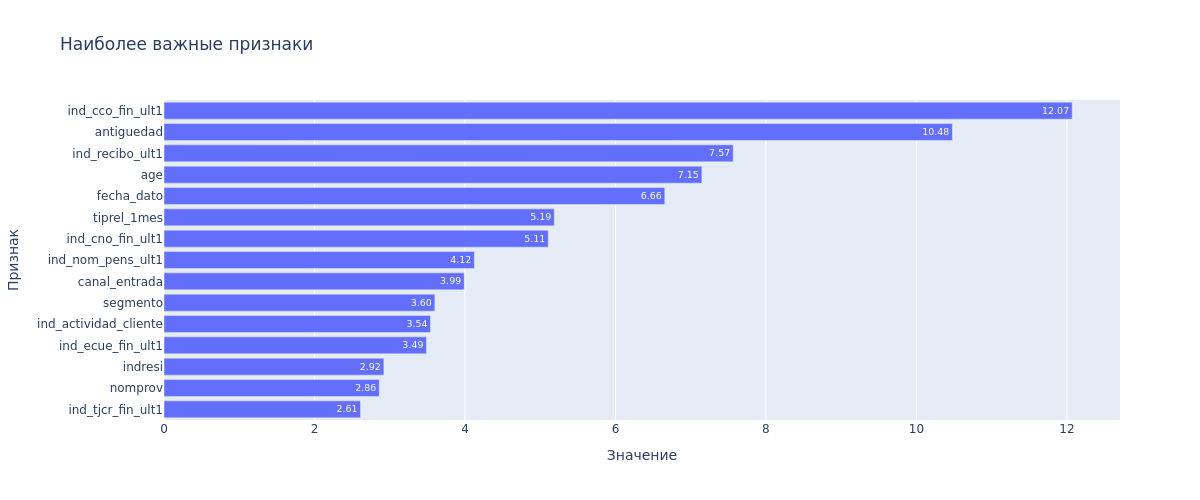

In [54]:
feat_importance = pd.DataFrame({
    "Признак": X_test.columns,
    "Важность": cbfs_model.get_feature_importance()}
).sort_values(by="Важность", ascending=False).set_index("Признак")
fig = feat_importance.head(15).plot(
    kind="barh", text_auto=True,
    title="Наиболее важные признаки",
    labels={"value": "Значение"})
fig.update_traces(texttemplate="%{x:.2f}")
fig.update_layout(
    height=500, width=1200, 
    showlegend=False,
    yaxis=dict(autorange="reversed"))
fig.show(renderer="png")

Модель определила наиболее важными признаками стаж, возраст, месяц взаимодействия и канал прихода. Также в топе продукты, которыми пользовались клиенты. Оценим наименее значимые признаки.

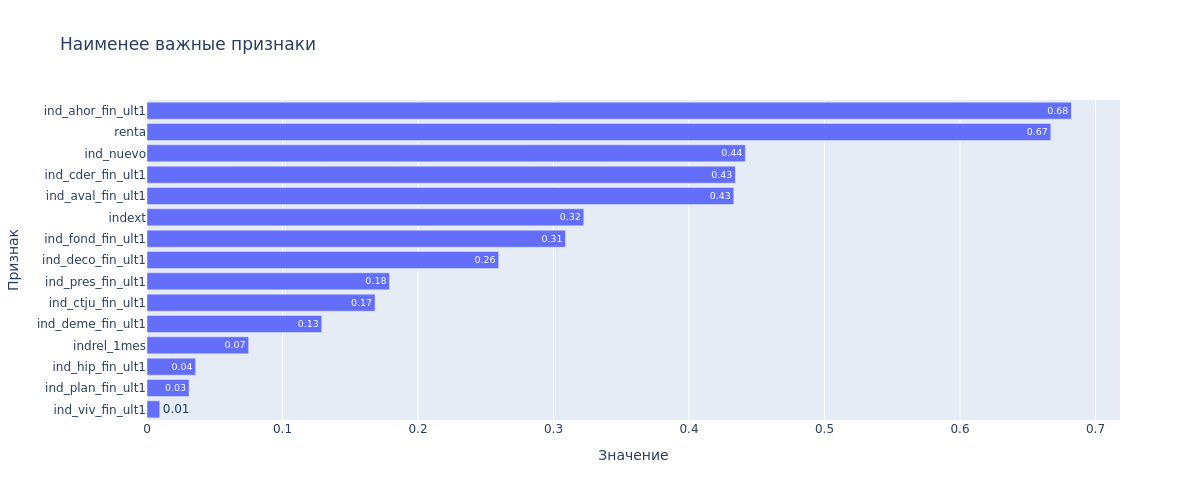

In [55]:
fig = feat_importance.tail(15).plot(
    kind="barh", text_auto=True,
    title="Наименее важные признаки",
    labels={"value": "Значение"})
fig.update_traces(texttemplate="%{x:.2f}")
fig.update_layout(
    height=500, width=1200, 
    showlegend=False,
    yaxis=dict(autorange="reversed"))
fig.show(renderer="png")

К наименее важным признакам модель отнесла довольно много продуктов, из остальных признаков самая низкая важность у активности клиента на начало месяца. Отбор признаков производить не будем, так как использованные клиентами продукты лучше не удалять - они в первую очередь являются признаком того, что в следующем месяце таких же продуктов не будет.

#### Логирование в MLflow

In [56]:
if MLFLOW:
    with mlflow.start_run(run_name="Multi-label stratified model", 
                        experiment_id=experiment_id) as run:
        mlflow.log_metrics(metrics)
        mlflow.catboost.log_model(
            cb_model=cbfs_model, artifact_path="model",
            registered_model_name=REGISTRY_MODEL_NAME,
            signature=infer_signature(
                X_test, probas),
            input_example=X_test.sample(
                15, random_state=RANDOM_STATE),
            await_registration_for=60,
            pip_requirements="requirements.txt")
    
    print("Run ID:", run.info.run_id)

Registered model 'bank_products_3PX' already exists. Creating a new version of this model...
2025/04/27 04:46:46 INFO mlflow.tracking._model_registry.client: Waiting up to 60 seconds for model version to finish creation. Model name: bank_products_3PX, version 3


Run ID: 037d64ffd4bb4d2dba67eae373aebe51


Created version '3' of model 'bank_products_3PX'.


### Сохранение данных и выбор модели для Веб-сервиса

Сохраним тестовую выборку в S3 бакет для использования в Веб-сервисе в качестве данных за последний месяц. Целевые признаки сохраним для использования скриптом тестирования.

In [57]:
# Сохранение тестовой выборки в S3
X_test.to_parquet(
    TEST_DUMP, engine="pyarrow",
    storage_options=STORAGE_OPTIONS)

# Сохранение таргета для скрипта тестирования
y_test.assign(ncodpers=df.loc[test_mask, "ncodpers"]) \
    .set_index("ncodpers").to_parquet(
        os.path.join("testing", "test_data.parquet"))

Переведем последнюю модель MLflow в стадию Production, так как подготовленный Веб-сервис по умолчанию забирает последнюю модель в этой стадии.

In [58]:
if MLFLOW:
    models = client.get_latest_versions(
        name=REGISTRY_MODEL_NAME, stages=["None", "Production"])
    last_model = max(models, key=lambda m: int(m.version))
    client.transition_model_version_stage(
        name=REGISTRY_MODEL_NAME, 
        version=last_model.version, 
        stage="Production",
        archive_existing_versions=True)

## Итоговые выводы

1. В рамках проекта проведен глубокий исследовательский анализ данных (EDA):
- удалены все записи с пропусками по большинству полей, остальные пропуски заполнены на основании последующих значений у клиента, либо заглушками типа `unknown`;
- в датасете было выявлено большое количество аномалий, которые были исправлены;
- пропуски по доходу были заполнены нулями, так как нет понимания насколько актуальны эти сведения для старых клиентов, в датасете имеются несовершеннолетние и могут быть безработные, иждивенцы, либо находящиеся на социальном обеспечении клиенты. Также возможно не для всех продуктов запрашивались сведения по доходам и точно не запрашивались для резидентов других стран;
- выбросы были исправлены только по возрасту клиентов, так как при анализе признака, в том числе по банковским продуктам, имелись подозрения на наличие выбросов. Для этого была подготовлена регрессионная модель Random Forest и значения с самыми большими остатками были исправлены на предсказания модели;
- подготовлен трансформер для всех преобразований датасета.

2. Проведены эксперименты по подготовке базовых моделей на этапе моделирования:
- подготовлен трансформер для выделения из датасета записей, имеющих сведения о продуктах в следующем месяце, а также целевые значения для таких записей;
- подготовлена и протестирована базовая модель с двухстадийным подходом - получение рекомендаций от ALS и последующее ранжирование с помощью CatBoost Classifier;
- подготовлена и протестирована базовая модель многометочной (multi-label) классификации - CatBoost Classifier с функцией потери MultiLogLoss;
- среди базовых определена лучшая - модель multi-label классификации, которая показывает существенное преимущество по сравнению с двухстадийным подходом и не требует дополнительной подготовки датасета;
- проведен эксперимент по сэмплированию данных - сохранение редких классов в признаках, сэмплирование привело к несущественному росту основной метрики MAP@3, однако по метрике Recall@3 дало даже небольшое снижение, дальнейшие эксперименты трубуют дополнительных ресурсов;
- результат EDA, а также все трансформеры и модели логированы в MLflow;
- произведена выгрузка тестового датасета, а последняя версия модели переведена в стадию Production для использования Веб-сервисом.

3. Подготовлен FastAPI Веб-сервис, который имеет следующую функциональность:
- загрузка модели из MLflow (по имени, flavor и стадии модели, любая модель с методом predict_proba) и датасета за последний месяц для получения предсказаний;
- предоставление списка клиентов по продукту, вероятность приобретения которых не ниже порога;
- предоставление ТОП-k рекомендаций по клиенту;
- рассчет метрик по предоставленным сведениям об использовании клиентами продуктов в новом месяце;

4. Дополнительно подготовлены: 
- сервис мониторинга на базе Prometheus и Grafana - собирает метрики по Веб-сервису и предсказаниям модели (метрики модели и количество успешных предсказаний);
- скрипт для тестирования Веб-сервиса.

Рекомендации по дальнейшим экспериментам:
- увеличить количество негативных записей с мажорными классами признаков после сэмплирования (требуется дополнительный объем оперативной памяти для обучения модели);
- провести подбор гиперпараметров для модели (требуется дополнительные временные и вычислительные ресурсы).